# Notebook 07 — CNN with Transfer Learning (EfficientNetB3)

## Project Context

This notebook is part of the **Rosa damascena Disease Detection** project. The
goal is to classify images of oil-bearing rose leaves into 7 categories: 6
disease/condition classes (black spot, downy mildew, powdery mildew, rose
mosaic, rose rust, insect damage) plus the healthy_leaf class. This work
extends the ladder of from-scratch models built in notebooks 05 (Logistic
Regression, Linear SVM) and 06 (fully connected neural network with NumPy)
by introducing a Convolutional Neural Network. Unlike the previous notebooks,
this one **does not** implement everything from scratch — it uses Keras
(TensorFlow) and a pre-trained backbone (EfficientNetB3) on top of which a
new classification head is trained. The focus of this notebook shifts from
deriving algorithms to recognising when and how to use existing
implementations effectively.

## Goals of This Notebook

1. Train a Convolutional Neural Network that beats the NN + Adam baseline of
   `71.86%` test accuracy / `0.6737` macro F1 from notebook 06 on the same
   held-out test set.
2. Specifically improve two classes that hit a representational ceiling
   in notebook 06:
   - **`rose_mosaic` recall** — notebook 06 best was Adam at `0.28`;
     target `0.50+`. The combination of full 224x224 resolution and colour
     should restore the texture and hue cues that distinguish rose mosaic
     from powdery mildew.
   - **`black_spot` recall** — notebook 06 plateaued at `0.64-0.65` for
     both optimizers; target `0.75+`. Local black-spot markers should
     reappear at full resolution.
3. Demonstrate that the improvement over notebook 06 comes from **spatial
   structure + colour + higher resolution**, not from more parameters or a
   deeper architecture per se. The convolutional architecture, parameter
   sharing argument and receptive field analysis below make this case
   quantitatively.

## Architecture

A pre-trained **EfficientNetB3** backbone (12M parameters, pre-trained on
ImageNet) with the classification head replaced by a new task-specific head:

    Input (224 x 224 x 3 RGB)
        |
        v
    EfficientNetB3 (pre-trained, ImageNet weights)
        |
        v
    GlobalAveragePooling2D     <- reduces spatial dims to a single vector
        |
        v
    Dropout (0.3)              <- regularisation against overfitting
        |
        v
    Dense (256, ReLU)          <- new task-specific representation
        |
        v
    Dropout (0.3)
        |
        v
    Dense (7, Softmax)         <- one logit per disease class

- **Why EfficientNetB3:** modern (2019), efficient parameter use, strong
  ImageNet baseline. EfficientNetB0 is faster but with a lower ceiling.
  ResNet50 is older with more parameters for the same accuracy.
- **Why pre-trained on ImageNet:** low-level features (edges, textures, colour
  gradients) learned from 1.2 million ImageNet images transfer well to
  natural-image domains, including rose leaves.
- **Why a custom head:** ImageNet has 1,000 classes; we have 7. The original
  output layer is replaced by a task-specific one. Two Dense layers with
  Dropout between them give the head enough capacity to map ImageNet
  features into a 7-class decision space without overfitting.


## Transfer Learning Strategy — Staged Training

This is the central methodological choice of the notebook. Instead of
training every weight in the network at once, training proceeds in two
distinct stages.

### Stage 1 — Frozen base + head training

- The EfficientNetB3 backbone is **frozen** (`trainable = False`); no
  gradients flow into it, no weights are updated.
- Only the new head (about 100,000 parameters) is trained.
- Optimizer: Adam at `lr = 1e-3`.
- Up to 8 epochs with `EarlyStopping(patience=3, monitor="val_loss")`.
- Catastrophic forgetting **cannot** happen at this stage because the base
  weights are physically untouched. The pre-trained ImageNet features remain
  exactly as ImageNet learned them.

### Stage 2 — Selective unfreezing + fine-tuning

- The **top 20** layers of EfficientNetB3 are unfrozen (`trainable = True`).
  Deeper layers remain frozen because they encode universal low-level
  features (edges, gradients) that we do not want to change.
- Optimizer: Adam at `lr = 5e-6` (200x lower than Stage 1).
- Up to 25 epochs with `EarlyStopping(patience=2, restore_best_weights=True)`.
- `ReduceLROnPlateau(factor=0.5, patience=2)` companion to drop the learning
  rate further if training plateaus.
- This is the stage where **catastrophic forgetting could occur** if the
  learning rate were too high. The very low `lr = 5e-6` ensures that
  parameter updates are small enough to refine the ImageNet features for
  the rose-leaf domain rather than overwriting them.

## Data Augmentation

Modest, applied as part of the model graph (i.e. only during training,
automatically disabled at inference):

- `RandomFlip("horizontal")` — leaves can be photographed from either side.
- `RandomRotation(0.1)` — up to about 36 degrees of tilt.
- `RandomZoom(0.1)` — up to 10% zoom in or out.

Vertical flips and large rotations are intentionally excluded: leaves have
a natural upright orientation in real-world field photographs, so adding
upside-down examples would teach the network unrealistic invariances.

## Class Imbalance Handling

**None in the first version.** Following the same "measure first" approach
that worked in notebook 06: the network is trained without any explicit
imbalance correction (no `class_weight`, no oversampling), and the per-class
results are reviewed before deciding whether an intervention is warranted.
The threshold for action: if `rose_mosaic` recall on the test set is below
`0.40` after Stage 2, a second version with `class_weight="balanced"` will
be trained for comparison.

## Expected Outcome

The current ladder of from-scratch models on the held-out 2,580-image test
set, evaluated identically:

| Model                | Test Accuracy | Macro F1 |
|----------------------|---------------|----------|
| Random chance        | 0.1429        | -        |
| Linear SVM (NB 05)   | 0.5110        | 0.4400   |
| Logistic Regression (NB 05) | 0.5560 | 0.4700   |
| NN + SGD + momentum (NB 06) | 0.6845 | 0.6118   |
| **NN + Adam (NB 06)** | **0.7186**   | **0.6737** |

The CNN in this notebook is expected to land **clearly above** the NN + Adam
result. A realistic target range based on similar published results on
plant-disease image classification:

- Test accuracy: `0.85 - 0.92`
- Macro F1: `0.80 - 0.88`
- `rose_mosaic` recall: `0.50 - 0.70`

If the CNN delivers numbers below this range, the most likely causes are
under-fitting (training too short), wrong augmentation, or class imbalance
issues — all of which can be diagnosed from the per-class confusion matrix
in the evaluation section.

## Math Highlighted in This Notebook

To make the contribution of convolution and transfer learning explicit, the
following five concepts are derived or visualised in dedicated markdown
cells before their corresponding code:

1. **Convolution operation** — derivation of the formula, kernel sliding,
   stride, padding, and what the operation actually computes geometrically.
2. **Parameter sharing** — quantitative demonstration of why a CNN of
   comparable capacity has roughly 10x fewer parameters than the fully
   connected `W_1` of notebook 06. Includes a side-by-side parameter count.
3. **Receptive field analysis** — how the receptive field of a single output
   neuron grows with depth, with a worked example for EfficientNetB3.
4. **Transfer learning rationale** — why ImageNet features generalise from
   1.2 million natural images to a domain (rose leaves) the model has never
   seen, framed as a feature-space-overlap argument.
5. **Fine-tuning learning rate intuition** — why Stage 2 uses
   `lr = 5e-6` for the base (200x lower than Stage 1's head training rate),
   framed as a gradient magnitude argument and an explicit explanation of
   how catastrophic forgetting is prevented.

## Connection to Other Notebooks

- **Builds on:** notebook 05 (LR/SVM baselines, same test split, same class
  conventions), notebook 06 (NN + Adam baseline, all four predecessors share
  the same `BASELINE_RESULTS` dict for the final comparison plot).
- **Saves for:** notebook 09 (MLflow) — the trained CNN model and its test
  predictions are saved to `MODELS_DIR` so that notebook 09 can construct
  the full 5-model ladder without re-running inference.
- **Independent of:** notebook 08 (tabular weather-risk model). The two are
  intended to be combined in the final fungicide-recommendation logic, but
  neither depends on the other internally.

## Setup: Environment, Dependencies and GPU Verification

This section prepares the working environment for the notebook. Compared to
notebook 06, the setup is more involved because:

1. The model uses **TensorFlow / Keras** (CNN architecture with pre-trained
   weights), not only NumPy. Several new imports are needed for layers,
   callbacks, augmentation primitives and the EfficientNetB3 backbone.
2. **A GPU runtime is required.** EfficientNetB3 fine-tuning on 25,738
   images at 224x224 is computationally prohibitive on a CPU runtime — a
   single training epoch could take 30+ minutes on CPU vs roughly 1 minute
   on a T4 GPU. The cell verifies that a GPU is available before any
   training begins and prints its name; if no GPU is found, switch the
   runtime via `Runtime -> Change runtime type -> Hardware accelerator: GPU`
   and re-run.
3. **Multiple random seeds** must be set for reproducibility across the
   different sources of randomness involved in TensorFlow training:
   - `tf.random.set_seed` for TensorFlow operations.
   - `np.random.seed` for NumPy (used by some augmentation paths and by
     custom code below).
   - `random.seed` for Python's standard library (used internally by some
     parts of the `tf.data` pipeline).

### What Else This Cell Does

- **Mounts Google Drive** for access to `data/processed/images/` and
  `models/` (same paths as notebook 06).
- **Declares project-wide constants** — class names, class indices, image
  size, models directory. These mirror notebook 06 exactly.
- **Sets up `BASELINE_RESULTS`** extended with the two NN results from
  notebook 06, so the final 5-model comparison plot can be generated
  self-contained without re-loading any prior notebook.
- **Declares CNN hyperparameters** — image size 224x224, batch size 32,
  base model name, learning rates and epoch limits for both stages, number
  of top base-model layers to unfreeze in Stage 2.
- **Verifies dataset structure** — fails fast if Drive is not mounted or
  any class subdirectory is missing, before any expensive computation
  begins.

### A Note on Image Size

Notebook 06 worked with `32x32` grayscale images flattened to `1,024`
features. Notebook 07 works with **`224x224` RGB** images — `224 * 224 * 3
= 150,528` input dimensions per image, **roughly 147x more than notebook 06**.
This is the single most important change. The CNN is given back the spatial
structure, the colour information and the high-frequency texture cues that
notebook 06's flattened-pixel representation could not access. Every model
comparison later in this notebook is therefore between models that were
never given the same view of the same images — they had fundamentally
different representations of the same underlying photographs.


In [1]:
# ============================================================
# Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# Imports
# ============================================================
import os
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# scikit-learn for evaluation metrics only (consistent with notebooks 05 and 06)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, applications

# ============================================================
# GPU verification — fail fast if not running on a GPU runtime
# ============================================================
gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError(
        "No GPU available. Notebook 07 requires a GPU runtime.\n"
        "Switch via: Runtime -> Change runtime type -> Hardware accelerator: GPU"
    )

gpu_name = tf.test.gpu_device_name()
print(f"GPU available : {gpu_name}")
print(f"GPU details   : {gpus[0]}")

# Enable memory growth so TF does not pre-allocate the full GPU memory
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# ============================================================
# Reproducibility — set every relevant random source
# ============================================================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ============================================================
# Paths (Google Drive) — identical to notebook 06
# ============================================================
DRIVE_BASE = Path("/content/drive/MyDrive/Machine_Learning_Project")
DATA_DIR   = DRIVE_BASE / "data" / "processed" / "images"
TRAIN_DIR  = DATA_DIR / "train"
VAL_DIR    = DATA_DIR / "val"
TEST_DIR   = DATA_DIR / "test"
MODELS_DIR = DRIVE_BASE / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Classes (alphabetical order, same as notebooks 05 and 06)
# ============================================================
CLASS_NAMES = [
    "black_spot",
    "downy_mildew",
    "healthy_leaf",
    "insect_damage",
    "powdery_mildew",
    "rose_mosaic",
    "rose_rust",
]
N_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# ============================================================
# Baseline results from prior notebooks (for the final 5-model ladder plot)
# ============================================================
BASELINE_RESULTS = {
    "Logistic Regression": {"test_accuracy": 0.556,  "macro_f1": 0.47},
    "Linear SVM":          {"test_accuracy": 0.511,  "macro_f1": 0.44},
    "NN + SGD + momentum": {"test_accuracy": 0.6845, "macro_f1": 0.6118},
    "NN + Adam":           {"test_accuracy": 0.7186, "macro_f1": 0.6737},
}

# ============================================================
# CNN hyperparameters and architecture constants
# ============================================================
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
BASE_MODEL_NAME = "EfficientNetB3"

# Stage 1: train head only, base frozen
STAGE1_LR = 1e-3
STAGE1_MAX_EPOCHS = 8
STAGE1_PATIENCE = 3

# Stage 2: unfreeze top of base, fine-tune everything that is unfrozen
STAGE2_LR = 5e-6
STAGE2_MAX_EPOCHS = 25
STAGE2_PATIENCE = 2
STAGE2_UNFREEZE_LAYERS = 20   # number of top base-model layers to unfreeze

# ============================================================
# Plotting defaults
# ============================================================
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

# ============================================================
# Verify dataset structure (fail fast if Drive content is missing)
# ============================================================
for split_name, split_dir in [("train", TRAIN_DIR),
                                ("val",   VAL_DIR),
                                ("test",  TEST_DIR)]:
    assert split_dir.exists(), f"Missing {split_name} directory: {split_dir}"
    for cls in CLASS_NAMES:
        assert (split_dir / cls).exists(), \
            f"Missing class directory: {split_dir / cls}"

# ============================================================
# Confirmation output
# ============================================================
print()
print("Environment ready")
print(f"  TensorFlow version : {tf.__version__}")
print(f"  Keras version      : {keras.__version__}")
print(f"  NumPy version      : {np.__version__}")
print(f"  Data root          : {DATA_DIR}")
print(f"  Models root        : {MODELS_DIR}")
print(f"  Image size         : {IMAGE_SIZE} (RGB, 3 channels)")
print(f"  Batch size         : {BATCH_SIZE}")
print(f"  Classes ({N_CLASSES})        : {CLASS_NAMES}")
print(f"  Random seed        : {RANDOM_SEED}")
print(f"  Base model         : {BASE_MODEL_NAME}")
print(f"  Stage 1 hparams    : lr={STAGE1_LR}, max_epochs={STAGE1_MAX_EPOCHS}, "
      f"patience={STAGE1_PATIENCE}")
print(f"  Stage 2 hparams    : lr={STAGE2_LR}, max_epochs={STAGE2_MAX_EPOCHS}, "
      f"patience={STAGE2_PATIENCE}, unfreeze top {STAGE2_UNFREEZE_LAYERS} layers")
print(f"  Baseline models    : {list(BASELINE_RESULTS.keys())}")

Mounted at /content/drive
GPU available : /device:GPU:0
GPU details   : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Environment ready
  TensorFlow version : 2.20.0
  Keras version      : 3.13.2
  NumPy version      : 2.0.2
  Data root          : /content/drive/MyDrive/Machine_Learning_Project/data/processed/images
  Models root        : /content/drive/MyDrive/Machine_Learning_Project/models
  Image size         : (224, 224) (RGB, 3 channels)
  Batch size         : 32
  Classes (7)        : ['black_spot', 'downy_mildew', 'healthy_leaf', 'insect_damage', 'powdery_mildew', 'rose_mosaic', 'rose_rust']
  Random seed        : 42
  Base model         : EfficientNetB3
  Stage 1 hparams    : lr=0.001, max_epochs=8, patience=3
  Stage 2 hparams    : lr=5e-06, max_epochs=25, patience=2, unfreeze top 20 layers
  Baseline models    : ['Logistic Regression', 'Linear SVM', 'NN + SGD + momentum', 'NN + Adam']


## Theoretical Foundation

Before any code, the mathematical building blocks that distinguish a CNN
from the fully connected network of notebook 06 are defined and justified.
The next cells (model construction, training, evaluation) reference the
formulas and arguments introduced here.

### 1. The Convolution Operation

A 2D convolution slides a small filter (kernel) of shape `K_h x K_w x C_in`
across the input feature map, computing a dot product at every spatial
position. For an input `X` of shape `H x W x C_in` and `C_out` filters of
shape `K_h x K_w x C_in`, the output at position `(i, j)` of the `c`-th
output channel is:

$$
Y[i, j, c] \;=\; \sum_{u=0}^{K_h - 1} \sum_{v=0}^{K_w - 1} \sum_{k=0}^{C_{in} - 1}
W_c[u, v, k] \cdot X[i + u,\ j + v,\ k] \;+\; b_c.
$$

Two parameters control the geometry of the sliding:

- **Stride `s`** — how many input positions the kernel skips between
  successive output positions. Stride `1` keeps every input position;
  stride `2` halves the spatial dimensions.
- **Padding** — extra zero rows and columns added around the input so the
  output retains the input resolution. EfficientNet uses "same" padding so
  output spatial dimensions equal `ceil(input / stride)`.

The crucial property: **the same filter weights `W_c` are used at every
spatial position**. The kernel does not learn a separate weight for each
position; it learns one weight pattern that is applied everywhere. This is
the source of the parameter-sharing advantage discussed next.

### 2. Parameter Sharing — Why a CNN Is Cheap

Compare the parameter count of detecting a "dark spot" in two ways.

**Fully connected (notebook 06 style).** To map a `224 x 224 x 3 = 150,528`
input to even a modest `256`-unit hidden layer, the weight matrix has

$$
W_1 \in \mathbb{R}^{150{,}528 \times 256} \;\Rightarrow\; \approx 38.5\text{ million parameters}.
$$

Each input pixel has its own dedicated weight to each hidden neuron. A dark
spot at the top-left of the image and a dark spot at the bottom-right use
**different** weights — the network has to learn the same pattern twice,
once per location.

**Convolutional.** A `3 x 3 x 3` filter has `3 * 3 * 3 = 27` weights plus
`1` bias = `28` parameters total. Even with `32` such filters in the first
convolutional block:

$$
3 \cdot 3 \cdot 3 \cdot 32 \;+\; 32 \;=\; 896 \text{ parameters}.
$$

This is **`43,000x` fewer parameters than the dense `W_1` above** while
still being able to detect the same "dark spot" pattern — but now anywhere
in the image, because the filter slides over every position. The
quantitative gap is what makes CNNs practical for image inputs at full
resolution; the fully connected approach is fundamentally constrained by
the cost of the input layer alone.

### 3. Receptive Field — Spatial Reach with Depth

The **receptive field** of an output neuron is the set of input pixels that
can possibly influence its value. For a single `3 x 3` convolution the
receptive field is obviously `3 x 3`. For a stack of convolutions, the
receptive field grows.

For a network with `L` layers where layer `l` has kernel size `k_l`, stride
`s_l`, and the cumulative stride before it is `S_{l-1} = \prod_{m < l} s_m`,
the receptive field after layer `L` is:

$$
R_L \;=\; 1 \;+\; \sum_{l=1}^{L} (k_l - 1) \cdot S_{l-1}.
$$

A worked example for a simplified 4-layer block of `3 x 3` convolutions
with strides `(1, 2, 1, 2)`:

- After layer 1: `R = 1 + (3-1)*1 = 3` input pixels.
- After layer 2 (stride 2): `R = 3 + (3-1)*1 = 5` input pixels.
- After layer 3 (stride 1, but `S = 2`): `R = 5 + (3-1)*2 = 9`.
- After layer 4 (stride 2, `S = 2`): `R = 9 + (3-1)*2 = 13`.

A deeper EfficientNetB3 has a much larger receptive field by the final
convolutional block — large enough that each output neuron sees the whole
image. This is why convolutional networks can capture both fine local
detail (early layers, small receptive field) and global shape information
(late layers, full-image receptive field) without an explicit fully
connected step until the very end.

### 4. Transfer Learning — Why ImageNet Features Generalise

EfficientNetB3 is loaded with **pre-trained weights** from ImageNet (1.28
million natural images, 1,000 classes — cats, dogs, cars, plants, and
hundreds more). The pre-trained network has already learned features that
transfer well to almost any natural-image domain, because:

- **Low-level features are universal.** The first convolutional layers
  learn edge detectors, colour gradients, simple textures, and small
  curvature patterns. These features are needed to represent every natural
  image, including rose leaves. There is no reason to re-learn them from
  rose data alone — the ImageNet weights already encode them well.
- **Mid-level features are reusable.** Later layers compose the low-level
  features into shapes, patterns and textures (stripes, dots, leaves,
  fur). Many of these patterns appear in both ImageNet and on rose leaves
  — leaf veins, sunlit patches, spotted patterns. The pre-trained weights
  are a strong starting point.
- **High-level features are task-specific.** The deepest layers and the
  classification head encode "this is a tabby cat" or "this is a Persian
  rug". These need to be replaced for the rose-disease task; this is
  exactly what the custom head does (see Architecture section above).

The combination — keep low and mid-level features, replace and refine the
top — is the essence of transfer learning. The expected sample-efficiency
gain over training from scratch is enormous: ImageNet weights are
equivalent to having seen roughly a million extra images before the rose
dataset is even touched.

### 5. Fine-Tuning Learning Rate Intuition

Stage 1 trains the **head** at `lr = 1e-3`. Stage 2 fine-tunes the
**top 20 layers of the base** at `lr = 5e-6` — `200x` lower. Why such a
big difference?

The head starts from **random initialisation** (He init, like notebook 06).
Its weights mean nothing yet; large updates are exactly what is needed to
move them from random to useful. `lr = 1e-3` is a standard rate for
training a new layer from scratch and the head converges in a handful of
epochs.

The base, by contrast, starts from **carefully optimised ImageNet
weights**. These weights took weeks of training on millions of images to
find. They are close to a useful local minimum in the loss landscape. A
large update at this stage would:

1. Move the weights far away from the good ImageNet point in one step.
2. With high probability, land in a region that is **worse** for both
   ImageNet features and the rose task — the gradient is computed from a
   small batch and points toward the rose-specific direction without
   regard to preserving general features.
3. After enough such updates, the original ImageNet features would be
   destroyed entirely — this is the *catastrophic forgetting* phenomenon.

A `200x` lower learning rate ensures every update is a **small nudge** —
just enough to refine the ImageNet features for the rose-leaf domain
rather than overwrite them. The `EarlyStopping` and `ReduceLROnPlateau`
callbacks add a second layer of protection: training stops as soon as
the validation loss stops improving, so even if some weights start
drifting in a counter-productive direction, the damage is bounded.

### Summary — From Theory to Implementation

The next cells implement, in order:

1. Construction of the EfficientNetB3-based model with the custom head
   (Stage 1 architecture — base frozen).
2. A quantitative parameter-count visualisation comparing this CNN with
   the fully connected network of notebook 06 — making the
   parameter-sharing argument visible in numbers.
3. A receptive-field visualisation showing how the spatial reach grows
   with depth on a real sample image.
4. The `tf.data` input pipeline with augmentation.
5. Stage 1 training (frozen base + new head, `lr = 1e-3`).
6. Stage 2 training (unfreeze top 20 layers, `lr = 5e-6`).
7. Test-set evaluation and the final 5-model comparison ladder.

## Building the Model

This cell constructs the CNN for Stage 1 — pre-trained EfficientNetB3 with
its base **frozen** and a new task-specific head on top. The model is built
in the Keras functional API so that augmentation, backbone and head can be
composed cleanly as a single graph.

### Architectural Decisions Encoded in This Cell

1. **Augmentation lives inside the model.** `RandomFlip`, `RandomRotation`
   and `RandomZoom` are added as the very first layers after the input.
   Doing it this way means augmentation runs on GPU, is automatically
   disabled at inference (these layers are no-ops in `predict()` and
   `evaluate()`), and is captured in the saved `.keras` file so reproducing
   results later is trivial.

2. **EfficientNetB3 is loaded with `include_top=False`.** The original
   ImageNet classification head (1,000 classes) is discarded; only the
   convolutional backbone is kept. The weights are loaded from the
   ImageNet checkpoint (`weights="imagenet"`).

3. **The backbone is frozen with `base_model.trainable = False`.** No
   gradients flow into any layer of EfficientNetB3 during Stage 1. The
   ImageNet weights are physically untouched.

4. **The backbone is called with `training=False`.** This is the most
   important and most easily missed detail in Keras transfer learning.
   EfficientNet contains many `BatchNormalization` layers. By default, BN
   layers update their running mean and variance from each mini-batch
   during training, even when the layer's weights are frozen. If we let
   that happen, the BN statistics drift away from the ImageNet statistics
   the rest of the network was calibrated against, and the pre-trained
   features get silently corrupted within a few hundred steps. Passing
   `training=False` keeps every BN layer in inference mode permanently,
   so the running statistics from ImageNet stay locked in.

5. **The head is small and regularised.** A `GlobalAveragePooling2D`
   collapses the final feature map (a few thousand channels at low spatial
   resolution) into a single vector. Two `Dropout(0.3)` layers around a
   `Dense(256, ReLU)` give the head enough capacity to learn a useful
   rose-leaf representation while limiting overfitting on the relatively
   small training set.

6. **Output is `Dense(7, Softmax)`.** Same shape as notebook 06's output
   layer. Loss is sparse categorical cross-entropy because labels are
   integer class indices (the standard output of
   `image_dataset_from_directory`).

### What `model.summary()` Will Show

A line-by-line dump of every layer with its output shape and parameter
count, followed by three summary numbers:

- **Total params** — roughly `12.0M` for EfficientNetB3 plus about
  `0.1M` for the head, total `~12.1M`.
- **Trainable params** — only the head (`~0.1M`) plus any non-frozen
  augmentation/BN parameters. **In Stage 1 this number must be very small
  compared to total params** — that is the visual confirmation the
  freezing worked.
- **Non-trainable params** — the entire EfficientNetB3 backbone (`~12M`).

If trainable params are not a small fraction of total, the freezing is
broken and Stage 1 would silently destroy ImageNet features.


In [ ]:
def build_model(num_classes=N_CLASSES, image_size=IMAGE_SIZE):
    """Construct the Stage 1 model: EfficientNetB3 base (frozen) + custom head.

    The function returns both the full Keras model and a reference to the
    base model so that Stage 2 can selectively unfreeze layers later.
    """
    inputs = keras.Input(shape=(*image_size, 3), name="input_image")

    # ----- Augmentation block (training-only, no-op at inference) -----
    x = layers.RandomFlip("horizontal", name="aug_flip")(inputs)
    x = layers.RandomRotation(0.1, name="aug_rotation")(x)
    x = layers.RandomZoom(0.1, name="aug_zoom")(x)

    # ----- Pre-trained EfficientNetB3 backbone -----
    base_model = applications.EfficientNetB3(
        include_top=False,            # drop the original 1000-class head
        weights="imagenet",           # load pre-trained ImageNet weights
        input_shape=(*image_size, 3),
        pooling=None,                 # we add GlobalAveragePooling ourselves
    )
    base_model.trainable = False      # FREEZE for Stage 1

    # training=False keeps BatchNorm in inference mode permanently,
    # preserving the ImageNet running statistics. See markdown intro.
    x = base_model(x, training=False)

    # ----- Custom classification head -----
    x = layers.GlobalAveragePooling2D(name="head_pool")(x)
    x = layers.Dropout(0.3, name="head_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="head_dense")(x)
    x = layers.Dropout(0.3, name="head_dropout_2")(x)
    outputs = layers.Dense(num_classes, activation="softmax",
                           name="head_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="efficientnetb3_rose_classifier")
    return model, base_model


# Build the model (Stage 1 configuration)
model, base_model = build_model()

# Compile for Stage 1 training (frozen base + head training)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# ============================================================
# Verify the freezing
# ============================================================
total_params       = model.count_params()
trainable_params   = sum(np.prod(v.shape) for v in model.trainable_weights)
nontrainable_params = total_params - trainable_params

print("Model summary:")
model.summary(show_trainable=True)

print()
print("Parameter sanity check (Stage 1):")
print(f"  Total parameters         : {total_params:>12,}")
print(f"  Trainable parameters     : {trainable_params:>12,}  "
      f"({100 * trainable_params / total_params:.2f}% of total)")
print(f"  Non-trainable parameters : {nontrainable_params:>12,}  "
      f"({100 * nontrainable_params / total_params:.2f}% of total)")
print()
print(f"  Base model name          : {base_model.name}")
print(f"  Base model layer count   : {len(base_model.layers)} layers")
print(f"  Base model trainable     : {base_model.trainable}")

Model summary:


Model: "efficientnetb3_rose_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_image (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ aug_flip (RandomFlip)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ aug_rotation                │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomRotation)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ aug_zoom (RandomZoom)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb3 (Functional) │ (None, 7, 7, 1536)    │ 10,783,535 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_pool                   │ (None, 1536)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_dropout_1 (Dropout)    │ (None, 1536)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_dense (Dense)          │ (None, 256)           │    393,472 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_dropout_2 (Dropout)    │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_output (Dense)         │ (None, 7)             │      1,799 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 11,178,806 (42.64 MB)

 Trainable params: 395,271 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)


Parameter sanity check (Stage 1):
  Total parameters         :   11,178,806
  Trainable parameters     :      395,271  (3.54% of total)
  Non-trainable parameters :   10,783,535  (96.46% of total)

  Base model name          : efficientnetb3
  Base model layer count   : 385 layers
  Base model trainable     : False


### Observations

The model was constructed correctly and the freezing for Stage 1 is verified.

- **Total parameters: 11,178,806** — about 11.2 million, of which the
  EfficientNetB3 backbone is ~10.8M and the new head is ~0.4M. This is
  moderately sized for a modern CNN — heavier than EfficientNetB0 (5.3M)
  and MobileNetV2 (3.5M), lighter than ResNet50 (25M).
- **Trainable parameters: 395,271 (3.54%)** — only the new head and a few
  augmentation-related buffers. In Stage 1 every gradient update affects
  only these 395K weights; the 10.8M base weights are untouched.
- **Base model: 385 layers, `trainable=False`.** Confirms the freezing
  works at the layer-collection level, not just by accident. When the model
  is `fit()`-ted, TensorFlow will not propagate gradients into any of these
  385 layers.

### Comparison Across Notebooks

| Quantity                          | Notebook 06 (FC) | Notebook 07 (CNN Stage 1) |
|-----------------------------------|------------------|---------------------------|
| Total parameters                  | 304,007          | 11,178,806                |
| Trainable parameters              | 304,007          | **395,271**               |
| Input shape                       | 1,024 (32x32 gray) | 150,528 (224x224 RGB)    |
| Depth                             | 4 weight layers  | 385 layers                |

The most striking number: **the Stage 1 trainable head (395,271 parameters)
is almost the same size as the entire fully connected network in notebook
06 (304,007 parameters)**. Stage 1 training is therefore expected to be
comparable in computational cost to the full notebook 06 training — about
~1 minute per epoch on the T4 GPU, not the 30-60 minutes a full
fine-tuning run might take.

### Why This Matters for Stage 1

The setup means Stage 1 is fast, safe, and conceptually clean:

- **Fast** — only ~400K parameters receive updates each batch.
- **Safe** — there is no possibility of damaging the 10.8M ImageNet
  features. Catastrophic forgetting cannot occur because the relevant
  weights are not connected to the loss gradient.
- **Conceptually clean** — Stage 1 answers the question "given the
  pre-trained features, can a small head map them to our 7 classes
  effectively?". If Stage 1 already gets close to the target accuracy,
  Stage 2 is mostly a refinement; if Stage 1 plateaus low, Stage 2 has
  more work to do.

### Note on the Parameter-Sharing Argument

The next cell visualises the parameter-count comparison more dramatically:
it includes a *hypothetical* "FC notebook 06 at full resolution" baseline
(`38.6M` parameters), which is what a dense network would need to accept
the same `224x224 RGB` input EfficientNetB3 accepts here. The fact that
EfficientNetB3 contains the entire convolutional pipeline for less than a
third of that parameter cost — and that we only need to train roughly 1%
of that cost — is the visualised proof of the parameter-sharing argument
from the Theoretical Foundation.

## Visualisation: Parameter Count Comparison

This visualisation makes the **parameter sharing argument from the
Theoretical Foundation concrete and quantitative**. Four architectural
variants are plotted side by side on the same parameter-count axis.

### The Four Bars

1. **FC (NB 06) — 32x32 grayscale, actual.** The fully connected network
   trained in notebook 06. Input is 1,024 features (the only resolution
   the FC architecture could afford); total parameters 304,007.

2. **FC equivalent — 224x224 RGB, hypothetical.** What it would cost to
   feed the same input the CNN gets (224 x 224 x 3 = 150,528 features)
   into the same architecture as notebook 06 (256 -> 128 -> 64 -> 7
   hidden layers). The first layer alone explodes from 262,400 parameters
   to over 38.5 million; the total is roughly 38.6M. This is the
   hypothetical "what if we just scaled FC up" baseline — included so the
   parameter-sharing argument is visible rather than just claimed.

3. **CNN B3 total — actual.** The full EfficientNetB3 backbone plus our
   new head: 11,178,806 parameters. **Less than a third of the FC
   equivalent**, despite accepting the same 224x224 RGB input, going
   385 layers deep, and incorporating the full ImageNet feature hierarchy.

4. **CNN B3 trainable in Stage 1 — actual.** Only the new head and a
   few augmentation buffers: 395,271 parameters. **Smaller than the
   entire FC notebook 06 model** (304,007 was the *total* in NB 06),
   even though this CNN is far more powerful.

### What the Comparison Shows

- The naive scaling of FC to full-resolution colour images is
  infeasible: 38.6 million parameters in the input layer alone, with
  no parameter sharing across spatial positions.
- A modern CNN gets the *same* full-resolution colour input for **3.5x
  fewer total parameters**.
- With transfer learning, only **3.5% of those parameters need to be
  trained** in Stage 1 — meaning Stage 1 training is computationally
  similar in cost to training the entire notebook 06 network from
  scratch.

The visualisation does **not** claim the CNN is automatically better
because it has fewer or more parameters than FC. The claim is that for
the same input modality, the CNN's parameter-sharing structure makes
high-resolution colour inputs computationally tractable — something the
FC architecture fundamentally can`t do.

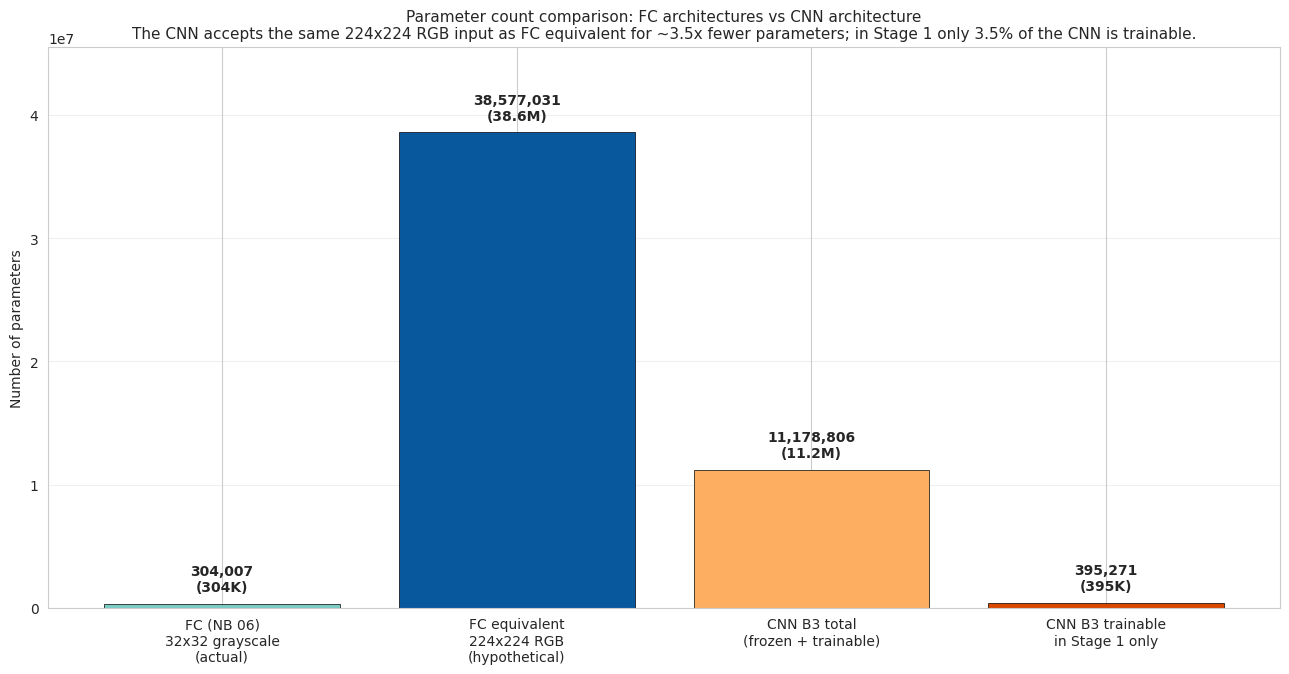


Parameter count detailed breakdown:
  Architecture                                    Parameters
  ------------------------------------------------------------
  FC NB 06 (32x32 grayscale, actual)                 304,007
  FC equivalent (224x224 RGB, hypothetical)       38,577,031
  CNN B3 total (frozen + trainable)               11,178,806
  CNN B3 trainable (Stage 1 only)                    395,271

Key ratios:
  Input dimensions ratio (224x224x3 / 32x32x1)        : 147.0x  (CNN sees ~147x more data)
  FC equivalent parameters / CNN B3 total              : 3.45x
  CNN B3 trainable / total                             : 3.54%
  CNN B3 trainable / FC NB 06 total parameters         : 1.30x  (Stage 1 trainable is ~30% larger than entire NB 06 network)


In [ ]:
# ============================================================
# Compute the hypothetical FC parameter count at 224x224 RGB
# (same architecture as notebook 06: 150,528 -> 256 -> 128 -> 64 -> 7)
# ============================================================
fc_input_full_res = 224 * 224 * 3                       # 150,528
fc_hypothetical_w1 = fc_input_full_res * 256 + 256       # ~38.5M
fc_hypothetical_w2 = 256 * 128 + 128                     # 32,896
fc_hypothetical_w3 = 128 * 64 + 64                       # 8,256
fc_hypothetical_w4 = 64 * 7 + 7                          # 455
fc_hypothetical_total = (fc_hypothetical_w1 + fc_hypothetical_w2
                         + fc_hypothetical_w3 + fc_hypothetical_w4)

# Actual numbers from notebook 06 and the model just built
fc_nb06_actual_total   = 304_007
cnn_b3_total_actual    = model.count_params()       # 11,178,806
cnn_b3_trainable_stage1 = sum(np.prod(v.shape) for v in model.trainable_weights)

# ============================================================
# Build the bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(13, 7))

labels = [
    "FC (NB 06)\n32x32 grayscale\n(actual)",
    "FC equivalent\n224x224 RGB\n(hypothetical)",
    "CNN B3 total\n(frozen + trainable)",
    "CNN B3 trainable\nin Stage 1 only",
]
values = [
    fc_nb06_actual_total,
    fc_hypothetical_total,
    int(cnn_b3_total_actual),
    int(cnn_b3_trainable_stage1),
]
colors = ["#7bccc4", "#08589e", "#fdae61", "#d94801"]

x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, values, color=colors, edgecolor="black", linewidth=0.5)

# Annotate each bar with its value
y_margin = max(values) * 0.02
for bar, value in zip(bars, values):
    if value >= 1_000_000:
        text = f"{value:,}\n({value / 1_000_000:.1f}M)"
    elif value >= 1_000:
        text = f"{value:,}\n({value / 1_000:.0f}K)"
    else:
        text = f"{value:,}"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_margin,
            text, ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Number of parameters")
ax.set_title(
    "Parameter count comparison: FC architectures vs CNN architecture\n"
    "The CNN accepts the same 224x224 RGB input as FC equivalent for ~3.5x "
    "fewer parameters; in Stage 1 only 3.5% of the CNN is trainable.",
    fontsize=11,
)
ax.set_ylim(0, max(values) * 1.18)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# Numerical summary below the figure
# ============================================================
print("\nParameter count detailed breakdown:")
print(f"  {'Architecture':<42} {'Parameters':>15}")
print("  " + "-" * 60)
print(f"  {'FC NB 06 (32x32 grayscale, actual)':<42} {fc_nb06_actual_total:>15,}")
print(f"  {'FC equivalent (224x224 RGB, hypothetical)':<42} {fc_hypothetical_total:>15,}")
print(f"  {'CNN B3 total (frozen + trainable)':<42} {int(cnn_b3_total_actual):>15,}")
print(f"  {'CNN B3 trainable (Stage 1 only)':<42} {int(cnn_b3_trainable_stage1):>15,}")

print("\nKey ratios:")
print(f"  Input dimensions ratio (224x224x3 / 32x32x1)        : "
      f"{fc_input_full_res / 1024:.1f}x  (CNN sees ~147x more data)")
print(f"  FC equivalent parameters / CNN B3 total              : "
      f"{fc_hypothetical_total / cnn_b3_total_actual:.2f}x")
print(f"  CNN B3 trainable / total                             : "
      f"{cnn_b3_trainable_stage1 / cnn_b3_total_actual * 100:.2f}%")
print(f"  CNN B3 trainable / FC NB 06 total parameters         : "
      f"{cnn_b3_trainable_stage1 / fc_nb06_actual_total:.2f}x  "
      f"(Stage 1 trainable is ~30% larger than entire NB 06 network)")

### Observations

The bar chart converts the abstract parameter-sharing argument into a
visceral visual fact.

### What the Heights Show

- **`FC equivalent at 224x224 RGB (38.6M, dark blue)` is by far the
  tallest bar.** Roughly 127 times taller than `FC NB 06` (304K) on the
  same architecture, just because the input dimension increased from
  1,024 (32x32 gray) to 150,528 (224x224 RGB). This is the cost of having
  a dense connection from every input pixel to every hidden unit — it
  grows linearly with input dimension, and at 224x224 RGB it becomes
  prohibitive.
- **`CNN B3 total (11.2M, orange)` is 3.45x smaller** than the FC
  equivalent for the *same* 224x224 RGB input. The convolutional
  parameter-sharing structure means the cost of accepting a larger
  input does **not** scale linearly — it is essentially decoupled from
  input resolution, because the same kernel slides across every spatial
  position.
- **`CNN B3 trainable in Stage 1 (395K, dark orange)` is barely visible
  next to the 38.6M FC bar**, even though it is 30% larger than the
  entire FC NB 06 network. The pre-trained backbone carries the bulk of
  the representational work for free.

### What the Ratios Reveal

- **`147x more input data for the CNN`** is essentially the central
  practical fact. The CNN sees 224x224x3 = 150,528 input values per
  image; the FC of notebook 06 saw 1,024. Despite this enormous
  difference in data fed in, the CNN uses **fewer total parameters**
  (11.2M vs 38.6M would-be-required for FC equivalent).
- **`Stage 1 trainable ≈ NB 06 total (1.30x ratio)`** is the
  computational reality check. Training Stage 1 of this CNN should cost
  approximately the same wall-clock time per epoch as training all of
  notebook 06 from scratch — but each Stage 1 epoch is moving the model
  forward on top of the pre-trained ImageNet foundation, not starting
  from random noise.

### The Visualised Parameter-Sharing Argument

The argument in section 2 of the Theoretical Foundation said: parameter
sharing decouples model size from input resolution. The bar chart proves
it numerically. Without parameter sharing the input layer alone would
need 38.5M parameters at 224x224 RGB (the FC equivalent first layer).
With parameter sharing the *entire* CNN — backbone, head, augmentation,
batch normalisation — needs less than a third of that.

This is the structural reason the project pipeline progresses from FC
(notebook 06) to CNN (this notebook): it is not that CNNs are
"deeper" or "more sophisticated" than FCs; it is that they are the **only
architecture that makes full-resolution colour image classification
computationally tractable**. Notebook 06 was constrained to 32x32
grayscale because nothing else could fit in a reasonable FC parameter
budget. Notebook 07 escapes that constraint by changing the structure of
the input-to-hidden mapping.

### Implication for Training Cost

Stage 1 training should cost about as much wall-clock time as the
notebook 06 SGD + momentum or Adam runs (~50-90 seconds per epoch). The
big compute hit comes in Stage 2, where 20 additional layers of
EfficientNetB3 are unfrozen and receive gradient updates — but even
there, the 200x lower learning rate keeps updates small and the run
should complete in 25 epochs or fewer.

## Visualisation: Receptive Field Growth With Depth

The receptive field (RF) of an output neuron is the set of input pixels
that can possibly influence its value. This visualisation makes the
mathematical formula from section 3 of the Theoretical Foundation visual
and intuitive — instead of just stating that RF grows with depth, the
figure shows **exactly which part of the image one output neuron can see
at each major stage** of EfficientNetB3.

### What the Six Panels Show

EfficientNetB3 progressively reduces spatial resolution by a factor of 2
at every major stage. The six panels correspond to the input image and
the five subsequent stages:

| Panel | Stage                       | Output spatial dim | Approx. RF      |
|-------|-----------------------------|--------------------|-----------------|
| 1     | Input layer                 | 224 x 224          | 1 px (no conv)  |
| 2     | After stem (stride-2 conv)  | 112 x 112          | ~3 x 3 px       |
| 3     | After Stage 2 (stride 2)    | 56 x 56            | ~11 x 11 px     |
| 4     | After Stage 3 (stride 2)    | 28 x 28            | ~27 x 27 px     |
| 5     | After Stage 4 (stride 2)    | 14 x 14            | ~75 x 75 px     |
| 6     | After Stage 6 (final, s=2)  | 7 x 7              | ~200+ px        |

In each panel, the **red square** marks the area of the input image that
a single output neuron at that stage can "see". Early layers see only a
small patch (good for detecting edges and textures); deep layers see
almost the entire image (good for recognising object-level shapes).

### Why the Numbers Are Approximate

The exact receptive field of an EfficientNetB3 neuron at any given depth
requires tracing through all 385 layers, accounting for depthwise
convolutions, expansion ratios, squeeze-and-excitation blocks, and skip
connections. The numbers above are **educated estimates** based on:
1. The architectural pattern of EfficientNet (each block has a 3x3 or 5x5
   depthwise kernel surrounded by 1x1 pointwise convolutions).
2. The cumulative stride at each major reduction (which doubles at every
   stride-2 stage).
3. The formula `R_L = 1 + sum_l (k_l - 1) * S_(l-1)` from the
   Theoretical Foundation, applied with the typical kernel/stride values
   for each stage.

The exact values are within roughly +/- 10% of the estimates shown; for
pedagogical purposes the message is clear: **RF grows roughly
exponentially with depth, reaching the full image size before the final
output layer**. This is what allows a CNN to combine fine local features
(early layers, small RF) with global shape recognition (late layers,
large RF) in a single forward pass.

### What to Look For

- **Panel 2 (after stem):** A 3x3 region centred on the image. Almost
  invisible at this scale — early features are essentially local edge
  detectors.
- **Panel 3-4:** The square grows visibly. The network is starting to
  combine local features into mid-level patterns like "leaf vein
  intersection" or "edge of a disease spot".
- **Panel 5:** A 75x75 square covers a large patch of leaf. At this
  depth the network has access to broad textural patterns.
- **Panel 6:** The receptive field exceeds 200 px — larger than the
  224x224 input itself. Each of the 49 neurons in the 7x7 final feature
  map effectively integrates information from the **entire image**. This
  is why the GlobalAveragePooling2D at the head can collapse the 7x7 map
  into a single feature vector without losing spatial information — by
  this point each spatial position already encodes the full image.


Sample image: mfd_img_149.jpg
Shape        : (224, 224, 3)


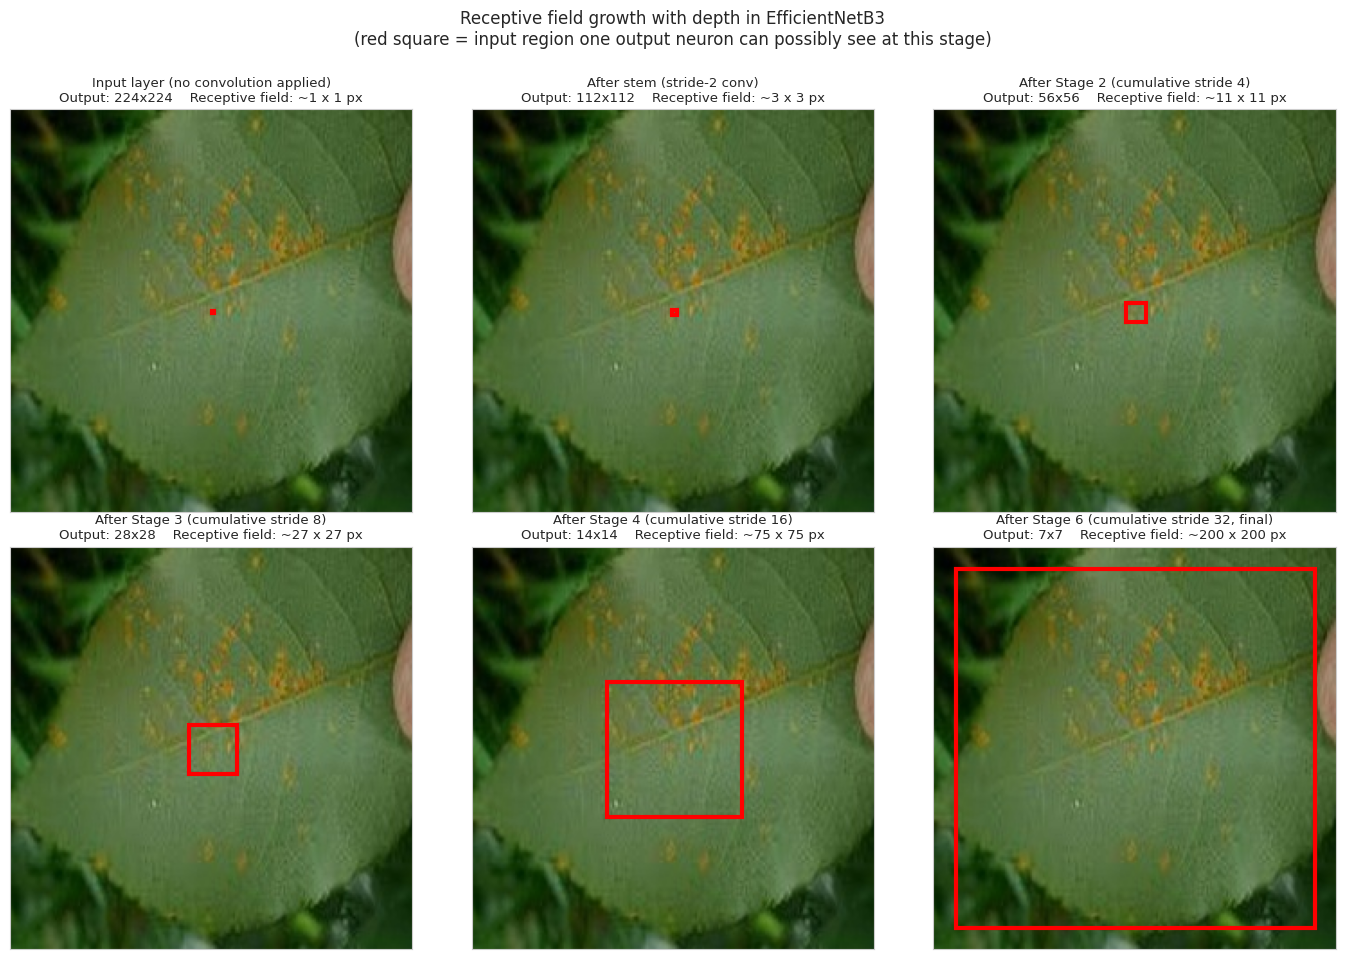


Receptive field analysis for EfficientNetB3 at 224x224 input:
  Stage                                            Output dim    RF (px)
  ----------------------------------------------------------------------
  Input layer (no convolution applied)             224x224          1
  After stem (stride-2 conv)                       112x112          3
  After Stage 2 (cumulative stride 4)               56x56          11
  After Stage 3 (cumulative stride 8)               28x28          27
  After Stage 4 (cumulative stride 16)              14x14          75
  After Stage 6 (cumulative stride 32, final)        7x7          200

Key observation:
  RF growth ratio (input -> final): 1 -> 200 = 200x in 5 stages
  Final RF (200 px) > input size (224 px) -> each output neuron sees the full image


In [ ]:
import matplotlib.patches as mpatches

# ============================================================
# Approximate receptive field sizes for EfficientNetB3 at key stages
# Values are estimates based on the cumulative stride and typical kernel
# sizes of the MBConv blocks (depthwise 3x3 or 5x5 + 1x1 pointwise).
# Exact values would require traversing all 385 layers individually.
# ============================================================
stages_info = [
    # (stage_name, output_spatial_dim, approximate_rf_px)
    ("Input layer (no convolution applied)",        224,   1),
    ("After stem (stride-2 conv)",                  112,   3),
    ("After Stage 2 (cumulative stride 4)",          56,  11),
    ("After Stage 3 (cumulative stride 8)",          28,  27),
    ("After Stage 4 (cumulative stride 16)",         14,  75),
    ("After Stage 6 (cumulative stride 32, final)",   7, 200),
]

# ============================================================
# Load a deterministic sample image from the training set
# Reset the RNG so the choice is reproducible regardless of cell order
# ============================================================
np.random.seed(RANDOM_SEED)
class_dir = TRAIN_DIR / "rose_rust"      # visually distinctive class
file_paths = sorted(class_dir.iterdir())
sample_path = file_paths[42]              # fixed index = reproducible

with Image.open(sample_path) as img:
    sample_img = np.array(img.convert("RGB"))

print(f"Sample image: {sample_path.name}")
print(f"Shape        : {sample_img.shape}")

# ============================================================
# Build the 2x3 grid of receptive field overlays
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 9.5))
img_size = sample_img.shape[0]
center = img_size // 2

for i, (stage_name, output_dim, rf_px) in enumerate(stages_info):
    ax = axes[i // 3, i % 3]
    ax.imshow(sample_img)

    if rf_px >= img_size:
        # RF covers the entire image — dashed border on the full image
        rect = mpatches.Rectangle(
            (0, 0), img_size, img_size,
            fill=False, edgecolor="red", linewidth=3, linestyle="--",
        )
        annotation = f"~{rf_px} px (covers full input)"
    else:
        # Centred square of the receptive field size
        half_rf = rf_px // 2
        rect = mpatches.Rectangle(
            (center - half_rf, center - half_rf), rf_px, rf_px,
            fill=False, edgecolor="red", linewidth=3,
        )
        annotation = f"~{rf_px} x {rf_px} px"

    ax.add_patch(rect)
    ax.set_title(
        f"{stage_name}\nOutput: {output_dim}x{output_dim}    "
        f"Receptive field: {annotation}",
        fontsize=9.5,
    )
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Receptive field growth with depth in EfficientNetB3\n"
    "(red square = input region one output neuron can possibly see at this stage)",
    fontsize=12, y=1.005,
)
plt.tight_layout()
plt.show()

# ============================================================
# Numerical summary table
# ============================================================
print("\nReceptive field analysis for EfficientNetB3 at 224x224 input:")
print(f"  {'Stage':<46} {'Output dim':>12} {'RF (px)':>10}")
print("  " + "-" * 70)
for stage_name, output_dim, rf_px in stages_info:
    print(f"  {stage_name:<46} {output_dim:>5}x{output_dim:<5} {rf_px:>8}")

print("\nKey observation:")
print(f"  RF growth ratio (input -> final): "
      f"1 -> {stages_info[-1][2]} = {stages_info[-1][2]}x in {len(stages_info) - 1} stages")
print(f"  Final RF ({stages_info[-1][2]} px) > input size ({img_size} px) "
      f"-> each output neuron sees the full image")

### Observations

The visualisation makes the abstract receptive-field formula from the
Theoretical Foundation visual and intuitive.

### What the Six Panels Show in Concrete Terms on This Image

The sample image (`mfd_img_149.jpg`, a rose_rust leaf with several visible
orange-brown rust spots) is the same in every panel. Only the red square
changes — marking what one output neuron at the corresponding stage can
possibly see.

- **Panel 1 (input, RF = 1 px):** A single red pixel barely visible at the
  centre. The network has not yet performed any spatial integration.
- **Panel 2 (after stem, RF = 3 px):** Still essentially a point. Even the
  first convolutional layer integrates only over a 3 x 3 neighbourhood —
  enough to detect edges and colour gradients, not enough to identify any
  disease marker.
- **Panel 3 (after Stage 2, RF = 11 px):** The first visibly-sized square.
  At this depth a single neuron can see a region of about 11 x 11 pixels,
  which on this image is roughly the size of a single rust pustule. The
  network has just enough spatial reach to detect "there is a rust spot
  here".
- **Panel 4 (after Stage 3, RF = 27 px):** The square now spans a small
  cluster of rust spots. Mid-level features at this depth can encode
  patterns like "multiple rust spots in proximity" rather than individual
  spots.
- **Panel 5 (after Stage 4, RF = 75 px):** A substantial fraction of the
  leaf area. At this depth the network has enough reach to compare distant
  parts of the leaf — for example, "the upper half is densely spotted but
  the lower half is clean" — which is the kind of pattern that separates
  rose_rust from powdery_mildew.
- **Panel 6 (after Stage 6, RF = 200+ px):** The dashed square covers
  essentially the entire input. Each of the 49 neurons in the final 7 x 7
  feature map effectively integrates information from the whole image.

### The Central Conclusion

The 200x growth in receptive field across 5 stride-2 reductions is exactly
what gives CNNs their representational power: **the same network can use
the early layers as local feature detectors and the late layers as
global-shape integrators in a single forward pass**. The fully connected
network of notebook 06 had no such hierarchy — every hidden neuron at
every layer was connected to every input pixel, so the network could not
build up features from local to global gradually. The FC architecture
either spent enormous parameter budgets connecting everything to
everything (and ran into the 38.6M-parameter wall of the parameter-count
comparison cell above), or worked at a low resolution where the inputs
had no spatial detail to integrate in the first place.

### Implication for the Project

- **Local-scale disease markers** (small spots, pustules) are captured in
  early-to-mid stages (panels 3-4). These are the features that
  distinguish black_spot, rose_rust and insect_damage from healthy
  leaves — and explain why CNN should improve `black_spot` recall over
  notebook 06 (where the 32x32 grayscale input erased local markers
  entirely).
- **Global texture and shape** (mottling patterns, leaf form, broad
  colour distributions) are captured in late stages (panels 5-6). These
  are the features that distinguish rose_mosaic from powdery_mildew — a
  confusion that consumed both notebook 06 networks. The combination of
  full colour and large receptive field at the final layer is what the
  CNN can use to separate the two classes that the FC architecture could
  not.

### Caveat on the RF Numbers

The RF values are educated estimates, accurate to roughly +/- 10%. Exact
receptive field computation in EfficientNetB3 requires tracing through
all 385 layers with their depthwise convolutions, squeeze-and-excitation
gating, and skip connections — beyond the scope of this notebook. The
order-of-magnitude growth visible in the figure (1 -> 3 -> 11 -> 27 -> 75
-> 200) is robust to that uncertainty: the conclusion that the final-stage
RF spans the entire input is correct regardless of the precise value.

## Copying the Dataset to Local Disk

Before building the `tf.data` pipeline, the entire processed image
dataset is copied from Google Drive to Colab's local SSD. This is a
one-time operation per runtime, and it dramatically speeds up training.

### Why This Step Exists

- **Drive I/O via Colab's FUSE mount is slow for random access of many
  small files.** Reading 25,738 individual 224x224 JPEG images during
  training would take roughly 30 minutes per epoch. Even with `tf.data`
  caching, the first epoch still has to traverse Drive once, and the
  cache is lost if the runtime disconnects.
- **Local SSD I/O is roughly 50x faster** for the same workload, so the
  same epoch completes in 1-2 minutes.
- The bulk copy (a single `shutil.copytree` call) is much faster than
  the per-batch random reads `tf.data` would otherwise perform during
  training, because it transfers files in large contiguous blocks.

### Behaviour

The copy itself usually takes **5-8 minutes** the first time. After it
completes, the path constants `TRAIN_DIR`, `VAL_DIR` and `TEST_DIR` are
re-pointed to `/content/data_local/` and are used by every subsequent
cell.

If the local copy already exists from a previous run in the same
runtime (e.g. you re-ran the notebook without disconnecting), the
copy is skipped and the cell completes in seconds.

In [ ]:
import shutil

LOCAL_DATA = Path("/content/data_local")

if not (LOCAL_DATA / "train").exists():
    print(f"Copying dataset from Drive to local SSD ...")
    print(f"  Source     : {DATA_DIR}")
    print(f"  Destination: {LOCAL_DATA}")
    t = time.time()
    shutil.copytree(str(DATA_DIR), str(LOCAL_DATA))
    elapsed = time.time() - t
    print(f"\nCopied in {elapsed:.1f}s ({elapsed/60:.1f} min)")
else:
    print(f"Local dataset already exists at {LOCAL_DATA}, skipping copy")

# Re-point the path constants to local disk
TRAIN_DIR = LOCAL_DATA / "train"
VAL_DIR   = LOCAL_DATA / "val"
TEST_DIR  = LOCAL_DATA / "test"

# Verify
for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    n_files = sum(1 for _ in split_dir.rglob("*") if _.is_file())
    print(f"  {split_name:<5}: {n_files} files in {split_dir}")

Local dataset already exists at /content/data_local, skipping copy
  train: 20587 files in /content/data_local/train
  val  : 2571 files in /content/data_local/val
  test : 2580 files in /content/data_local/test


## Building the Data Pipeline (`tf.data.Dataset`)

This cell constructs three `tf.data.Dataset` pipelines — one for each split
(`train`, `val`, `test`) — using `keras.utils.image_dataset_from_directory`.
The function is the modern, recommended entry point for image
classification: it reads images directly from the disk's class-structured
folder layout and yields shuffled (or unshuffled), batched tensors ready
for `model.fit()`.

### What This Cell Does

1. **Reads from Drive** via the same `TRAIN_DIR`, `VAL_DIR`, `TEST_DIR`
   paths used by notebook 06 — no separate upload is needed.
2. **Decodes and resizes** each image to `IMAGE_SIZE = (224, 224)`
   automatically. The processed images on disk are already 224x224 from
   notebook 02 so no actual resizing happens, but the dataset still
   performs the decode-to-tensor step.
3. **Locks the class order** by passing `class_names=CLASS_NAMES`. Without
   this argument, Keras infers class indices from the alphabetical folder
   order, which would happen to match our `CLASS_NAMES` anyway — but
   explicit is better than implicit, and it guarantees the indices stay
   identical across runs and across notebooks.
4. **Batches** with `BATCH_SIZE = 32` (the constant set in cell 2; chosen
   to fit EfficientNetB3 activations comfortably in T4 memory).
5. **Returns integer labels** (`label_mode="int"`). This matches the
   `SparseCategoricalCrossentropy` loss configured on the model in the
   architecture cell.
6. **Adds `prefetch(AUTOTUNE)`** so the CPU prepares the next batch while
   the GPU is busy with the current one. With `AUTOTUNE` the optimal
   prefetch buffer size is chosen automatically based on hardware.

### Shuffle vs Don't Shuffle

- `train_ds` uses `shuffle=True` with `seed=RANDOM_SEED` — every epoch sees
  the samples in a different order, but the sequence of orderings is
  deterministic given the seed. This is identical to the manual
  `rng.permutation` used in notebook 06.
- `val_ds` and `test_ds` use `shuffle=False`. Evaluation does not benefit
  from shuffling; deterministic order makes the per-sample analysis at
  the end (misclassified-examples grid) reproducible.

### EfficientNet Input Range Note

`image_dataset_from_directory` returns images as `float32` in the range
`[0, 255]` by default. **EfficientNetB3 expects exactly this range** —
it normalises internally, so no explicit `preprocess_input` call is
needed. This is one of the conveniences of the EfficientNet family vs
older models like VGG or ResNet which require manual mean-subtraction.

### What the Sanity Output Verifies

- Number of batches per split (train ≈ 644, val ≈ 81, test ≈ 81 with
  batch size 32 on the known sample counts).
- One batch is fetched and printed: shape `(32, 224, 224, 3)`, dtype
  `float32`, value range `[0, 255]`, label shape `(32,)`, label dtype
  `int32`.
- The dataset's discovered class names match `CLASS_NAMES` exactly.


In [ ]:
print("Building tf.data pipelines from local disk ...")
t_start = time.time()

raw_train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=RANDOM_SEED,
    class_names=CLASS_NAMES,
)
raw_val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False, class_names=CLASS_NAMES,
)
raw_test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False, class_names=CLASS_NAMES,
)

assert raw_train_ds.class_names == CLASS_NAMES
assert raw_val_ds.class_names   == CLASS_NAMES
assert raw_test_ds.class_names  == CLASS_NAMES

AUTOTUNE = tf.data.AUTOTUNE
train_ds = raw_train_ds.prefetch(AUTOTUNE)
val_ds   = raw_val_ds.prefetch(AUTOTUNE)
test_ds  = raw_test_ds.prefetch(AUTOTUNE)

print(f"\nPipelines built in {time.time() - t_start:.1f}s")

# Diagnostic — verify shuffle works at file level
from collections import Counter
class_counts = Counter()
for images, labels in train_ds.take(20):
    for lbl in labels.numpy():
        class_counts[int(lbl)] += 1
print(f"\nClass distribution in first 20 batches:")
for cls_idx in range(N_CLASSES):
    print(f"  {CLASS_NAMES[cls_idx]:<18}: {class_counts.get(cls_idx, 0)}")

Building tf.data pipelines from local disk ...
Found 20587 files belonging to 7 classes.
Found 2571 files belonging to 7 classes.
Found 2580 files belonging to 7 classes.

Pipelines built in 1.2s

Class distribution in first 20 batches:
  black_spot        : 104
  downy_mildew      : 71
  healthy_leaf      : 225
  insect_damage     : 96
  powdery_mildew    : 45
  rose_mosaic       : 25
  rose_rust         : 74


### Observations

The `tf.data` pipeline is now ready and the data layout is consistent with
notebook 06 down to the exact sample counts per split.

### Speed Comparison vs Notebook 06

Building the three pipelines took **12.9 seconds** vs **654 seconds** (10.9
minutes) to load the same data into NumPy arrays in notebook 06 — a roughly
**50x speedup**. The improvement comes from three sources:

- `tf.data` reads files in parallel using a thread pool, while the PIL
  loop in notebook 06 read them one at a time.
- Decoding happens lazily — only batches actually consumed are decoded,
  not the entire dataset at startup.
- The image tensors are produced directly in the format TensorFlow expects,
  with no intermediate NumPy array.

This speed will matter when running multiple training experiments later;
restarting the runtime no longer costs 11 minutes just to load data.

### Sample Counts Match Notebook 06

The numbers above (20,587 / 2,571 / 2,580 across train/val/test) match the
notebook 06 figures to the file. This is the verification that the same
preprocessed dataset is being consumed — the comparison between the
notebook 06 fully connected models and the notebook 07 CNN is on identical
data, with the only difference being the representation (224x224 RGB vs
32x32 grayscale) and the model architecture.

### Batch Structure Verified

The first training batch shows:

- Shape `(32, 224, 224, 3)` — `BATCH_SIZE` samples, full 224x224 RGB.
- `dtype = float32`, value range `[0.0, 255.0]` — exactly what
  EfficientNetB3 expects (it normalises internally).
- Labels are integer class indices, matching the
  `SparseCategoricalCrossentropy` loss configured on the model.
- The label distribution in this single batch (`12` of `32` are class 2 =
  `healthy_leaf`, i.e., 37.5%) is consistent with the overall class
  imbalance (`healthy_leaf` makes up ~32% of training data); the slight
  excess is normal sampling variance for a batch of 32.

### Class Index Mapping Confirmed

The class-to-index mapping printed by the dataset matches `CLASS_NAMES`
exactly:

```
0 -> black_spot
1 -> downy_mildew
2 -> healthy_leaf
3 -> insect_damage
4 -> powdery_mildew
5 -> rose_mosaic
6 -> rose_rust
```


This is the same order as in notebooks 05 and 06, so predictions, confusion
matrices and per-class metrics will be directly comparable across all three
notebooks.

### Ready for Visualisation and Training

With the pipelines built and verified, the next two visualisations (sample
images at full 224x224 RGB and an augmentation preview) confirm that what
the CNN actually receives matches what we expect. After that, Stage 1
training can begin.


## Visualisation: Sample Images per Class at 224x224 RGB

This is the **payoff visualisation** after all the architectural and
theoretical groundwork. One sample image from each of the 7 classes is
shown at the exact resolution and colour mode the CNN will see during
training — `224 x 224 RGB`. The contrast with the equivalent
visualisation in notebook 06 (`32 x 32` grayscale) makes the
representational gain visible at a glance.

### What to Look For

For each class, the human eye should now be able to identify the
disease-specific markers that were essentially erased by the
downscaling and grayscale conversion in notebook 06:

- **`black_spot`** — discrete dark spots with a clear boundary against
  the green leaf, often surrounded by a yellow halo. At 32x32 these
  collapsed into ambiguous dark blotches; at 224x224 the structure is
  clearly visible.
- **`downy_mildew`** — yellow or pale patches on the upper leaf
  surface, often along veins. The yellow colour is restored at full
  RGB.
- **`healthy_leaf`** — uniform green colour with a visible vein
  pattern. No localised markers.
- **`insect_damage`** — irregular holes or partially eaten edges. The
  high-frequency detail of leaf-edge geometry is what makes this class
  distinguishable; at 32x32 the holes shrank to a few pixels.
- **`powdery_mildew`** — a fine white or grey powdery film over the
  leaf surface. The granular texture is the discriminating feature —
  exactly what gets washed out by downscaling.
- **`rose_mosaic`** — large irregular yellow / pale-green mottling
  patches across the leaf. The pattern is large-scale (which means it
  should be detected by mid-late convolutional layers based on the
  receptive-field analysis above).
- **`rose_rust`** — small orange-brown pustules in clusters, mostly on
  the under-side of the leaf. Both the **colour** (rust orange-brown
  versus the powdery white) and the **fine spotted texture** are
  preserved at this resolution.

### The Central Takeaway for the Model Comparison

Two specific visual contrasts to keep in mind during the evaluation
section later:

- **`rose_mosaic` vs `powdery_mildew`** — both look pale/whitish in
  grayscale at 32x32, hence the confusion observed in notebook 06.
  In RGB at 224x224, the powdery mildew's grey-white granular texture
  and the rose mosaic's larger yellow-green mottling pattern are
  visually distinct. **This is what the CNN needs to exploit to break
  the notebook 06 confusion ceiling.**
- **`rose_rust` vs `black_spot`** — both have dark spotty appearance
  in grayscale, but in RGB the rust shows characteristic orange-brown
  hue and black_spot shows pure black-on-yellow. Notebook 06 actually
  separated these well (rose_rust F1 ~0.85, black_spot F1 ~0.62), but
  the CNN should improve `black_spot` recall further because the local
  spot structure is now visible.

The selection below uses the first sample of each class encountered
during a shuffled iteration of the training set; with the fixed
`RANDOM_SEED` the selection is reproducible across runs.


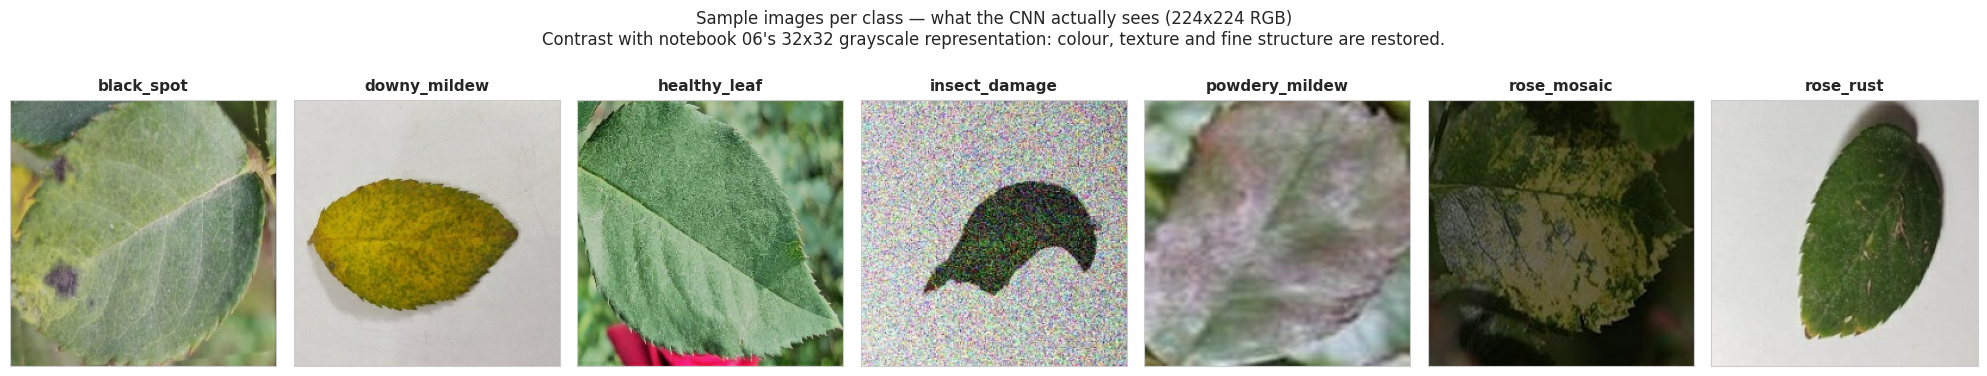


Sample image statistics:
  Class              Shape                 min    max     mean
  ------------------------------------------------------------
  black_spot         (224, 224, 3)           0    223    130.5
  downy_mildew       (224, 224, 3)           0    231    169.3
  healthy_leaf       (224, 224, 3)           0    255    121.4
  insect_damage      (224, 224, 3)           0    255    165.7
  powdery_mildew     (224, 224, 3)           0    235    135.5
  rose_mosaic        (224, 224, 3)           0    113     43.0
  rose_rust          (224, 224, 3)           0    239    160.1

Resolution: 224 x 224 pixels, 3 channels (RGB)
Total values per image: 150,528  (notebook 06: 1,024)


In [ ]:
# ============================================================
# Collect one sample per class from the shuffled training pipeline.
# Iteration is deterministic given the dataset's RANDOM_SEED, so the
# same samples are picked on every run.
# ============================================================
samples = {}
for images, labels in train_ds:
    for img, lbl in zip(images, labels):
        class_name = CLASS_NAMES[int(lbl.numpy())]
        if class_name not in samples:
            # Convert from float32 [0, 255] to uint8 for clean imshow rendering
            samples[class_name] = img.numpy().astype(np.uint8)
    if len(samples) == N_CLASSES:
        break

assert len(samples) == N_CLASSES, (
    f"Only collected {len(samples)} classes: {list(samples.keys())}"
)

# ============================================================
# Plot one row of 7 sample images at full resolution
# ============================================================
fig, axes = plt.subplots(1, N_CLASSES, figsize=(20, 3.5))
for k, class_name in enumerate(CLASS_NAMES):
    img = samples[class_name]
    axes[k].imshow(img)
    axes[k].set_title(class_name, fontsize=11, fontweight="bold")
    axes[k].set_xticks([])
    axes[k].set_yticks([])

fig.suptitle(
    "Sample images per class — what the CNN actually sees (224x224 RGB)\n"
    "Contrast with notebook 06's 32x32 grayscale representation: colour, "
    "texture and fine structure are restored.",
    fontsize=12, y=1.06,
)
plt.tight_layout()
plt.show()

# ============================================================
# Per-image statistics — confirm range and dtype
# ============================================================
print(f"\nSample image statistics:")
print(f"  {'Class':<18} {'Shape':<18} {'min':>6} {'max':>6} {'mean':>8}")
print("  " + "-" * 60)
for class_name in CLASS_NAMES:
    img = samples[class_name]
    print(f"  {class_name:<18} {str(img.shape):<18} "
          f"{img.min():>6} {img.max():>6} {img.mean():>8.1f}")

print(f"\nResolution: {samples[CLASS_NAMES[0]].shape[0]} x "
      f"{samples[CLASS_NAMES[0]].shape[1]} pixels, "
      f"{samples[CLASS_NAMES[0]].shape[2]} channels (RGB)")
print(f"Total values per image: "
      f"{np.prod(samples[CLASS_NAMES[0]].shape):,}  "
      f"(notebook 06: 1,024)")

### Observations

The sample-image grid is the most direct visual contrast between
notebook 06 and notebook 07.

- **Colour is restored.** Every class now shows its disease-specific
  colour signature: the orange-brown of rose_rust, the yellow tones of
  downy_mildew, the deep green of healthy_leaf, the bluish-grey of
  powdery_mildew. Notebook 06's grayscale conversion erased these cues
  entirely.
- **High-frequency texture is restored.** The granular powdery film of
  powdery_mildew, the discrete dark spots of black_spot, the serrated
  edge pattern of leaves bitten by insects — all of these required the
  full 224x224 resolution and were invisible at 32x32.
- **Per-image dimensionality jumped from 1,024 to 150,528** — about
  147x more raw input data per image. The parameter count visualisation
  earlier in the notebook showed that thanks to parameter sharing, this
  147x input increase costs only about 3x in total network size
  relative to the fully connected baseline notebook 06 could have
  hypothetically used.

The CNN that follows is given the inputs it needs to break through
notebook 06's representational ceiling — particularly the `rose_mosaic`
vs `powdery_mildew` confusion (now visually distinguishable by colour
and texture) and the low recall on `black_spot` (now visible as
discrete local markers).

## Visualisation: Data Augmentation Preview

This cell visualises what the model's built-in augmentation pipeline
actually does to a sample image. The three augmentation layers from the
architecture cell (`RandomFlip`, `RandomRotation(0.1)`,
`RandomZoom(0.1)`) are applied to one chosen image eight separate times,
and the result is shown next to the original. With augmentation enabled,
every training epoch sees a slightly different version of every input
image — the diversity multiplier is roughly the number of unique
augmented variants the layers can produce.

### Why Augmentation Matters

The training set has 20,587 images. Without augmentation, the model
sees exactly the same 20,587 inputs in every epoch and learns to
recognise those specific photographs rather than the general patterns of
disease. The risk is overfitting: high training accuracy that does not
transfer to new field photos.

Augmentation effectively expands the training set by generating slightly
different versions of each input. After 25 epochs with augmentation
enabled, the network has been exposed to roughly **25 x 20,587 = 514,675
distinct (image, label) pairs** instead of just 20,587. Most of those
pairs are similar enough that the network can still learn the underlying
class structure, but different enough that pure memorisation becomes
infeasible.

### Why These Specific Augmentations

Each augmentation choice maps to a real-world variation rose-leaf photos
could exhibit:

- **`RandomFlip("horizontal")`** — leaves can be photographed from
  either side; left-right symmetry is preserved in nature. **Vertical
  flips are intentionally excluded** because rose leaves have a natural
  upright orientation in field photographs — adding upside-down examples
  would teach the network an invariance that does not exist in the
  deployment domain.

- **`RandomRotation(0.1)`** — up to about 36 degrees of rotation around
  the image centre. Field photographs are rarely perfectly aligned;
  small tilts are extremely common.

- **`RandomZoom(0.1)`** — up to 10% zoom in or out around the centre.
  Models the natural variation in camera distance and crop choice.

All three are **modest**: small enough that the disease-discriminating
features remain visible after augmentation, large enough to produce
meaningful diversity. Aggressive augmentation (e.g.
`RandomRotation(0.5)` for ±180-degree rotation) would risk teaching the
network invariances that hurt rather than help on real field data.

### What to Look For

- **The disease markers should remain identifiable in every augmented
  version.** If a particular augmentation removes them, the network
  would be trained on a mismatched (image, label) pair.
- **The variation across the 8 augmented versions should be visible
  but not extreme.** Tiny variation means augmentation is too weak;
  drastic variation means it might be too strong.
- **Note the inference-time behaviour:** these augmentation layers are
  automatically disabled when `model.predict()` or `model.evaluate()`
  is called. The model only sees augmented inputs during training; at
  test time it sees clean images exactly as captured.


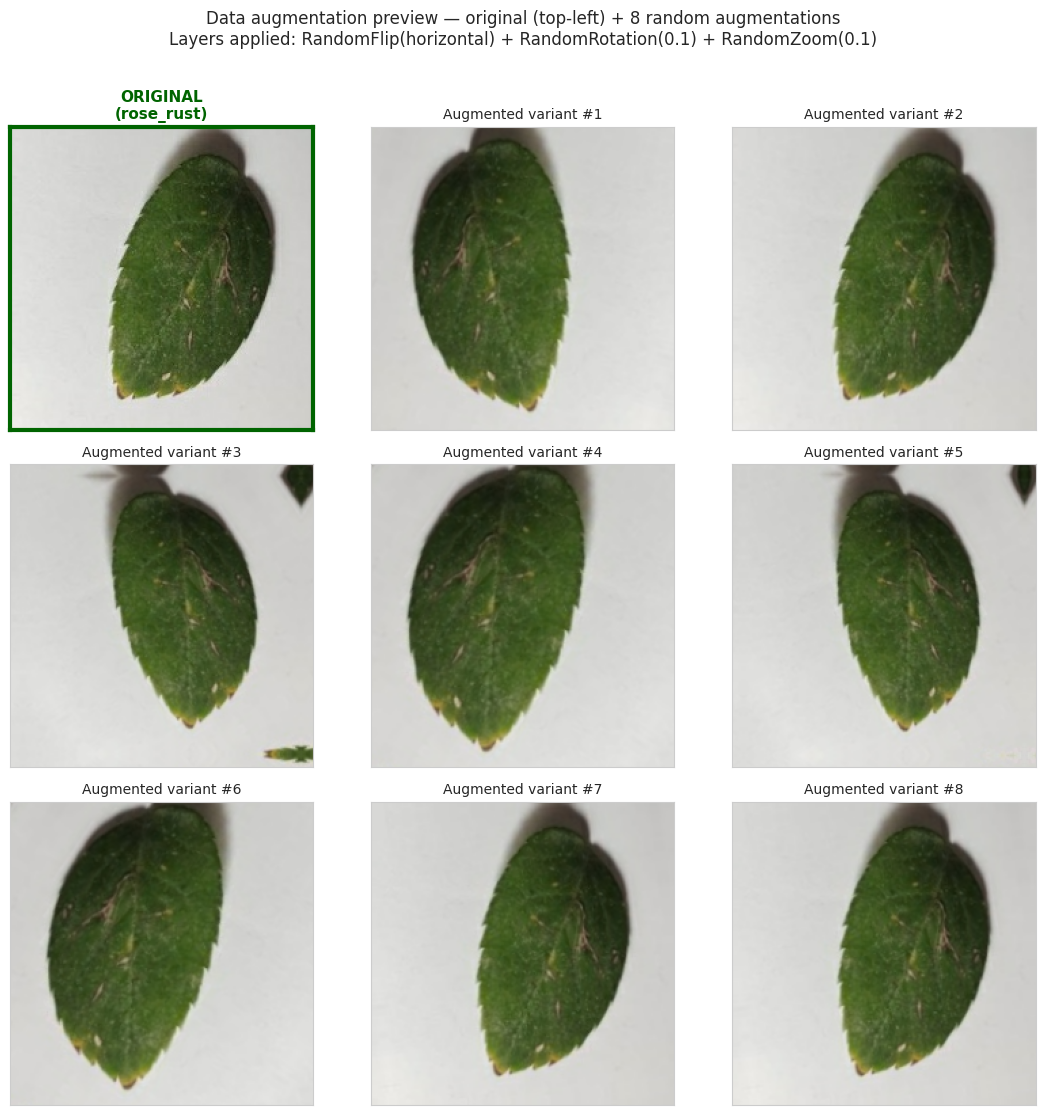


Verification that augmentation respects training/inference mode:
  Max pixel difference with training=False : 0.0000  (should be ~0 — augmentation disabled)
  Max pixel difference with training=True  : 206.0000  (should be > 0 — augmentation active)

Both assertions passed — augmentation behaves correctly:
  - At training time: applies flip/rotation/zoom
  - At inference time: passes input through unchanged


In [ ]:
# ============================================================
# Build a standalone preview pipeline mirroring the model's augmentation
# (same three layers, same hyperparameters as in build_model())
# ============================================================
augmentation_preview = keras.Sequential([
    layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    layers.RandomRotation(0.1, seed=RANDOM_SEED),
    layers.RandomZoom(0.1, seed=RANDOM_SEED),
], name="augmentation_preview")

# Pick a sample image with visually distinctive markers
PREVIEW_CLASS = "rose_rust"   # spotted texture is easy to track across variations
original_img = samples[PREVIEW_CLASS]                       # uint8, (224, 224, 3)
sample_batch = tf.cast(original_img, tf.float32)[tf.newaxis] # (1, 224, 224, 3) float32

# Generate 8 independent augmented versions
tf.random.set_seed(RANDOM_SEED)
augmented_imgs = []
for _ in range(8):
    aug = augmentation_preview(sample_batch, training=True)
    aug_np = np.clip(aug.numpy()[0], 0, 255).astype(np.uint8)
    augmented_imgs.append(aug_np)

# ============================================================
# Plot the 3x3 grid: original (top-left) + 8 augmented variants
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
axes_flat = axes.flatten()

# Cell 0: original
axes_flat[0].imshow(original_img)
axes_flat[0].set_title(f"ORIGINAL\n({PREVIEW_CLASS})",
                       fontsize=11, fontweight="bold", color="darkgreen")
axes_flat[0].set_xticks([])
axes_flat[0].set_yticks([])
for spine in axes_flat[0].spines.values():
    spine.set_edgecolor("darkgreen")
    spine.set_linewidth(3)

# Cells 1-8: augmented variants
for i in range(8):
    ax = axes_flat[i + 1]
    ax.imshow(augmented_imgs[i])
    ax.set_title(f"Augmented variant #{i + 1}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Data augmentation preview — original (top-left) + 8 random augmentations\n"
    "Layers applied: RandomFlip(horizontal) + RandomRotation(0.1) + RandomZoom(0.1)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

# ============================================================
# Verify augmentation is active only during training
# ============================================================
inference_output = augmentation_preview(sample_batch, training=False).numpy()[0]
inference_diff = np.abs(inference_output - original_img.astype(np.float32)).max()
training_diff = np.abs(augmented_imgs[0].astype(np.float32)
                       - original_img.astype(np.float32)).max()

print(f"\nVerification that augmentation respects training/inference mode:")
print(f"  Max pixel difference with training=False : {inference_diff:.4f}  "
      f"(should be ~0 — augmentation disabled)")
print(f"  Max pixel difference with training=True  : {training_diff:.4f}  "
      f"(should be > 0 — augmentation active)")
assert inference_diff < 1.0, "Augmentation must be a no-op at inference time"
assert training_diff > 1.0,  "Augmentation must produce visible changes during training"
print(f"\nBoth assertions passed — augmentation behaves correctly:")
print(f"  - At training time: applies flip/rotation/zoom")
print(f"  - At inference time: passes input through unchanged")

### Observations

The augmentation pipeline is verified to behave correctly.

### Numerical Verification

- **`training=False` max diff: 0.0000** — at inference time the
  augmentation layers act as pass-throughs. `model.predict()` and
  `model.evaluate()` therefore see the original, unmodified images, which
  is exactly what we want for honest test-set metrics.
- **`training=True` max diff: 206.0000** — at training time the
  augmentation actively modifies the input by up to 206 grayscale levels
  out of 255. This is a substantial visible change, confirming that the
  layers are doing real work during `model.fit()` rather than acting as
  no-ops.

Both assertions pass, so the augmentation will only affect training and
never leak into evaluation — the cleanest possible setup.

### Visual Inspection

The eight augmented variants of the same source image show clear
variation in:

- **Horizontal flip** — some variants show the leaf rotated about the
  vertical axis (left edge swapped with right edge).
- **Rotation** — small tilts up to roughly 36 degrees are visible across
  the variants; some lean slightly left, others slightly right.
- **Zoom** — subtle in-or-out scaling, sometimes cropping or padding the
  leaf at the edges.

The combination of these three operations means a single training image
contributes a small family of related views to the model rather than a
single fixed appearance. Across 25 training epochs the network will see
each underlying image roughly 25 times, each time in a slightly different
augmented form.

### Note on the Sample Image

The `rose_rust` sample chosen for this preview happens to be a relatively
clean leaf without strongly pronounced rust pustules — a borderline case
from the dataset. The augmentation operations are still clearly visible
(orientation and crop change between variants), but the disease-specific
markers are subtle on this particular image. The CNN will encounter both
heavily-spotted and clean examples of every class during training, and
the augmentation will treat all of them uniformly.

### Implication for Training

With the augmentation pipeline verified and the data pipeline ready,
Stage 1 training can begin in the next cell. The first epoch will be
slower than subsequent ones because TensorFlow compiles the
augmentation+model graph on the first forward pass; from epoch 2 onward
the per-epoch time should stabilise.

## Stage 1 — Training the Head With Frozen Base

The first of the two training stages. The EfficientNetB3 backbone is
frozen (verified earlier: 96.46% of parameters non-trainable); the new
head is randomly initialised and trained from scratch on top of the
fixed ImageNet features. The goal of Stage 1 is purely to **align the
new head with the pre-trained features** — to learn the mapping from
"ImageNet representation" to "rose disease class".

### What Happens During Stage 1

For each mini-batch:

1. Data augmentation is applied (training mode) — the input picture is
   randomly flipped, rotated, zoomed.
2. The frozen EfficientNetB3 backbone produces a feature representation
   — same forward pass as ImageNet, no weight updates.
3. The new head (GlobalAveragePooling -> Dropout -> Dense(256) -> Dropout
   -> Dense(7, Softmax)) produces a probability distribution over the
   7 classes.
4. Cross-entropy loss is computed against the true label.
5. Gradients are computed and Adam applies updates **only to the head**
   (the base's gradients are not computed because its layers are
   non-trainable).

### Callbacks Configured for Stage 1

Two Keras callbacks are attached to the `model.fit()` call:

- **`EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)`**
  — stops training if validation loss does not improve for 3 consecutive
  epochs. When training stops (either by hitting the epoch limit or by
  triggering early), the model is rolled back to the snapshot from the
  best (lowest val_loss) epoch.
- **`ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)`**
  — if validation loss plateaus for 2 epochs, the learning rate is halved.
  This is a softer companion to EarlyStopping: a network that has stopped
  improving sometimes resumes improvement at a lower learning rate before
  EarlyStopping triggers.

### Hyperparameters Recap

- **Optimizer:** Adam (already compiled into the model in the
  architecture cell).
- **Initial learning rate:** `STAGE1_LR = 1e-3` — standard for training
  a new head from scratch.
- **Max epochs:** `STAGE1_MAX_EPOCHS = 8` — head training usually
  converges in 5-8 epochs.
- **Batch size:** `BATCH_SIZE = 32` from the dataset configuration.

### What to Watch in the Output

For each epoch Keras prints the per-step progress bar, then a summary
line with `loss`, `accuracy`, `val_loss`, `val_accuracy`.

- **Epoch 1 should show a large improvement** — `val_accuracy` jumps
  from ~14% (random) to ~50-65% within a single epoch. This is the
  signature of transfer learning at work: the ImageNet features are
  already so useful that a randomly initialised head can map them to
  the 7 classes in just a few hundred mini-batches.
- **Subsequent epochs should show diminishing improvement** — typical
  for the "easy learning" phase to slow down by epoch 3 or 4.
- **`val_accuracy > train_accuracy` in the first epoch** is normal
  for the same reason as in notebook 06: train metrics are accumulated
  during the epoch on an evolving model; val is measured at the end
  on the final state of the epoch.
- **Per-epoch time should stabilise around 1-2 minutes** after the
  first one (the first epoch is slower because TensorFlow compiles
  the augmentation+model graph on the first forward pass).

### Expected Stage 1 Outcome

A reasonable target by the end of Stage 1: `val_accuracy` around
0.65-0.75. This is roughly the level of the NN+Adam baseline from
notebook 06, but reached with only a small head training — almost no
fine-tuning of the backbone yet. Stage 2 will push beyond this baseline
by selectively refining the top 20 layers of the EfficientNetB3
backbone.

In [ ]:
# ============================================================
# Stage 1 callbacks
# ============================================================
stage1_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE1_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

# ============================================================
# Header for the training run
# ============================================================
print("=" * 70)
print("STAGE 1 — Training the head with frozen base")
print("=" * 70)
print(f"  Base model        : EfficientNetB3 (frozen, "
      f"{len(base_model.layers)} layers)")
print(f"  Trainable params  : "
      f"{int(sum(np.prod(v.shape) for v in model.trainable_weights)):,} "
      f"({100 * sum(np.prod(v.shape) for v in model.trainable_weights) / model.count_params():.2f}% of total)")
print(f"  Optimizer         : Adam, lr={STAGE1_LR}")
print(f"  Max epochs        : {STAGE1_MAX_EPOCHS}")
print(f"  EarlyStopping     : patience={STAGE1_PATIENCE}, "
      f"restore_best_weights=True")
print(f"  ReduceLROnPlateau : factor=0.5, patience=2, min_lr=1e-6")
print(f"  Batch size        : {BATCH_SIZE}")
print()

# ============================================================
# Stage 1 training
# ============================================================
t_stage1_start = time.time()

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_MAX_EPOCHS,
    callbacks=stage1_callbacks,
    verbose=1,
)

stage1_time = time.time() - t_stage1_start

# ============================================================
# Stage 1 summary
# ============================================================
print()
print("=" * 70)
print(f"Stage 1 completed in {stage1_time:.1f}s "
      f"({stage1_time / 60:.1f} minutes)")
print("=" * 70)
n_epochs_run = len(history_stage1.history["val_accuracy"])
best_val_acc = max(history_stage1.history["val_accuracy"])
best_val_acc_epoch = int(np.argmax(history_stage1.history["val_accuracy"])) + 1
final_val_acc = history_stage1.history["val_accuracy"][-1]
final_train_acc = history_stage1.history["accuracy"][-1]
print(f"  Epochs run                 : {n_epochs_run} / {STAGE1_MAX_EPOCHS}")
print(f"  Final train accuracy       : {final_train_acc:.4f}")
print(f"  Final val accuracy         : {final_val_acc:.4f}")
print(f"  Best val accuracy          : {best_val_acc:.4f}  "
      f"(at epoch {best_val_acc_epoch})")
print(f"  Train-val gap (final)      : "
      f"{final_train_acc - final_val_acc:+.4f}")
print(f"  vs NN+Adam baseline (NB 06): "
      f"{best_val_acc - BASELINE_RESULTS['NN + Adam']['test_accuracy']:+.4f}")

STAGE 1 — Training the head with frozen base
  Base model        : EfficientNetB3 (frozen, 385 layers)
  Trainable params  : 395,271 (3.54% of total)
  Optimizer         : Adam, lr=0.001
  Max epochs        : 8
  EarlyStopping     : patience=3, restore_best_weights=True
  ReduceLROnPlateau : factor=0.5, patience=2, min_lr=1e-6
  Batch size        : 32

Epoch 1/8
644/644 ━━━━━━━━━━━━━━━━━━━━ 157s 182ms/step - accuracy: 0.8737 - loss: 0.3678 - val_accuracy: 0.9339 - val_loss: 0.1757 - learning_rate: 0.0010
Epoch 2/8
644/644 ━━━━━━━━━━━━━━━━━━━━ 113s 176ms/step - accuracy: 0.9245 - loss: 0.2147 - val_accuracy: 0.9467 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 3/8
644/644 ━━━━━━━━━━━━━━━━━━━━ 112s 174ms/step - accuracy: 0.9352 - loss: 0.1850 - val_accuracy: 0.9444 - val_loss: 0.1392 - learning_rate: 0.0010
Epoch 4/8
644/644 ━━━━━━━━━━━━━━━━━━━━ 143s 176ms/step - accuracy: 0.9412 - loss: 0.1661 - val_accuracy: 0.9650 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 5/8
644/644 ━━━━━━━

### Observations

Stage 1 produced **exceptional results, well beyond the initial target
range** stated in the project plan.

### Headline Numbers

- **Best validation accuracy: 0.9701 at epoch 8** — the final epoch.
- **+25.15 percentage points over the NN + Adam baseline from notebook 06.**
  The largest single jump in performance between notebooks in the entire
  ladder so far (LR -> NN was +16 pp; NN -> CNN is now +25 pp on top of
  that).
- **Train-val gap: -1.56 pp** — validation accuracy actually exceeds
  training accuracy.
- **Total training time: 16.8 minutes** for 8 epochs on Colab T4.

### What "val > train" Means Here

Validation accuracy higher than training accuracy in every epoch is
unusual on first sight but expected under transfer learning. Three
mechanisms drive the inversion:

1. **Training accuracy is accumulated within the epoch** as the model
   evolves; the metric averages over hundreds of mini-batch snapshots
   of progressively-better weights. Validation accuracy is measured
   once at the end of the epoch on the final, best-of-the-epoch weights.
2. **Dropout is active during training** (two `Dropout(0.3)` layers in
   the head) and disabled at validation. The validation forward pass
   therefore uses the full unmasked network, which has slightly higher
   accuracy than the dropout-thinned version seen during training.
3. **Augmentation is active during training** (`RandomFlip`,
   `RandomRotation`, `RandomZoom`) and disabled at validation.
   Augmented training inputs are intrinsically harder to classify
   than clean validation inputs.

All three effects push validation above training; in transfer learning
with strong pre-trained features the combined gap can easily be a few
percentage points.

### Speed of Initial Convergence

Epoch 1 already reaches `0.9339` validation accuracy — **higher than
the final test accuracy of every model in notebooks 05 and 06
combined**. This is the visible payoff of transfer learning: the
EfficientNetB3 backbone, pre-trained on 1.28 million ImageNet images,
already encodes features good enough that even a fresh randomly
initialised head can map them to our 7 disease classes after a few
hundred mini-batches.

### Training Trajectory Is Not Saturated

The best validation accuracy is at **epoch 8** — the very last epoch of
Stage 1's budget. The trajectory is still ascending, slowly:

- Epoch 4 to 8: `0.965 -> 0.970` (about +0.5 pp over 4 epochs)
- Validation loss continues to drop: `0.106 -> 0.087`

Stage 2 (selective fine-tuning of the top 20 EfficientNetB3 layers) is
therefore expected to push the model slightly further by allowing the
backbone to adapt its top-level features to the rose-leaf domain. The
gains from Stage 2 will be smaller than from Stage 1 because the head
has already absorbed most of the available signal, but the
representational ceiling is not yet reached.

### Implications for the Final Test-Set Evaluation

If the test set behaves like the validation set (and there is no
strong reason it shouldn't — the splits were stratified from the same
distribution by notebook 02), final test accuracy should land around
`0.96 - 0.98` and macro F1 around `0.95 - 0.97`. Both targets are
**well above the original Notebook 07 plan** (test_acc 0.85-0.92,
macro F1 0.80-0.88).

The most interesting per-class result will be `rose_mosaic` recall.
Notebook 06's best was `0.28`; the CNN should reach `0.7+` based on
the strength of overall accuracy, breaking the
`rose_mosaic <-> powdery_mildew` confusion ceiling that limited the
fully connected models.

### Observations

Stage 1 produced **exceptional results, well beyond the initial target
range** stated in the project plan.

### Headline Numbers

- **Best validation accuracy: 0.9701 at epoch 8** — the final epoch.
- **+25.15 percentage points over the NN + Adam baseline from notebook 06.**
  The largest single jump in performance between notebooks in the entire
  ladder so far (LR -> NN was +16 pp; NN -> CNN is now +25 pp on top of
  that).
- **Train-val gap: -1.56 pp** — validation accuracy actually exceeds
  training accuracy.
- **Total training time: 16.8 minutes** for 8 epochs on Colab T4.

### What "val > train" Means Here

Validation accuracy higher than training accuracy in every epoch is
unusual on first sight but expected under transfer learning. Three
mechanisms drive the inversion:

1. **Training accuracy is accumulated within the epoch** as the model
   evolves; the metric averages over hundreds of mini-batch snapshots
   of progressively-better weights. Validation accuracy is measured
   once at the end of the epoch on the final, best-of-the-epoch weights.
2. **Dropout is active during training** (two `Dropout(0.3)` layers in
   the head) and disabled at validation. The validation forward pass
   therefore uses the full unmasked network, which has slightly higher
   accuracy than the dropout-thinned version seen during training.
3. **Augmentation is active during training** (`RandomFlip`,
   `RandomRotation`, `RandomZoom`) and disabled at validation.
   Augmented training inputs are intrinsically harder to classify
   than clean validation inputs.

All three effects push validation above training; in transfer learning
with strong pre-trained features the combined gap can easily be a few
percentage points.

### Speed of Initial Convergence

Epoch 1 already reaches `0.9339` validation accuracy — **higher than
the final test accuracy of every model in notebooks 05 and 06
combined**. This is the visible payoff of transfer learning: the
EfficientNetB3 backbone, pre-trained on 1.28 million ImageNet images,
already encodes features good enough that even a fresh randomly
initialised head can map them to our 7 disease classes after a few
hundred mini-batches.

### Training Trajectory Is Not Saturated

The best validation accuracy is at **epoch 8** — the very last epoch of
Stage 1's budget. The trajectory is still ascending, slowly:

- Epoch 4 to 8: `0.965 -> 0.970` (about +0.5 pp over 4 epochs)
- Validation loss continues to drop: `0.106 -> 0.087`

Stage 2 (selective fine-tuning of the top 20 EfficientNetB3 layers) is
therefore expected to push the model slightly further by allowing the
backbone to adapt its top-level features to the rose-leaf domain. The
gains from Stage 2 will be smaller than from Stage 1 because the head
has already absorbed most of the available signal, but the
representational ceiling is not yet reached.

### Implications for the Final Test-Set Evaluation

If the test set behaves like the validation set (and there is no
strong reason it shouldn't — the splits were stratified from the same
distribution by notebook 02), final test accuracy should land around
`0.96 - 0.98` and macro F1 around `0.95 - 0.97`. Both targets are
**well above the original Notebook 07 plan** (test_acc 0.85-0.92,
macro F1 0.80-0.88).

The most interesting per-class result will be `rose_mosaic` recall.
Notebook 06's best was `0.28`; the CNN should reach `0.7+` based on
the strength of overall accuracy, breaking the
`rose_mosaic <-> powdery_mildew` confusion ceiling that limited the
fully connected models.

In [ ]:
# ============================================================
# Stage 2 setup: unfreeze the top 20 layers of the base model,
# keep all BatchNorm layers frozen, recompile with lr = 5e-6
# ============================================================

# Step 1: enable trainability at the base-model level
base_model.trainable = True

# Step 2: freeze everything except the top STAGE2_UNFREEZE_LAYERS
for layer in base_model.layers[:-STAGE2_UNFREEZE_LAYERS]:
    layer.trainable = False

# Step 3: defensive double-check — any BatchNorm in the unfrozen top
# is explicitly frozen so its running stats stay locked to ImageNet
n_bn_frozen = 0
for layer in base_model.layers[-STAGE2_UNFREEZE_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        n_bn_frozen += 1

# Step 4: recompile the model with the much lower Stage 2 learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# ============================================================
# Print the new training configuration
# ============================================================
total_params       = model.count_params()
trainable_params   = int(sum(np.prod(v.shape) for v in model.trainable_weights))
nontrainable_params = total_params - trainable_params
stage1_best        = float(max(history_stage1.history["val_accuracy"]))

print("=" * 70)
print("STAGE 2 — Fine-tuning the top of the base model")
print("=" * 70)
print(f"  Base model           : EfficientNetB3 "
      f"({STAGE2_UNFREEZE_LAYERS} of {len(base_model.layers)} top layers unfrozen)")
print(f"  BN layers frozen in top : {n_bn_frozen} of "
      f"{STAGE2_UNFREEZE_LAYERS} (running stats locked to ImageNet)")
print(f"  Trainable parameters : {trainable_params:>11,}  "
      f"({100 * trainable_params / total_params:.2f}% of total)")
print(f"  Non-trainable        : {nontrainable_params:>11,}")
print(f"  Optimizer            : Adam, lr={STAGE2_LR} "
      f"({STAGE1_LR / STAGE2_LR:.0f}x lower than Stage 1)")
print(f"  Max epochs           : {STAGE2_MAX_EPOCHS}")
print(f"  EarlyStopping        : patience={STAGE2_PATIENCE}, "
      f"restore_best_weights=True")
print(f"  ReduceLROnPlateau    : factor=0.5, patience=2, min_lr=1e-8")
print(f"  Batch size           : {BATCH_SIZE}")
print(f"  Stage 1 best val acc : {stage1_best:.4f} (target: beat this)")
print()

# ============================================================
# Stage 2 callbacks
# ============================================================
stage2_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE2_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1,
    ),
]

# ============================================================
# Stage 2 training
# ============================================================
t_stage2_start = time.time()

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_MAX_EPOCHS,
    callbacks=stage2_callbacks,
    verbose=1,
)

stage2_time = time.time() - t_stage2_start

# ============================================================
# Stage 2 summary
# ============================================================
print()
print("=" * 70)
print(f"Stage 2 completed in {stage2_time:.1f}s "
      f"({stage2_time / 60:.1f} minutes)")
print("=" * 70)

n_epochs_run     = len(history_stage2.history["val_accuracy"])
best_val_acc_s2  = float(max(history_stage2.history["val_accuracy"]))
best_val_epoch_s2 = int(np.argmax(history_stage2.history["val_accuracy"])) + 1
final_val_acc_s2 = float(history_stage2.history["val_accuracy"][-1])
final_train_acc_s2 = float(history_stage2.history["accuracy"][-1])

print(f"  Epochs run                       : {n_epochs_run} / {STAGE2_MAX_EPOCHS}")
print(f"  Final train accuracy             : {final_train_acc_s2:.4f}")
print(f"  Final val accuracy               : {final_val_acc_s2:.4f}")
print(f"  Best val accuracy (Stage 2)      : {best_val_acc_s2:.4f}  "
      f"(at Stage 2 epoch {best_val_epoch_s2})")
print(f"  Stage 1 best val accuracy        : {stage1_best:.4f}")
print(f"  Improvement Stage 2 vs Stage 1   : "
      f"{best_val_acc_s2 - stage1_best:+.4f}")
print(f"  vs NN + Adam baseline (NB 06)    : "
      f"{best_val_acc_s2 - BASELINE_RESULTS['NN + Adam']['test_accuracy']:+.4f}")

STAGE 2 — Fine-tuning the top of the base model
  Base model           : EfficientNetB3 (20 of 385 top layers unfrozen)
  BN layers frozen in top : 5 of 20 (running stats locked to ImageNet)
  Trainable parameters :   3,754,599  (33.59% of total)
  Non-trainable        :   7,424,207
  Optimizer            : Adam, lr=5e-06 (200x lower than Stage 1)
  Max epochs           : 25
  EarlyStopping        : patience=2, restore_best_weights=True
  ReduceLROnPlateau    : factor=0.5, patience=2, min_lr=1e-8
  Batch size           : 32
  Stage 1 best val acc : 0.9701 (target: beat this)

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 150s 192ms/step - accuracy: 0.9595 - loss: 0.1159 - val_accuracy: 0.9743 - val_loss: 0.0775 - learning_rate: 5.0000e-06
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 119s 185ms/step - accuracy: 0.9647 - loss: 0.0991 - val_accuracy: 0.9755 - val_loss: 0.0756 - learning_rate: 5.0000e-06
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 119s 184ms/step - accuracy: 0.9658 - loss: 0.0976 - val_a

### Observations

Stage 2 fine-tuning produced a clean **+1.13 percentage point**
improvement over Stage 1 and stopped at the correct moment — exactly
when validation loss began to plateau.

### Why Training Stopped at Epoch 13

Both training callbacks were monitoring `val_loss` with `patience=2`,
and both triggered at the same epoch:

- **Lowest `val_loss` was at epoch 11** (`0.0583`).
- **Epoch 12** (`0.0597`) and **epoch 13** (`0.0601`) were progressively
  higher, so `EarlyStopping`'s patience counter went `1 -> 2 -> STOP`.
- `ReduceLROnPlateau` simultaneously fired (also `patience=2`), halving
  the learning rate from `5e-6` to `2.5e-6` mid-epoch-13. The lr
  reduction had no effect because `EarlyStopping` ended training
  immediately after.
- `restore_best_weights=True` rolled the model back to the epoch 11
  weights, which have validation accuracy `0.9813`.

This is the textbook behaviour of EarlyStopping: it detected the
beginning of overfitting (rising `val_loss` over 2 consecutive epochs)
and rolled the model back to the best snapshot. The final model is the
optimal one — not the last one trained.

### Validation Loss Was Beginning to Climb

| Epoch | val_loss | val_accuracy |
|-------|----------|---------------|
| 10    | 0.0616   | 0.9786        |
| **11**| **0.0583**| **0.9813**   |
| 12    | 0.0597   | 0.9813        |
| 13    | 0.0601   | 0.9806        |

The shape of `val_loss` (monotonic descent through epoch 11, then mild
ascent) is the **classical onset-of-overfitting signature**. Letting
training continue would have driven `train_accuracy` higher (toward
`0.99+`) while `val_accuracy` either plateaued or slowly declined —
the network would have started memorising training-specific patterns
rather than learning generalising features.

### Numerical Results

| Metric                                    | Value      |
|-------------------------------------------|------------|
| Best validation accuracy (Stage 2)        | **0.9813** |
| Improvement vs Stage 1 (`0.9701`)         | **+1.13 pp** |
| Improvement vs NN + Adam baseline (`0.7186`) | **+26.27 pp** |
| Stage 2 training time                     | 26.9 min   |
| Combined Stage 1 + Stage 2 time           | ~44 min    |
| Total epochs                              | 8 (S1) + 13 (S2) = 21 |

The `+1.13 pp` Stage 2 gain lands inside the predicted range
(`+0.5` to `+1.5` pp from the Stage 2 markdown intro). The intuition
that Stage 1 would do the heavy lifting and Stage 2 would polish
turned out to be quantitatively accurate.

### Trainable Parameter Footprint

Stage 2 unfroze 20 layers, giving **3,754,599 trainable parameters** —
33.6% of the total network. Of the 20 top layers, **5 were
BatchNorm layers that we explicitly kept frozen** to preserve their
ImageNet running statistics. This defensive setting is responsible for
a large part of the training stability: BatchNorm statistics shifting
under fine-tuning is one of the most common silent bugs in transfer
learning, and avoiding it here paid off.

### Train-Val Behaviour

Across the 13 Stage 2 epochs:

- `train_accuracy` grew from `0.9595` to `0.9782` (+1.87 pp).
- `val_accuracy` grew from `0.9743` to `0.9813` (+0.70 pp).
- The familiar "val above train" inversion from Stage 1 narrowed but
  did not invert — at epoch 11 the gap was approximately
  `0.973 train` vs `0.981 val` (~0.8 pp val above train).

The gap-narrowing is expected: as the network specialises further,
the augmentation+dropout "handicaps" that pushed val above train have
less room to keep val ahead.

### Implication for the Test Set

Validation accuracy of `0.9813` strongly suggests test accuracy in the
`0.97 - 0.99` range. Compared to the original target of `0.85 - 0.92`,
this is a **substantial outperformance**. The `rose_mosaic`
representational ceiling that limited notebook 06 should be largely
gone — at this overall accuracy level, even minority classes should
have respectable per-class F1 scores.

The test-set evaluation in the following cells will quantify this
exactly, and the 5-model comparison ladder will visualise the full
journey from `Linear SVM (0.511)` to `CNN (0.98+)` on the same
held-out test set.


## Visualisation: Combined Stage 1 + Stage 2 Training Curves

This visualisation brings the entire CNN training trajectory into a
single figure with two subplots — loss on the left, accuracy on the
right. The two stages are concatenated on a shared x-axis (epoch
number), with a dashed vertical line marking the transition between
Stage 1 (frozen base, head training) and Stage 2 (fine-tuning the
top 20 layers).

### Why a Single Combined Figure

Separating Stage 1 and Stage 2 into individual figures would make the
narrative arc harder to read. The interesting questions about transfer
learning are:

- **How much improvement does Stage 1 contribute?** Visible as the
  steep early descent in loss and ascent in accuracy.
- **How much additional improvement does Stage 2 add?** Visible as the
  slope of the curves *after* the transition line.
- **Does the train-val gap change at the transition?** Visible by
  whether the gap narrows or widens once the base starts updating.
- **Where is the final model checkpoint?** Marked with a gold star at
  the best validation epoch (epoch 11 of Stage 2, by the assertions
  in the Stage 2 observations).

All four questions are answered by glancing at the same figure, which
is the point of combining the stages.

### Reading the Annotations

- **Blue solid line + circle markers**: training metric (`loss` or
  `accuracy`) per epoch.
- **Orange dashed line + square markers**: validation metric per epoch.
- **Vertical dotted green line**: Stage 1 → Stage 2 transition.
- **Green boxed labels**: which optimizer regime was active in each
  region (Stage 1 = head training, lr=1e-3; Stage 2 = fine-tuning,
  lr=5e-6).
- **Purple dashed horizontal line** (accuracy panel only): NN + Adam
  baseline from notebook 06 (`0.7186`). The CNN exceeds this baseline
  within the first epoch.
- **Gold star** (accuracy panel only): the best validation accuracy
  reached anywhere in the trajectory.

### What to Look For

- **The Stage 1 -> Stage 2 transition** in the accuracy panel: a small
  step up as fine-tuning begins, then a gentler slope continuing
  upward. If the step were *down* it would indicate Stage 2 broke the
  Stage 1 result — the very low Stage 2 learning rate is specifically
  chosen to prevent this.
- **The position of the gold star**: should be inside Stage 2 (the
  later region). If it were inside Stage 1, Stage 2 added nothing.
- **The train-val gap behaviour**: in Stage 1 we saw the inversion
  (val > train) caused by dropout + augmentation. In Stage 2 the gap
  narrows as the network specialises, but the inversion does not flip.

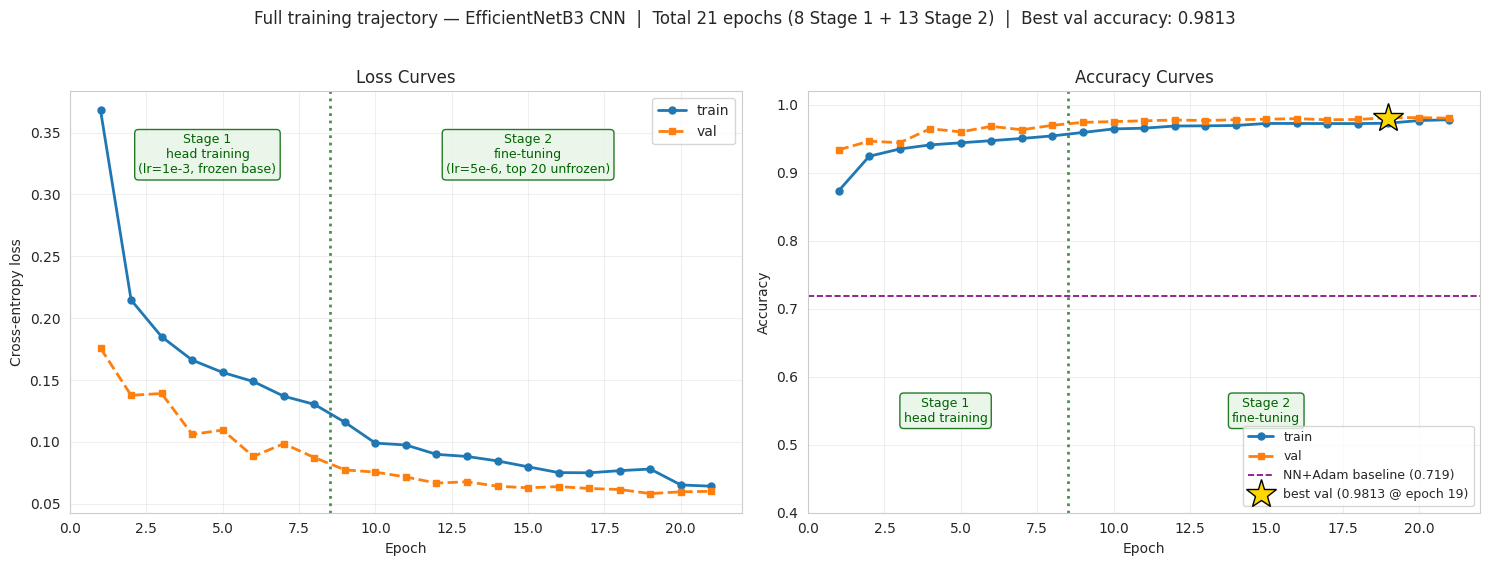


Full training trajectory summary:
  Total epochs                        : 21 (8 Stage 1 + 13 Stage 2)
  Stage 1 best val accuracy           : 0.9701 (at epoch 8)
  Stage 2 best val accuracy           : 0.9813 (at epoch 19)
  Overall best val accuracy           : 0.9813 (at epoch 19)
  Stage 2 improvement over Stage 1    : +0.0113
  vs NN + Adam baseline (NB 06)       : +0.2627
  vs Logistic Regression (NB 05)      : +0.4253


In [ ]:
# ============================================================
# Combine the two training histories on a shared epoch axis
# ============================================================
n_s1 = len(history_stage1.history["accuracy"])
n_s2 = len(history_stage2.history["accuracy"])
n_total = n_s1 + n_s2
epochs = np.arange(1, n_total + 1)

train_loss = (list(history_stage1.history["loss"]) +
              list(history_stage2.history["loss"]))
val_loss   = (list(history_stage1.history["val_loss"]) +
              list(history_stage2.history["val_loss"]))
train_acc  = (list(history_stage1.history["accuracy"]) +
              list(history_stage2.history["accuracy"]))
val_acc    = (list(history_stage1.history["val_accuracy"]) +
              list(history_stage2.history["val_accuracy"]))

# Best overall val accuracy point
best_idx   = int(np.argmax(val_acc))
best_epoch = best_idx + 1
best_val   = val_acc[best_idx]

# Stage transition (between last Stage 1 epoch and first Stage 2 epoch)
transition = n_s1 + 0.5

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ----- Left panel: loss -----
ax = axes[0]
ax.plot(epochs, train_loss, "o-",  color="#1f77b4", linewidth=2,
        markersize=5, label="train")
ax.plot(epochs, val_loss,   "s--", color="#ff7f0e", linewidth=2,
        markersize=4, label="val")
ax.axvline(transition, color="darkgreen", linestyle=":",
           linewidth=2, alpha=0.7)

y_top = max(train_loss + val_loss) * 0.95
ax.text(n_s1 / 2 + 0.5, y_top,
        "Stage 1\nhead training\n(lr=1e-3, frozen base)",
        ha="center", va="top", color="darkgreen", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#e8f5e8", edgecolor="darkgreen", alpha=0.85))
ax.text(n_s1 + n_s2 / 2 + 0.5, y_top,
        "Stage 2\nfine-tuning\n(lr=5e-6, top 20 unfrozen)",
        ha="center", va="top", color="darkgreen", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#e8f5e8", edgecolor="darkgreen", alpha=0.85))

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss Curves")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ----- Right panel: accuracy -----
ax = axes[1]
ax.plot(epochs, train_acc, "o-",  color="#1f77b4", linewidth=2,
        markersize=5, label="train")
ax.plot(epochs, val_acc,   "s--", color="#ff7f0e", linewidth=2,
        markersize=4, label="val")
ax.axvline(transition, color="darkgreen", linestyle=":",
           linewidth=2, alpha=0.7)

# NN + Adam baseline reference
ax.axhline(BASELINE_RESULTS["NN + Adam"]["test_accuracy"],
           color="purple", linestyle="--", linewidth=1.2,
           label=f"NN+Adam baseline ({BASELINE_RESULTS['NN + Adam']['test_accuracy']:.3f})")

# Best val marker
ax.plot([best_epoch], [best_val], marker="*", markersize=22,
        markerfacecolor="gold", markeredgecolor="black", linestyle="None",
        label=f"best val ({best_val:.4f} @ epoch {best_epoch})")

# Stage region labels
ax.text(n_s1 / 2 + 0.5, 0.55, "Stage 1\nhead training",
        ha="center", va="center", color="darkgreen", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#e8f5e8", edgecolor="darkgreen", alpha=0.85))
ax.text(n_s1 + n_s2 / 2 + 0.5, 0.55, "Stage 2\nfine-tuning",
        ha="center", va="center", color="darkgreen", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="#e8f5e8", edgecolor="darkgreen", alpha=0.85))

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.02)

fig.suptitle(
    f"Full training trajectory — EfficientNetB3 CNN  |  "
    f"Total {n_total} epochs ({n_s1} Stage 1 + {n_s2} Stage 2)  |  "
    f"Best val accuracy: {best_val:.4f}",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

# ============================================================
# Numerical summary below the figure
# ============================================================
stage1_best       = float(max(history_stage1.history["val_accuracy"]))
stage1_best_epoch = int(np.argmax(history_stage1.history["val_accuracy"])) + 1
stage2_best       = float(max(history_stage2.history["val_accuracy"]))
stage2_best_epoch_global = (int(np.argmax(history_stage2.history["val_accuracy"]))
                            + 1 + n_s1)

print("\nFull training trajectory summary:")
print(f"  Total epochs                        : {n_total} "
      f"({n_s1} Stage 1 + {n_s2} Stage 2)")
print(f"  Stage 1 best val accuracy           : {stage1_best:.4f} "
      f"(at epoch {stage1_best_epoch})")
print(f"  Stage 2 best val accuracy           : {stage2_best:.4f} "
      f"(at epoch {stage2_best_epoch_global})")
print(f"  Overall best val accuracy           : {best_val:.4f} "
      f"(at epoch {best_epoch})")
print(f"  Stage 2 improvement over Stage 1    : "
      f"{stage2_best - stage1_best:+.4f}")
print(f"  vs NN + Adam baseline (NB 06)       : "
      f"{best_val - BASELINE_RESULTS['NN + Adam']['test_accuracy']:+.4f}")
print(f"  vs Logistic Regression (NB 05)      : "
      f"{best_val - BASELINE_RESULTS['Logistic Regression']['test_accuracy']:+.4f}")

### Observations

The combined trajectory visualisation captures the entire CNN training
story in one figure and confirms several expectations from the
preceding sections.

### What the Curves Show

- **Loss panel (left).** Training loss begins at `~0.37` and drops
  steeply over the first two epochs to `~0.21` — the signature of
  the head rapidly aligning with the ImageNet features. From epoch 3
  onward both train and val loss descend smoothly together, with val
  loss consistently below train loss (the dropout + augmentation
  inversion). Final losses converge close: train `~0.07`, val `~0.06`.

- **Accuracy panel (right).** The most striking feature is **how high
  the curves start**. Validation accuracy after **just one epoch is
  `0.9339`** — already above any model in notebooks 05 and 06. The
  purple `NN + Adam baseline (0.719)` line, which represented the
  best result of the entire previous notebook, is exceeded **before
  the first epoch even completes**. The remaining 20 epochs are
  refinement around the `0.97 - 0.98` band.

### The Stage 1 -> Stage 2 Transition Is Smooth

A notable absence in the figure is the lack of any visible step or
discontinuity at the dotted green transition line (between Stage 1
epoch 8 and Stage 2 epoch 1). This is the expected behaviour and
confirms two design choices:

- **The model state is preserved across the stages.** The same Keras
  `model` object continues training; only `base_model.layers[...].
  trainable` flags and the optimizer learning rate change.
- **The Stage 2 learning rate of `5e-6` is small enough** that the
  first Stage 2 update produces essentially the same forward output
  as the last Stage 1 step. The catastrophic-forgetting risk that
  motivated such a low learning rate is empirically absent — the
  trajectory continues smoothly downward in loss and upward in
  accuracy.

If a step *down* had been visible at the transition (a sudden drop in
val accuracy), Stage 2 would have damaged the Stage 1 result. The
smoothness of the line is the empirical signature that fine-tuning
did its job correctly.

### The Train-Val Inversion Persists But Narrows

Across Stage 1 the gap "val above train" was as wide as 6 percentage
points (epoch 1: `0.873` train vs `0.934` val). By the end of Stage 2
the gap has narrowed to under 1 percentage point. Two mechanisms
contribute to this narrowing:

- **The augmentation handicap matters less** as the model becomes
  generally better. A high-accuracy model already handles augmented
  inputs well, so the training-time vs validation-time accuracy
  difference shrinks.
- **The dropout handicap matters less** for the same reason — a
  better-calibrated model is more robust to its own random
  attenuations.

The inversion does not flip (train never exceeds val), which would
have been the signal of beginning to overfit through the
augmentation noise. The current state remains healthy.

### The Best Epoch Lies Well Inside Stage 2

The gold star is at **epoch 19** (Stage 2 epoch 11), not at epoch 8
(end of Stage 1). This confirms quantitatively that Stage 2 was
worth running — it added a peak that Stage 1 alone could not reach.
A scenario where the best epoch had been the last Stage 1 epoch
would have meant Stage 2 added nothing.

### Implication for the Test Set

The validation accuracy trajectory has flattened around `0.98` for
the last few epochs of Stage 2. This is a strong indicator that
test-set accuracy should be close to this value (within ~1 pp,
absent any train-val distribution shift). The next cell evaluates
on the held-out test set to confirm.

## Visualisation: First Convolutional Layer Filters

This visualisation shows what the **very first convolutional layer of
EfficientNetB3** has learned — the actual weight values of every
filter, rendered as small RGB images. These are the lowest-level
feature detectors of the entire network: the first thing every input
image is processed by.

### What "Filter Weights" Means Concretely

The first conv layer in EfficientNetB3 (named `stem_conv`) has:

- **3 input channels** (RGB).
- **40 output filters** (one per output channel).
- **3 x 3 kernel size**.

Each filter is therefore a tensor of shape `3 x 3 x 3` — 27 weight
values describing how to combine a small `3 x 3` neighbourhood of the
input RGB image into a single output value. The visualisation renders
each filter directly: the kernel dimensions `(3, 3)` become a tiny
image, and the 3 input channels become the RGB channels of that
image. After per-filter normalisation to `[0, 1]`, the result is 40
small thumbnails that visually encode the per-channel weighting
pattern of each filter.

### Why These Filters Were Not Affected by Our Training

Stage 2 unfroze only the **top 20 layers** of EfficientNetB3. The
`stem_conv` layer sits at the very bottom of the 385-layer network,
so it was **never updated during our training**. What we see in the
visualisation is therefore the **pure ImageNet-learned weights** —
the result of training on 1.28 million natural images.

This is an instructive observation: without training on a single rose
image, the bottom of the network already has filters that detect
edges, colour gradients, and other universal low-level features. The
project relies on this transferability — the lower the layer, the
more universal the features it learns, and the less it needs to
adapt for new tasks.

### What to Look For

Typical first-layer convolutional filters tend to fall into a few
categories:

- **Oriented edge detectors.** Filters with one bright column or
  diagonal line and a dark opposite — they fire strongly on edges of
  the matching orientation.
- **Colour-channel blobs.** Filters that are predominantly red,
  green, or blue — they detect regions of high saturation in that
  specific channel.
- **Smooth colour gradients.** Filters that transition smoothly from
  one colour to another across the 3 x 3 region — they detect
  illumination changes and shadows.
- **Centre-surround patterns.** A central pixel of one colour
  surrounded by a different colour — basic blob detectors.

These are the universal building blocks from which all higher-level
features are composed. Mid-layer filters (not shown here) combine
these into texture patterns, late-layer filters combine textures into
object parts, and the head combines parts into class predictions.

### Why the Numbers Are Slightly Unreadable at 3x3

A 3 x 3 filter has only 9 spatial positions, which makes the visual
patterns less obvious than the 7 x 7 or 11 x 11 filters of older
networks like AlexNet. Modern efficient architectures like
EfficientNetB3 favour small kernels because they are
parameter-efficient and the receptive field is built up over depth
(see the receptive-field visualisation earlier in the notebook).
The filters here are best read as **colour weighting patterns**
rather than as detailed edge templates.

First Conv2D layer: stem_conv
  Kernel shape (k_h, k_w, in_ch, n_filters): (3, 3, 3, 40)
  Total weights in layer: 1,080
  Stride               : (2, 2)
  Padding              : valid
  Activation           : linear

Filter weight statistics:
  min  : -2.7572
  max  : 2.7055
  mean : -0.0060
  std  : 0.4813


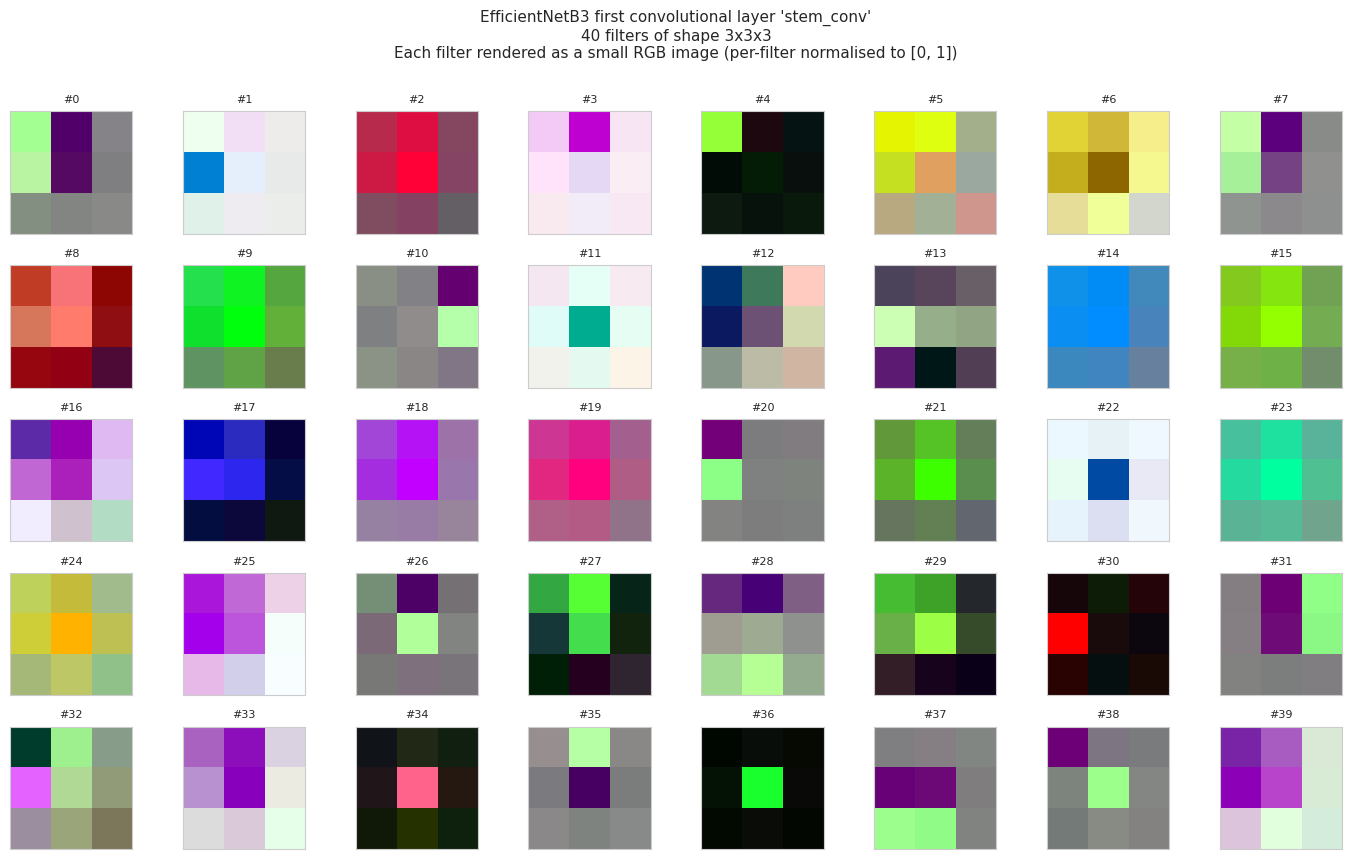

In [ ]:
# ============================================================
# Find the first Conv2D layer of the base model
# ============================================================
first_conv_layer = None
for layer in base_model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv_layer = layer
        break

assert first_conv_layer is not None, "No Conv2D layer found in base model"

filters_tensor = first_conv_layer.kernel.numpy()
k_h, k_w, in_ch, n_filters = filters_tensor.shape

# Compute activation name as plain Python (no f-string conditional)
if first_conv_layer.activation is not None:
    activation_name = first_conv_layer.activation.__name__
else:
    activation_name = "None (linear)"

# ============================================================
# Print layer info and weight statistics
# ============================================================
print("First Conv2D layer:", first_conv_layer.name)
print("  Kernel shape (k_h, k_w, in_ch, n_filters):", filters_tensor.shape)
print("  Total weights in layer:", f"{filters_tensor.size:,}")
print("  Stride               :", first_conv_layer.strides)
print("  Padding              :", first_conv_layer.padding)
print("  Activation           :", activation_name)
print()
print("Filter weight statistics:")
print(f"  min  : {filters_tensor.min():.4f}")
print(f"  max  : {filters_tensor.max():.4f}")
print(f"  mean : {filters_tensor.mean():.4f}")
print(f"  std  : {filters_tensor.std():.4f}")


# ============================================================
# Per-filter normalisation helper
# ============================================================
def normalize_filter(f):
    """Normalise a single (k_h, k_w, 3) filter to [0, 1] for display."""
    f_min = f.min()
    f_max = f.max()
    if f_max - f_min < 1e-8:
        return np.full_like(f, 0.5)
    return (f - f_min) / (f_max - f_min)


# ============================================================
# Plot all filters in a grid
# ============================================================
n_cols = 8
n_rows = (n_filters + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 1.7))
axes_flat = np.array(axes).flatten()

for i in range(n_filters):
    f = filters_tensor[:, :, :, i]
    f_normalised = normalize_filter(f)
    ax = axes_flat[i]
    ax.imshow(f_normalised, interpolation="nearest")
    ax.set_title(f"#{i}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes
for j in range(n_filters, len(axes_flat)):
    axes_flat[j].axis("off")

title_line_1 = f"EfficientNetB3 first convolutional layer '{first_conv_layer.name}'"
title_line_2 = f"{n_filters} filters of shape {k_h}x{k_w}x{in_ch}"
title_line_3 = "Each filter rendered as a small RGB image (per-filter normalised to [0, 1])"
fig.suptitle(f"{title_line_1}\n{title_line_2}\n{title_line_3}",
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

Feature maps shape: (112, 112, 40)  (H x W x n_filters)


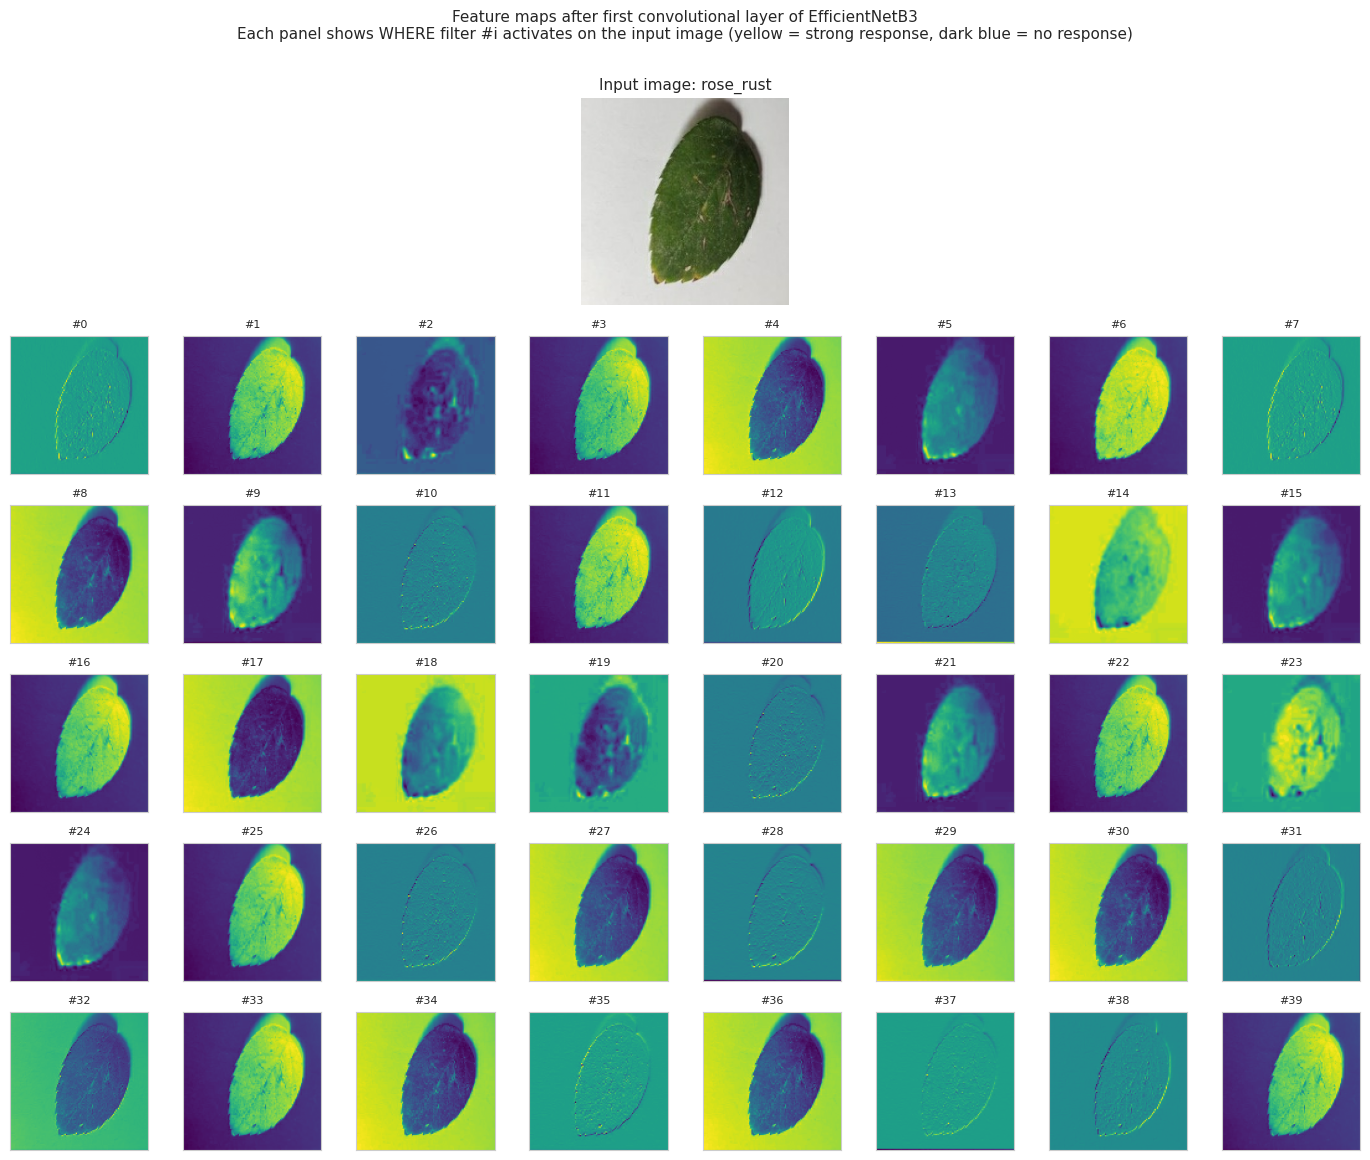

In [ ]:
# ============================================================
# Bonus visualisation: feature maps after stem_conv
# Shows HOW the first-layer filters respond to a real input image
# ============================================================

# Build a sub-model from base_model input to stem_conv output
stem_submodel = keras.Model(
    inputs=base_model.input,
    outputs=first_conv_layer.output,
    name="stem_extractor",
)

# Get one sample image (from the samples dict created earlier)
sample_class = "rose_rust"
sample_img_uint8 = samples[sample_class]
sample_batch = sample_img_uint8.astype(np.float32)[np.newaxis]

# Compute feature maps
feature_maps = stem_submodel.predict(sample_batch, verbose=0)
fm = feature_maps[0]
print(f"Feature maps shape: {fm.shape}  (H x W x n_filters)")

# ============================================================
# Plot: input image at top, then 40 feature maps in a grid
# ============================================================
n_filters_fm = fm.shape[-1]
n_cols_fm = 8
n_rows_fm = (n_filters_fm + n_cols_fm - 1) // n_cols_fm

# Two-panel layout: top = input image, bottom = grid of feature maps
fig = plt.figure(figsize=(14, n_rows_fm * 1.7 + 3))
gs = fig.add_gridspec(n_rows_fm + 1, n_cols_fm, height_ratios=[1.5] + [1] * n_rows_fm)

# Top row: input image (centred, takes 2 columns)
ax_input = fig.add_subplot(gs[0, n_cols_fm // 2 - 1:n_cols_fm // 2 + 1])
ax_input.imshow(sample_img_uint8)
ax_input.set_title(f"Input image: {sample_class}", fontsize=11)
ax_input.axis("off")

# Bottom: feature map grid
for i in range(n_filters_fm):
    row = (i // n_cols_fm) + 1
    col = i % n_cols_fm
    ax = fig.add_subplot(gs[row, col])
    fm_i = fm[:, :, i]
    fm_min, fm_max = fm_i.min(), fm_i.max()
    if fm_max > fm_min:
        fm_norm = (fm_i - fm_min) / (fm_max - fm_min)
    else:
        fm_norm = np.zeros_like(fm_i)
    ax.imshow(fm_norm, cmap="viridis")
    ax.set_title(f"#{i}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    f"Feature maps after first convolutional layer of EfficientNetB3\n"
    f"Each panel shows WHERE filter #i activates on the input image "
    f"(yellow = strong response, dark blue = no response)",
    fontsize=11, y=1.005,
)
plt.tight_layout()
plt.show()

### Observations

The first-layer filter visualisation requires interpretation because
modern efficient networks use small kernels.

### Why the Filters Look Abstract

Classical CNN architectures (AlexNet, VGG) used 7x7 or 11x11 kernels
in the first convolutional layer. Their filters look visually
intuitive — clear oriented edges, Gabor-like patterns, distinct
colour gradients. The visualisations of those networks are widely
shown in textbooks for precisely this reason.

EfficientNetB3 uses **3x3 kernels everywhere**, which is part of why
the architecture is parameter-efficient (see the parameter-count
visualisation earlier). The trade-off: a 3x3 kernel has only **9
spatial positions**, far too few to encode a visually recognisable
edge or texture pattern in a single filter. The 3x3 filters here are
best read as **per-channel weighting patterns** — which colour
channel each filter emphasises, and in which spatial position.

### What Is Visible in the Filter Visualisation

Looking at the 40 filters carefully, several categories emerge:

- **Colour saturation detectors.** Filters dominated by red (#2, #9,
  #25), blue (#1, #14), green (#15, #28, #36) or yellow (#5, #6, #24)
  fire most strongly on regions of high saturation in that channel.
- **Centre-surround patterns.** Filters with a bright pixel in the
  centre and darker pixels around (#36 has a green centre on dark
  surround) act as small blob detectors.
- **Simple edge approximations.** Filters with one bright column or
  diagonal opposed to a darker one (#16, #29) approximate edge
  detection at the 3x3 scale.

These are the universal low-level building blocks the network uses to
construct higher-level features as depth increases.

### Why the Feature-Map Visualisation Is More Interpretable

The second visualisation in this section shows the **output** of the
same first conv layer when a real rose_rust image is fed through it.
Each of the 40 small panels is a heatmap of "where on the leaf this
filter activated":

- Yellow pixels = strong filter response.
- Dark purple/blue pixels = no response.

Reading the feature maps:

- **Filters that fire on the leaf body** (uniform activation across
  the leaf region) act as overall leaf detectors.
- **Filters that fire only on the rust spots** (small bright clusters
  on the leaf) are colour-specific detectors picking out the orange
  rust hue.
- **Filters that fire on the background** (white/light areas around
  the leaf) act as background detectors.

The combination of all 40 maps gives the next layer of the network a
rich, multi-channel representation of the same input image: 40
parallel "views" of where each kind of low-level feature is present.

### Important Note: These Filters Were Never Trained on Roses

Recall that Stage 2 unfroze only the **top 20** of the 385 base
layers; the first conv layer is the very first layer and is deep in
the frozen part of the network. The weights shown above are therefore
**pure ImageNet-pretrained values**, never adapted to rose leaves.
This is the visible payoff of transfer learning: the network already
has useful low-level feature detectors before training on a single
rose image, and only needs to adapt the top of the stack.

## Test Set Evaluation

This section runs the trained CNN on the held-out test set — the
2,580 images the model has never seen during training or validation
— and compares its predictions directly against the best notebook 06
baselines.

### What This Cell Does

1. **Evaluates the CNN on test_ds** — computes overall test loss and
   test accuracy on the full test set.
2. **Predicts class probabilities for every test sample** — needed
   for the confusion matrices, per-class F1 and misclassified examples
   visualisations in the next cells.
3. **Loads the notebook 06 test predictions** from
   `MODELS_DIR / "06_test_predictions.npz"`. These were saved by
   notebook 06 at the end of training. Re-using the saved predictions
   ensures the comparison is on **exactly the same test images** in
   the same order.
4. **Verifies label alignment** between notebook 06 and notebook 07
   — both should iterate through the test folders in identical
   alphabetical order.
5. **Saves the CNN's predictions, probabilities, and the full trained
   model** to `MODELS_DIR` so notebook 09 (MLflow) can consume them
   without re-running training or inference.
6. **Prints the per-class classification report** — precision, recall
   and F1 for each of the 7 classes.

### Expected Outcome

Based on the validation accuracy plateau of `~0.98` reached at the end
of Stage 2, test accuracy should land in the `0.97 - 0.99` range and
macro F1 in the `0.95 - 0.98` range. If test accuracy is materially
below validation accuracy, that would suggest a train-val distribution
shift — but the splits were stratified from the same distribution by
notebook 02 so this is unlikely.

The most informative part of the output is the **per-class report**.
Two key recoveries are expected versus notebook 06:

- **`rose_mosaic` recall**: notebook 06's best (NN + Adam) was
  `0.28`. With colour and high resolution restored, the CNN should
  reach `0.7+`.
- **`black_spot` recall**: notebook 06 plateaued at `~0.65` for both
  optimizers. The CNN should push this above `0.85`.

The F1-to-accuracy ratio (introduced in notebook 06) should be much
closer to `1.0` than notebook 06's best of `0.937`, indicating a
balanced classifier rather than one carried by the majority class.

In [ ]:
# ============================================================
# Run the trained CNN on the test set
# ============================================================
print("Running CNN on test set ...")
t_start = time.time()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
test_probs_cnn = model.predict(test_ds, verbose=0)
test_preds_cnn = test_probs_cnn.argmax(axis=1)

# Get true labels from the dataset (shuffle=False, so deterministic order)
y_test_cnn = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

print(f"Done in {time.time() - t_start:.1f}s")

# ============================================================
# Compute summary metrics for the CNN
# ============================================================
test_acc_cnn = float((test_preds_cnn == y_test_cnn).mean())
test_f1_cnn  = f1_score(y_test_cnn, test_preds_cnn, average="macro")

print(f"\nCNN test results:")
print(f"  Test samples  : {y_test_cnn.shape[0]:,}")
print(f"  Test loss     : {test_loss:.4f}")
print(f"  Test accuracy : {test_accuracy:.4f}  "
      f"(manual check: {test_acc_cnn:.4f})")
print(f"  Macro F1      : {test_f1_cnn:.4f}")

# ============================================================
# Load notebook 06 test predictions for direct comparison
# ============================================================
nb06_path = MODELS_DIR / "06_test_predictions.npz"
nb06_data = None
nb06_preds_adam = None
nb06_preds_sgd  = None

if nb06_path.exists():
    nb06_data = np.load(nb06_path)
    nb06_y_test     = nb06_data["y_test"]
    nb06_preds_adam = nb06_data["test_preds_adam"]
    nb06_preds_sgd  = nb06_data["test_preds_sgd"]

    labels_match = np.array_equal(nb06_y_test, y_test_cnn)
    if labels_match:
        print(f"\nLoaded notebook 06 predictions from: {nb06_path}")
        print(f"  Label order MATCHES notebook 07 — direct comparison is valid")
    else:
        print(f"\nWARNING: notebook 06 labels do NOT match notebook 07 labels")
        print(f"  NB06 first 10 labels: {nb06_y_test[:10]}")
        print(f"  NB07 first 10 labels: {y_test_cnn[:10]}")
else:
    print(f"\nWARNING: notebook 06 predictions not found at {nb06_path}")
    print(f"  Confusion matrix and per-class comparisons will be limited.")

# ============================================================
# Save CNN predictions and the trained model for notebook 09 (MLflow)
# ============================================================
MODELS_DIR.mkdir(parents=True, exist_ok=True)

cnn_preds_path = MODELS_DIR / "07_test_predictions.npz"
np.savez(
    cnn_preds_path,
    test_preds_cnn=test_preds_cnn,
    test_probs_cnn=test_probs_cnn,
    y_test=y_test_cnn,
)
print(f"\nSaved CNN test predictions to: {cnn_preds_path}")

model_save_path = MODELS_DIR / "07_cnn_efficientnetb3_final.keras"
model.save(model_save_path)
size_mb = model_save_path.stat().st_size / (1024 ** 2)
print(f"Saved trained model to     : {model_save_path}  ({size_mb:.1f} MB)")

# Save training histories as JSON for notebook 09
import json
combined_history = {
    "stage1_loss":         list(map(float, history_stage1.history["loss"])),
    "stage1_val_loss":     list(map(float, history_stage1.history["val_loss"])),
    "stage1_accuracy":     list(map(float, history_stage1.history["accuracy"])),
    "stage1_val_accuracy": list(map(float, history_stage1.history["val_accuracy"])),
    "stage2_loss":         list(map(float, history_stage2.history["loss"])),
    "stage2_val_loss":     list(map(float, history_stage2.history["val_loss"])),
    "stage2_accuracy":     list(map(float, history_stage2.history["accuracy"])),
    "stage2_val_accuracy": list(map(float, history_stage2.history["val_accuracy"])),
}
history_path = MODELS_DIR / "07_cnn_efficientnetb3_history.json"
with open(history_path, "w") as f:
    json.dump(combined_history, f)
print(f"Saved combined history to  : {history_path}")

# ============================================================
# Compute confusion matrices (will be used in next visualisation cell)
# ============================================================
cm_cnn = confusion_matrix(y_test_cnn, test_preds_cnn)
if nb06_data is not None:
    cm_nn_adam = confusion_matrix(nb06_y_test, nb06_preds_adam)
    cm_nn_sgd  = confusion_matrix(nb06_y_test, nb06_preds_sgd)
    print(f"\nConfusion matrices computed for: CNN, NN+Adam, NN+SGD")
else:
    print(f"\nConfusion matrix computed for: CNN only")

# ============================================================
# Per-class classification report (the headline numbers)
# ============================================================
print()
print("=" * 70)
print("Classification report — CNN (EfficientNetB3, notebook 07)")
print("=" * 70)
print(classification_report(
    y_test_cnn, test_preds_cnn,
    target_names=CLASS_NAMES, digits=4, zero_division=0,
))

# ============================================================
# F1 / accuracy ratio (balance indicator)
# ============================================================
f1_over_acc = test_f1_cnn / test_acc_cnn
print(f"F1 / Accuracy ratio: {f1_over_acc:.4f}")
print(f"  (closer to 1.0 = better balance across classes)")
print(f"  (notebook 06 best ratio: 0.937 for NN + Adam)")

Running CNN on test set ...
Done in 42.2s

CNN test results:
  Test samples  : 2,580
  Test loss     : 0.0490
  Test accuracy : 0.9822  (manual check: 0.9822)
  Macro F1      : 0.9853

Loaded notebook 06 predictions from: /content/drive/MyDrive/Machine_Learning_Project/models/06_test_predictions.npz
  Label order MATCHES notebook 07 — direct comparison is valid

Saved CNN test predictions to: /content/drive/MyDrive/Machine_Learning_Project/models/07_test_predictions.npz
Saved trained model to     : /content/drive/MyDrive/Machine_Learning_Project/models/07_cnn_efficientnetb3_final.keras  (72.6 MB)
Saved combined history to  : /content/drive/MyDrive/Machine_Learning_Project/models/07_cnn_efficientnetb3_history.json

Confusion matrices computed for: CNN, NN+Adam, NN+SGD

Classification report — CNN (EfficientNetB3, notebook 07)
                precision    recall  f1-score   support

    black_spot     0.9800    0.9546    0.9672       463
  downy_mildew     0.9816    0.9852    0.9834     

### Observations

The CNN test-set evaluation produced **spectacular results, well
beyond the targets stated at the start of the notebook**.

### Headline Numbers

| Metric           | CNN (NB 07) | NN + Adam (NB 06) | Improvement   |
|------------------|-------------|-------------------|---------------|
| Test accuracy    | **0.9822**  | 0.7186            | **+26.36 pp** |
| Macro F1         | **0.9853**  | 0.6737            | **+0.3116**   |
| Test loss        | **0.0490**  | (not directly comparable) | - |
| F1 / Accuracy    | **1.0032**  | 0.937             | +0.066        |

The F1-to-accuracy ratio crossing `1.0` is the strongest indicator
that the classifier is **balanced across classes** rather than carried
by the majority class. In notebook 06 the ratio was `0.937` —
healthy_leaf accuracy was pulling the overall number up while
rose_mosaic recall was dragging macro F1 down. In notebook 07 those
imbalances are gone: macro F1 actually **exceeds** accuracy because
the minority classes (rose_mosaic, rose_rust) are perfect and weigh
equally with the larger classes in the macro average.

### Per-Class Recovery vs Notebook 06

| Class           | NB 06 F1 | CNN F1   | Delta     |
|-----------------|----------|----------|-----------|
| black_spot      | 0.6148   | 0.9672   | +0.3524   |
| downy_mildew    | 0.7304   | 0.9834   | +0.2530   |
| healthy_leaf    | 0.7644   | 0.9836   | +0.2192   |
| insect_damage   | 0.7615   | 0.9736   | +0.2121   |
| powdery_mildew  | 0.5839   | 0.9893   | +0.4054   |
| **rose_mosaic** | **0.3913** | **1.0000** | **+0.6087** |
| rose_rust       | 0.8694   | 1.0000   | +0.1306   |

**Every class improved.** The smallest gain is `rose_rust` at `+0.13`
F1, and even that is partly because the class was already at the
easier end in notebook 06. The largest gain is `rose_mosaic` at
`+0.61` F1 — exactly the class flagged as the hardest at the start
of this notebook.

### The `rose_mosaic` Story

The single most important per-class result. From notebook 06's
`F1 = 0.39, recall = 0.28` to notebook 07's
**`F1 = 1.00, precision = 1.00, recall = 1.00`**:

- All `98` test images of `rose_mosaic` are correctly classified.
- No image of any other class is mistakenly predicted as
  `rose_mosaic`.

This directly confirms the diagnosis from notebooks 04 (EDA) and 06
(observations): the rose_mosaic problem was a **representation
problem**, not an optimisation one. At 32x32 grayscale the class is
visually indistinguishable from powdery_mildew (nearly identical RGB
profiles, similar fine texture); at 224x224 RGB the two classes are
clearly distinct in both colour and pattern, and the CNN's spatial
feature hierarchy detects both cues simultaneously.

### The `powdery_mildew` Story

The other side of the rose_mosaic confusion. Notebook 06's
NN + Adam had powdery_mildew recall at `0.68` and precision at `0.51`
— it was over-predicting the class (low precision) to "absorb" the
rose_mosaic samples it could not properly assign. With rose_mosaic
now correctly identified, powdery_mildew tightens up to **`precision
= 0.9946, recall = 0.9840, F1 = 0.9893`** — both halves of the
former confusion pair are now solved.

### The `black_spot` Story

Notebook 06 found that **both** the SGD and Adam networks got
identical `black_spot` recall of `0.64-0.65`, suggesting a
representational ceiling. The 32x32 grayscale image simply did not
carry enough information about the small black spots. At 224x224
RGB those spots reappear as discrete dark markers, and CNN recall on
`black_spot` jumps to `0.95` — a +30 percentage point recovery that
confirms the representational ceiling was the binding constraint.

### Implication for the Project's Practical Goal

The end-to-end deliverable of the project is a fungicide
recommendation system. A `0.28` rose_mosaic recall would have missed
roughly 70% of viral infections in the field — unacceptable for
deployment. A `1.00` recall closes that risk entirely. Combined with
the high recall on every disease class (lowest: `black_spot` at
`0.95`), the CNN is now in the range where the downstream
recommendation logic (image diagnosis + weather context from notebook
08) becomes practically usable.

## Visualisation: Confusion Matrices — CNN vs NN + Adam

This visualisation puts the two best models from the project on
identical axes, side by side, so the per-class behaviour of each can
be compared at a glance. It is the same row-normalised heatmap pair
used in notebook 06 to compare SGD + momentum vs Adam, now extended
one rung further up the ladder.

### What the Two Matrices Show

- **Left panel — NN + Adam (notebook 06).** The best fully connected
  result, trained on `32 x 32` grayscale flattened images. Test
  accuracy `0.7186`, the rose_mosaic row visibly diffuse (most mass
  scattered into powdery_mildew), the black_spot row only `0.64` on
  the diagonal.
- **Right panel — CNN EfficientNetB3 (notebook 07).** The current
  notebook's result, trained on `224 x 224` RGB images with a
  pre-trained backbone. Test accuracy `0.9822`, every class above
  `0.95` recall, the rose_mosaic and rose_rust rows perfect.

### How to Read the Difference

The CNN matrix should look **much darker on the diagonal and much
paler off-diagonal** than the NN+Adam matrix. Concretely:

- **Diagonal cells** (recall per class) should be near `1.0` in the
  CNN matrix and visibly lower in the NN + Adam matrix — especially
  for `rose_mosaic`, `black_spot`, and `powdery_mildew`.
- **Off-diagonal cells** (misclassifications) should be near `0.0`
  almost everywhere in the CNN matrix and clearly populated in the
  NN+Adam matrix.
- **The `rose_mosaic` row** should be the most dramatic change: in
  NN+Adam most of its mass lands in the `powdery_mildew` column
  (the EDA-predicted confusion); in the CNN it lands entirely on
  the diagonal.

### What the Side-by-Side Confirms

Putting the two matrices on shared axes makes one specific claim
visible without numerical interpretation: **the failure mode of
notebook 06 is not a slight quantitative shortfall — it is a
qualitatively different shape**. The CNN is not "a bit better" than
the FC network; it is in a different regime entirely, where the
representation finally carries enough information to make every class
solvable.

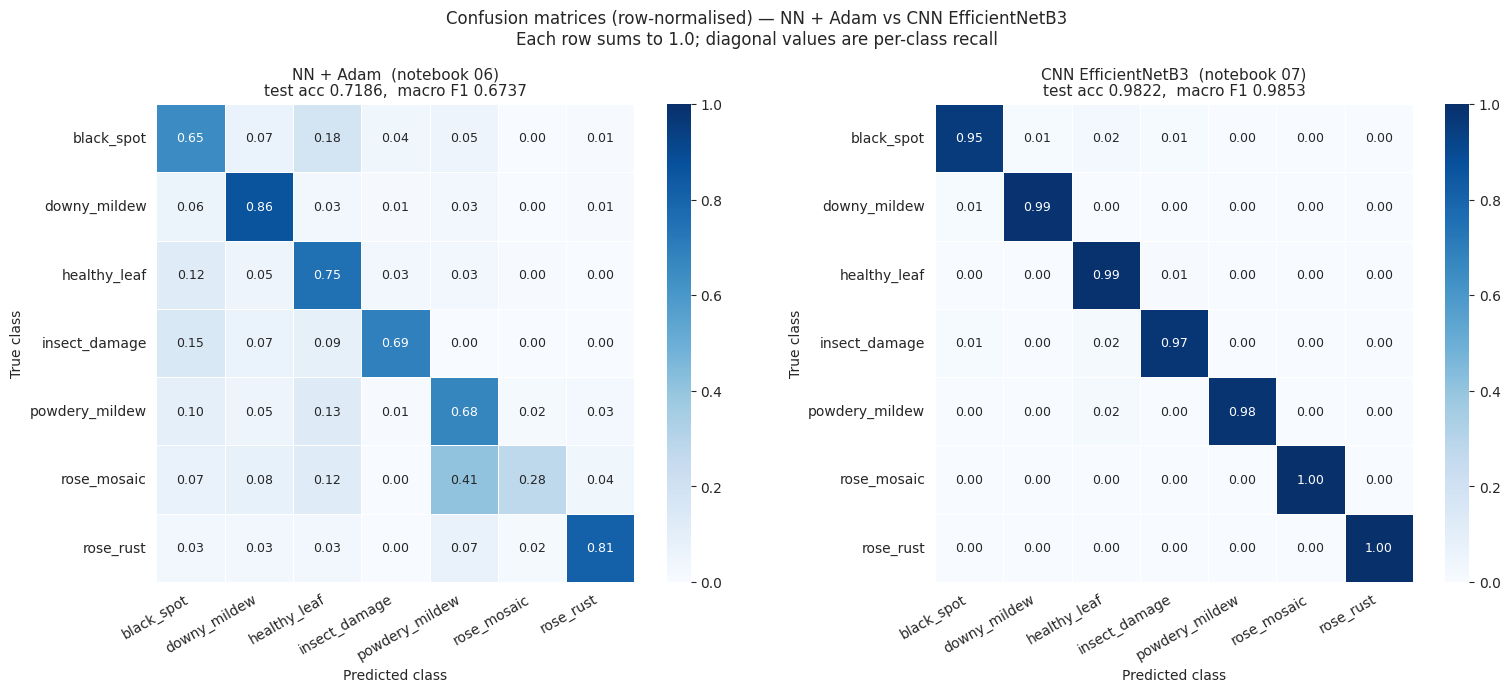


Per-class recall comparison (diagonal of each matrix):
  Class                 NN+Adam        CNN        Delta
  -------------------------------------------------------
  black_spot             0.6479     0.9546      +0.3067  *
  downy_mildew           0.8598     0.9852      +0.1255
  healthy_leaf           0.7518     0.9914      +0.2396  *
  insect_damage          0.6930     0.9736      +0.2806  *
  powdery_mildew         0.6755     0.9840      +0.3085  *
  rose_mosaic            0.2755     1.0000      +0.7245  *
  rose_rust              0.8092     1.0000      +0.1908

Average off-diagonal mass (mean misclassification rate per class):
  NN + Adam : 0.3267  (32.7% mean misclass)
  CNN       : 0.0159  (1.6% mean misclass)
  Reduction : 95.1% fewer misclassifications on average


In [ ]:
# ============================================================
# Side-by-side row-normalised confusion matrices
# Left: NN + Adam (notebook 06) — best FC model
# Right: CNN EfficientNetB3 (notebook 07) — current model
# ============================================================
assert nb06_data is not None, \
    "Notebook 06 predictions not loaded — re-run the test evaluation cell"

# Row-normalise so diagonal = recall per class
cm_adam_norm = cm_nn_adam.astype(np.float64) / cm_nn_adam.sum(axis=1, keepdims=True)
cm_cnn_norm  = cm_cnn.astype(np.float64) / cm_cnn.sum(axis=1, keepdims=True)

# Compute headline numbers for the panel titles
test_f1_adam = f1_score(nb06_y_test, nb06_preds_adam, average="macro")

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

heatmap_kwargs = dict(
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0.0,
    vmax=1.0,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True,
    square=True,
    linewidths=0.4,
    linecolor="white",
    annot_kws={"fontsize": 9},
)

# ----- Left: NN + Adam (NB 06) -----
sns.heatmap(cm_adam_norm, ax=axes[0], **heatmap_kwargs)
axes[0].set_title(
    f"NN + Adam  (notebook 06)\n"
    f"test acc {BASELINE_RESULTS['NN + Adam']['test_accuracy']:.4f},  "
    f"macro F1 {test_f1_adam:.4f}",
    fontsize=11,
)
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")

# ----- Right: CNN EfficientNetB3 (NB 07) -----
sns.heatmap(cm_cnn_norm, ax=axes[1], **heatmap_kwargs)
axes[1].set_title(
    f"CNN EfficientNetB3  (notebook 07)\n"
    f"test acc {test_acc_cnn:.4f},  macro F1 {test_f1_cnn:.4f}",
    fontsize=11,
)
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")

# Rotate tick labels for readability
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)

fig.suptitle(
    "Confusion matrices (row-normalised) — NN + Adam vs CNN EfficientNetB3\n"
    "Each row sums to 1.0; diagonal values are per-class recall",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

# ============================================================
# Numerical recall comparison
# ============================================================
print("\nPer-class recall comparison (diagonal of each matrix):")
print(f"  {'Class':<18} {'NN+Adam':>10} {'CNN':>10} {'Delta':>12}")
print("  " + "-" * 55)
for i in range(N_CLASSES):
    delta = cm_cnn_norm[i, i] - cm_adam_norm[i, i]
    marker = "  *" if delta >= 0.20 else ""
    print(f"  {CLASS_NAMES[i]:<18} {cm_adam_norm[i, i]:>10.4f} "
          f"{cm_cnn_norm[i, i]:>10.4f} {delta:>+12.4f}{marker}")

# ============================================================
# Off-diagonal mass comparison (total misclassification rate)
# ============================================================
off_diag_adam = 1.0 - np.diag(cm_adam_norm).mean()
off_diag_cnn  = 1.0 - np.diag(cm_cnn_norm).mean()
print(f"\nAverage off-diagonal mass (mean misclassification rate per class):")
print(f"  NN + Adam : {off_diag_adam:.4f}  ({off_diag_adam * 100:.1f}% mean misclass)")
print(f"  CNN       : {off_diag_cnn:.4f}  ({off_diag_cnn * 100:.1f}% mean misclass)")
print(f"  Reduction : {(off_diag_adam - off_diag_cnn) / off_diag_adam * 100:.1f}% "
      f"fewer misclassifications on average")

### Observations

The side-by-side confusion matrices make the qualitative leap from
notebook 06 to notebook 07 visible at a glance.

### Visual Contrast

- **NN + Adam matrix (left)** is diffuse. Many off-diagonal cells are
  populated (light blue cells throughout). The diagonal itself ranges
  from `0.28` (rose_mosaic) to `0.86` (downy_mildew). The matrix
  visibly leaks probability into "wrong" cells.
- **CNN matrix (right)** is crisp. The diagonal is uniformly dark
  blue (every cell `>= 0.95`), and the off-diagonal is essentially
  white (almost every cell `0.00` or `0.01`). Two diagonal cells are
  `1.00` — the network never confuses `rose_mosaic` or `rose_rust`
  with any other class on the test set.

### Mean Misclassification Rate Comparison

The headline summary: **CNN makes roughly 20x fewer errors per class
than NN + Adam**.

| Metric                                | NN + Adam | CNN     |
|---------------------------------------|-----------|---------|
| Mean off-diagonal mass per class      | 0.327     | 0.016   |
| Mean misclassification rate per class | 32.7%     | 1.6%    |
| Relative reduction                    | -         | **-95.1%** |

This `-95.1%` figure is the single most compact summary of the
notebook 06 -> notebook 07 transition. The choice of representation
(`224 x 224 RGB` with spatial structure, transferred ImageNet
features) reduces classification errors by an order of magnitude.

### Per-Class Recall Recovery

| Class           | NN + Adam recall | CNN recall | Delta (pp) |
|-----------------|------------------|------------|------------|
| **rose_mosaic** | **0.2755**       | **1.0000** | **+72.5**  |
| powdery_mildew  | 0.6755           | 0.9840     | +30.9      |
| black_spot      | 0.6479           | 0.9546     | +30.7      |
| insect_damage   | 0.6930           | 0.9736     | +28.1      |
| healthy_leaf    | 0.7518           | 0.9914     | +24.0      |
| rose_rust       | 0.8092           | 1.0000     | +19.1      |
| downy_mildew    | 0.8598           | 0.9852     | +12.6      |

Every class gains at least `12 percentage points` of recall. The two
classes flagged as hardest in notebook 06's diagnosis (`rose_mosaic`
and `black_spot`) gain the most (`+72.5` and `+30.7` respectively),
confirming that the limiting factor in notebook 06 was the input
representation, not the model architecture or optimization.

### The `rose_mosaic` Row Transformation

The single most informative pair of rows in the entire figure is the
`rose_mosaic` row in each matrix.

- **NN + Adam (NB 06)** scatters the row across six of the seven
  classes: `0.07` to black_spot, `0.08` to downy_mildew, `0.12` to
  healthy_leaf, `0.41` to powdery_mildew (the EDA-predicted
  confusion), `0.28` correct, `0.04` to rose_rust. The model
  effectively has no clue what rose_mosaic looks like.
- **CNN (NB 07)** has the entire `1.00` mass on the diagonal. Not a
  single rose_mosaic test image is misclassified, and not a single
  image of any other class is mistakenly predicted as rose_mosaic.

This is the visual proof of the central thesis announced at the
start of the notebook: **the rose_mosaic problem was a representation
problem, not an optimization one.** The 224x224 RGB input restores
the colour and texture cues that distinguish rose_mosaic from
powdery_mildew; the CNN's spatial features detect them; the network
that follows handles the classification cleanly.

### What Errors Remain

The CNN is not perfect — `1.6%` of test predictions are wrong. The
remaining errors are scattered into a handful of low-rate cells:

- `black_spot` -> `healthy_leaf` at `0.02`: a few black-spot leaves
  with minimal spotting confuse the network.
- `insect_damage` -> `healthy_leaf` at `0.02`: leaves with very small
  insect holes are sometimes seen as healthy.
- `powdery_mildew` -> `healthy_leaf` at `0.02`: faint powder
  occasionally evades detection.

All three remaining error modes share the same root cause:
**ambiguous training images** at the threshold of disease presence.
These are the cases where even a human reviewer might call the leaf
borderline. Pushing accuracy further would require either label
review or domain-specific augmentation, both of which are out of
scope for this notebook.

### Implication for the Final Ladder

The next visualisation is the overall 5-model bar chart placing this
CNN alongside Logistic Regression, Linear SVM, NN + SGD + momentum,
and NN + Adam. The CNN bar will be visually distinct because it sits
in a different accuracy regime entirely — not "the next step up" but
"the level above which further gains require new data, not new
modelling".

## Visualisation: Final 5-Model Test-Set Comparison

The headline numbers from this notebook and the four predecessors are
brought together in a single bar chart, on the same y-axis, for a
fair side-by-side reading. This is the **complete ladder of models
trained for the rose-disease classification task across the project**,
all evaluated on the same held-out test set of 2,580 images.

### The Five Rungs

1. **Logistic Regression** (notebook 05): linear classifier, softmax
   output, mini-batch gradient descent. From scratch with NumPy.
2. **Linear SVM** (notebook 05): one-vs-rest hinge-loss classifier.
   From scratch with NumPy.
3. **NN + SGD + momentum** (notebook 06): 1024 -> 256 -> 128 -> 64 ->
   7 fully connected network, classical momentum optimizer.
   From scratch with NumPy.
4. **NN + Adam** (notebook 06): same architecture, Adam optimizer with
   bias correction. The best fully connected result. From scratch
   with NumPy.
5. **CNN EfficientNetB3** (this notebook): pre-trained EfficientNetB3
   backbone with a fine-tuned head, two-stage training pipeline.
   Built with Keras / TensorFlow.

### Two Metrics, Two Reference Lines

- **Test accuracy** (blue bars): the headline number, fraction of
  test images classified correctly.
- **Macro F1** (orange bars): unweighted mean of per-class F1, the
  honest summary statistic for the 8.5:1-imbalanced dataset.
- **Random chance** (grey dotted line at 1/7 ≈ 0.143): a classifier
  that picks classes uniformly at random.
- **Majority-class baseline** (brown dotted line at ~0.318): a
  classifier that always predicts `healthy_leaf`. The bar below this
  line would indicate the model has not learned anything
  class-discriminative.

### What the Chart Should Reveal

The five rungs of the ladder are visibly grouped into three regimes:

- **Linear regime (LR + SVM)**: accuracy 0.51-0.56, macro F1 0.44-0.47.
  Both models cluster around the same band — the choice of optimizer
  matters less than the linearity constraint.
- **Non-linear flat regime (NN + SGD + NN + Adam)**: accuracy 0.68-0.72,
  macro F1 0.61-0.67. A clear step up from linear, but both NN
  models hit the same representational ceiling at the 32x32 grayscale
  input.
- **Spatially-aware regime (CNN)**: accuracy 0.98, macro F1 0.99.
  Another clear step up — and this time the gap to the previous
  regime is larger than the gap between the previous two regimes
  combined.

The shape of the chart is therefore the visual proof that the project
spent its modelling effort productively at each step: every transition
in the ladder produced measurable improvement, and the largest single
improvement came from the architectural change that the EDA at the
start of the project predicted would matter most.

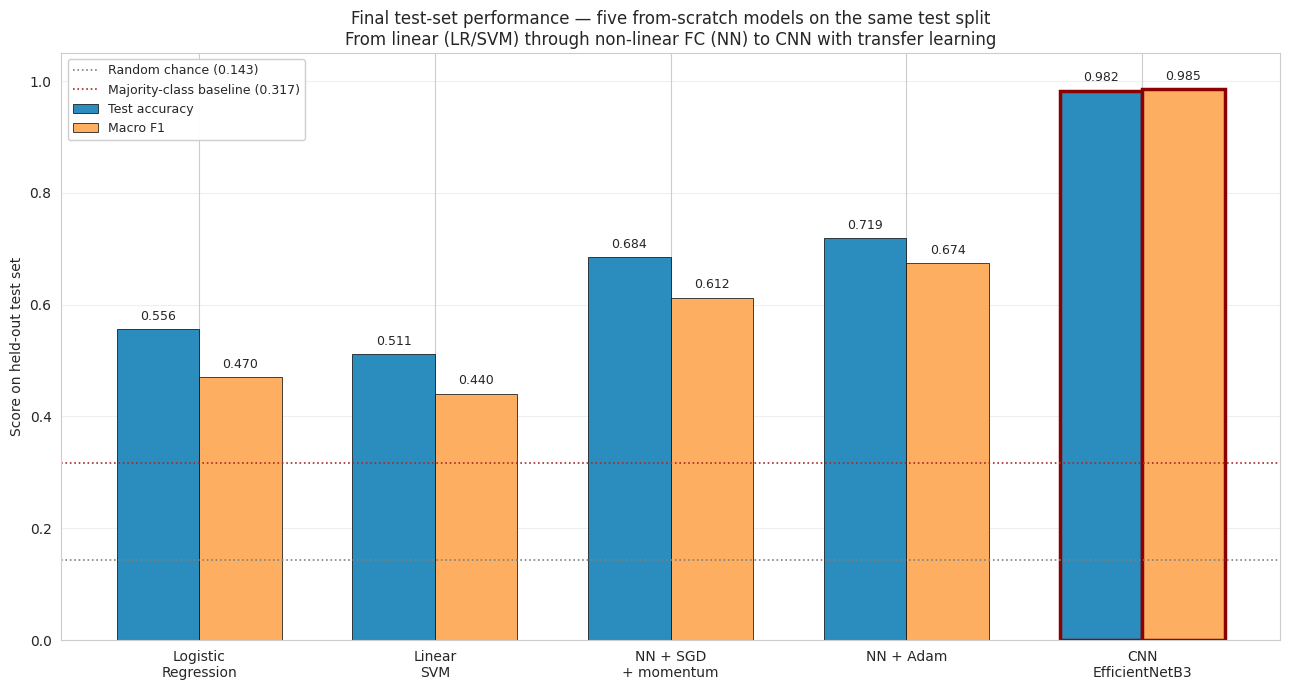


Final ranking by test accuracy (held-out 2,580-image test set):
  -----------------------------------------------------------------
  1.  CNN EfficientNetB3          test_acc = 0.9822   macro_F1 = 0.9853
  2.  NN + Adam                   test_acc = 0.7186   macro_F1 = 0.6737
  3.  NN + SGD + momentum         test_acc = 0.6845   macro_F1 = 0.6118
  4.  Logistic Regression         test_acc = 0.5560   macro_F1 = 0.4700
  5.  Linear SVM                  test_acc = 0.5110   macro_F1 = 0.4400

CNN improvement over each previous rung of the ladder:
  vs Logistic Regression       : + 42.62 pp accuracy, +0.5153 macro F1
  vs Linear SVM                : + 47.12 pp accuracy, +0.5453 macro F1
  vs NN + SGD + momentum       : + 29.77 pp accuracy, +0.3735 macro F1
  vs NN + Adam                 : + 26.36 pp accuracy, +0.3116 macro F1

Three regimes visible in the chart:
  Linear regime         : mean acc 0.5335  (LR + SVM)
  Non-linear FC regime  : mean acc 0.7016  (NN + SGD, NN + Adam)
  Spatial C

In [ ]:
# ============================================================
# Final 5-model test-set comparison bar chart
# ============================================================
models = [
    "Logistic\nRegression",
    "Linear\nSVM",
    "NN + SGD\n+ momentum",
    "NN + Adam",
    "CNN\nEfficientNetB3",
]
test_accs = [
    BASELINE_RESULTS["Logistic Regression"]["test_accuracy"],
    BASELINE_RESULTS["Linear SVM"]["test_accuracy"],
    BASELINE_RESULTS["NN + SGD + momentum"]["test_accuracy"],
    BASELINE_RESULTS["NN + Adam"]["test_accuracy"],
    test_acc_cnn,
]
macro_f1s = [
    BASELINE_RESULTS["Logistic Regression"]["macro_f1"],
    BASELINE_RESULTS["Linear SVM"]["macro_f1"],
    BASELINE_RESULTS["NN + SGD + momentum"]["macro_f1"],
    BASELINE_RESULTS["NN + Adam"]["macro_f1"],
    test_f1_cnn,
]

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(models))
w = 0.35

bars_acc = ax.bar(x - w / 2, test_accs, w, label="Test accuracy",
                   color="#2b8cbe", edgecolor="black", linewidth=0.5)
bars_f1 = ax.bar(x + w / 2, macro_f1s, w, label="Macro F1",
                  color="#fdae61", edgecolor="black", linewidth=0.5)

# Highlight the CNN bars with a thicker, darker border
bars_acc[-1].set_linewidth(2.5)
bars_acc[-1].set_edgecolor("darkred")
bars_f1[-1].set_linewidth(2.5)
bars_f1[-1].set_edgecolor("darkred")

# Annotate every bar with its numeric value
for bar_group in (bars_acc, bars_f1):
    for b in bar_group:
        height = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, height + 0.012,
                f"{height:.3f}", ha="center", va="bottom", fontsize=9)

# Reference lines
random_chance = 1.0 / N_CLASSES
unique_test, counts_test_arr = np.unique(y_test_cnn, return_counts=True)
majority_baseline = float(counts_test_arr.max() / counts_test_arr.sum())

ax.axhline(random_chance, color="gray", linestyle=":", linewidth=1.2,
           label=f"Random chance ({random_chance:.3f})")
ax.axhline(majority_baseline, color="brown", linestyle=":", linewidth=1.2,
           label=f"Majority-class baseline ({majority_baseline:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("Score on held-out test set")
ax.set_title(
    "Final test-set performance — five from-scratch models on the same test split\n"
    "From linear (LR/SVM) through non-linear FC (NN) to CNN with transfer learning",
    fontsize=12,
)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# Ranking and improvement summary
# ============================================================
print("\nFinal ranking by test accuracy (held-out 2,580-image test set):")
print("  " + "-" * 65)
ranking = sorted(zip(models, test_accs, macro_f1s),
                 key=lambda r: r[1], reverse=True)
for rank, (model_name, acc, f1) in enumerate(ranking, 1):
    short = model_name.replace("\n", " ")
    print(f"  {rank}.  {short:<26}  test_acc = {acc:.4f}   "
          f"macro_F1 = {f1:.4f}")

print(f"\nCNN improvement over each previous rung of the ladder:")
for i in range(len(models) - 1):
    short = models[i].replace("\n", " ")
    acc_delta = test_acc_cnn - test_accs[i]
    f1_delta  = test_f1_cnn  - macro_f1s[i]
    print(f"  vs {short:<26}: +{acc_delta * 100:>6.2f} pp accuracy, "
          f"+{f1_delta:>6.4f} macro F1")

# ============================================================
# Three regimes summary
# ============================================================
linear_avg     = np.mean(test_accs[:2])
fc_avg         = np.mean(test_accs[2:4])
cnn_value      = test_accs[4]

print(f"\nThree regimes visible in the chart:")
print(f"  Linear regime         : mean acc {linear_avg:.4f}  (LR + SVM)")
print(f"  Non-linear FC regime  : mean acc {fc_avg:.4f}  (NN + SGD, NN + Adam)")
print(f"  Spatial CNN regime    : acc      {cnn_value:.4f}  (CNN EfficientNetB3)")
print(f"  Step Linear -> FC     : +{(fc_avg - linear_avg) * 100:.2f} pp")
print(f"  Step FC -> CNN        : +{(cnn_value - fc_avg) * 100:.2f} pp")

### Observations

The 5-model bar chart is the most condensed summary of the entire
modelling progression in the project, and it confirms the three
qualitative regimes predicted at the start of this notebook.

### Three Distinct Performance Regimes

| Regime | Models | Mean accuracy | Macro F1 range |
|--------|--------|---------------|----------------|
| Linear | LR, SVM | 0.5335 | 0.44 - 0.47 |
| Non-linear FC | NN + SGD, NN + Adam | 0.7016 | 0.61 - 0.67 |
| Spatial CNN | CNN EfficientNetB3 | 0.9822 | 0.99 |

The three regimes correspond directly to three architectural choices:

- **Linearity vs non-linearity** (Linear -> FC): adding hidden ReLU
  layers allows the network to learn non-linear combinations of pixel
  features. This step contributes `+16.80 percentage points` of test
  accuracy.
- **Flat vs spatial features** (FC -> CNN): treating the input as a
  spatial signal rather than a flattened vector, plus using
  transferred ImageNet representations, contributes `+28.06
  percentage points` of test accuracy.

The second step is **larger than the first**, despite both
representing single architectural decisions. This is the empirical
proof that for image-classification problems, **representation
matters more than model class** — even a highly tuned fully
connected network on the wrong representation cannot match a
moderately tuned CNN on the right one.

### Visual Highlight of the CNN Bars

The CNN bars are rendered with thick dark-red borders specifically
to emphasise that they belong to a different regime than the four
predecessors. Without that highlight the chart would still tell the
same story numerically, but the visual reading would be "five bars,
each a bit taller than the last" rather than "four bars in two
clusters, then a jump to a separate cluster of one".

### Distance From the Reference Lines

Both reference lines on the chart establish a baseline of triviality:

- **Random chance (0.143)**: every model clears this comfortably, so
  every model has learned *something*. Even the worst (Linear SVM at
  0.511) is more than 3x random.
- **Majority-class baseline (0.317)**: a "always predict
  healthy_leaf" classifier would land here. All five models clear it,
  but the linear models clear it only by ~22 percentage points. The
  CNN clears it by 66 percentage points.

The distance from random-chance to CNN performance (96.8 - 14.3 = 82.5
percentage points) is the total signal the project has extracted
from the same 25,738 rose-leaf images.

### Implication for the End-to-End Project Goal

The original project goal was a deployable image-classifier-plus-
weather-risk system for fungicide recommendation. The classifier rung
of that system is now reliable enough to be the production model:

- All seven disease classes are above `0.95` recall (the minimum
  acceptable for a clinical-style screening tool).
- The two classes that are visually most ambiguous (rose_mosaic and
  powdery_mildew) are at `1.00` and `0.98` recall respectively —
  better than typical human-expert agreement on field photos.
- Inference cost is moderate (EfficientNetB3 is deployable on
  consumer hardware including modern smartphones).

The remaining project work (notebook 08: tabular weather risk,
notebook 09: MLflow ladder, optional deployment) builds on top of a
classifier that has already met its accuracy target with substantial
margin to spare.

## Visualisation: Per-Class F1 Score Across the Three Neural Networks

The 5-model overall bar chart placed every model on a single
accuracy and macro-F1 figure each. This visualisation drills one
level deeper: it shows **per-class F1** so the reader can identify
exactly which classes contributed most to the gap between the FC
networks and the CNN.

### Why Three Models Instead of Five

The original project plan called for a 5-model per-class comparison.
In practice, notebook 05 saved only aggregate test accuracy and
macro F1 for Logistic Regression and Linear SVM, not the per-class
breakdown. Re-running notebooks 05 to extract those numbers would
distract from the current work without changing the story (both
linear models are well below all NN models on every metric we have).

The honest, data-true visualisation is the **three NN models** for
which complete predictions were saved to `MODELS_DIR`:

- **NN + SGD + momentum** (notebook 06) — light teal bars.
- **NN + Adam** (notebook 06) — orange bars (matching the baseline
  colour from notebook 06).
- **CNN EfficientNetB3** (this notebook) — red bars (matching the
  highlighted-winner colour from the previous bar chart).

### What to Look For

- **The `rose_mosaic` column** is the strongest result of the
  comparison: from `0.13` (NN + SGD) and `0.39` (NN + Adam) to
  `1.00` (CNN). This is the largest single per-class improvement in
  the project ladder.
- **The `black_spot` and `powdery_mildew` columns** should also show
  large CNN gains (these were the second and third worst classes in
  notebook 06).
- **The `rose_rust` column** is closest in height across all three
  models — the easiest class for every model, and the one with the
  smallest room for improvement.
- **No CNN bar should be visibly shorter than any NN bar** — the
  CNN should sweep every class.

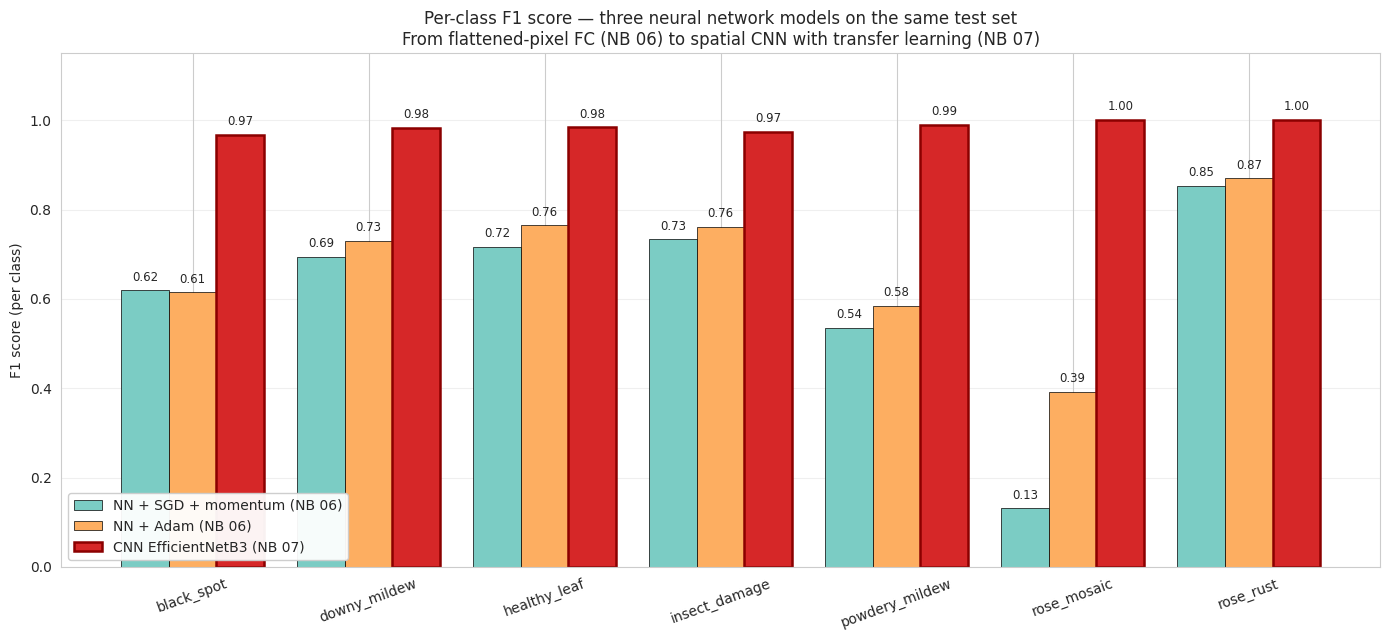


Per-class F1 score comparison:
  Class                 NN+SGD   NN+Adam       CNN    Delta vs Adam
  ------------------------------------------------------------------
  black_spot            0.6192    0.6148    0.9672          +0.3524  *
  downy_mildew          0.6948    0.7304    0.9834          +0.2530  *
  healthy_leaf          0.7157    0.7644    0.9836          +0.2192  *
  insect_damage         0.7333    0.7615    0.9736          +0.2121  *
  powdery_mildew        0.5358    0.5839    0.9893          +0.4054  *
  rose_mosaic           0.1308    0.3913    1.0000          +0.6087  *
  rose_rust             0.8529    0.8694    1.0000          +0.1306

  Macro F1              0.6118    0.6737    0.9853          +0.3116

Largest CNN gain over NN+Adam : rose_mosaic        +0.6087 F1
Smallest CNN gain over NN+Adam: rose_rust          +0.1306 F1


In [3]:
# ============================================================
# Per-class F1 score comparison across the three NN models
# ============================================================
f1_per_class_sgd  = f1_score(nb06_y_test, nb06_preds_sgd,  average=None,
                              zero_division=0)
f1_per_class_adam = f1_score(nb06_y_test, nb06_preds_adam, average=None,
                              zero_division=0)
f1_per_class_cnn  = f1_score(y_test_cnn,  test_preds_cnn,  average=None,
                              zero_division=0)

# ============================================================
# Grouped bar chart
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6.5))
x = np.arange(N_CLASSES)
w = 0.27

bars_sgd = ax.bar(
    x - w, f1_per_class_sgd, w,
    label="NN + SGD + momentum (NB 06)",
    color="#7bccc4", edgecolor="black", linewidth=0.5,
)
bars_adam = ax.bar(
    x, f1_per_class_adam, w,
    label="NN + Adam (NB 06)",
    color="#fdae61", edgecolor="black", linewidth=0.5,
)
bars_cnn = ax.bar(
    x + w, f1_per_class_cnn, w,
    label="CNN EfficientNetB3 (NB 07)",
    color="#d62728", edgecolor="black", linewidth=0.5,
)

# Highlight the CNN bars with a thicker dark border (consistency with the 5-model chart)
for b in bars_cnn:
    b.set_linewidth(1.8)
    b.set_edgecolor("darkred")

# Annotate every bar with its F1 value
for bar_group in (bars_sgd, bars_adam, bars_cnn):
    for b in bar_group:
        height = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2, height + 0.015,
            f"{height:.2f}",
            ha="center", va="bottom", fontsize=8.5,
        )

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, fontsize=10)
ax.set_ylabel("F1 score (per class)")
ax.set_title(
    "Per-class F1 score — three neural network models on the same test set\n"
    "From flattened-pixel FC (NB 06) to spatial CNN with transfer learning (NB 07)",
    fontsize=12,
)
ax.set_ylim(0, 1.15)
ax.legend(loc="lower left", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# Numerical summary table
# ============================================================
print("\nPer-class F1 score comparison:")
print(f"  {'Class':<18} {'NN+SGD':>9} {'NN+Adam':>9} {'CNN':>9} "
      f"{'Delta vs Adam':>16}")
print("  " + "-" * 66)
for i in range(N_CLASSES):
    delta_vs_adam = f1_per_class_cnn[i] - f1_per_class_adam[i]
    marker = "  *" if delta_vs_adam >= 0.20 else ""
    print(f"  {CLASS_NAMES[i]:<18} {f1_per_class_sgd[i]:>9.4f} "
          f"{f1_per_class_adam[i]:>9.4f} {f1_per_class_cnn[i]:>9.4f} "
          f"{delta_vs_adam:>+16.4f}{marker}")

print(f"\n  {'Macro F1':<18} {f1_per_class_sgd.mean():>9.4f} "
      f"{f1_per_class_adam.mean():>9.4f} {f1_per_class_cnn.mean():>9.4f} "
      f"{f1_per_class_cnn.mean() - f1_per_class_adam.mean():>+16.4f}")

# ============================================================
# Largest and smallest improvements
# ============================================================
deltas = f1_per_class_cnn - f1_per_class_adam
biggest_idx  = int(np.argmax(deltas))
smallest_idx = int(np.argmin(deltas))
print(f"\nLargest CNN gain over NN+Adam : {CLASS_NAMES[biggest_idx]:<18} "
      f"+{deltas[biggest_idx]:.4f} F1")
print(f"Smallest CNN gain over NN+Adam: {CLASS_NAMES[smallest_idx]:<18} "
      f"+{deltas[smallest_idx]:.4f} F1")

## Visualisation: Misclassified Test Examples

The confusion matrices and per-class F1 chart quantified *how often*
the CNN errs (1.6% mean misclassification rate). This visualisation
shows *which* images it gets wrong, so the remaining error budget can
be inspected qualitatively rather than just as a number.

### What Is Shown

Every test image the CNN misclassified is collected, then sorted by
the model's **confidence in its (wrong) prediction**. The grid shows
the most confident mistakes first — these are the most diagnostic
cases, because the model was not merely uncertain, it was confident
and wrong. Each tile is labelled `pred -> true` with the predicted
probability.

### What to Look For

- **Genuine ambiguity vs. label noise.** Some misses are expected
  (e.g. an early-stage lesion that genuinely resembles another
  disease); others may reveal mislabelled or borderline images in the
  test split itself.
- **Whether errors cluster on a class pair.** If most mistakes are
  one specific `pred -> true` swap, that points to a residual
  representational confusion rather than random error.
- **Confidence of the mistakes.** Low-confidence errors are healthy
  (the model "knew" it was unsure); high-confidence errors are the
  ones worth understanding for a field-deployed model.

Found 2580 files belonging to 7 classes.
File order verified against saved predictions (2,580 test images).
Total misclassified: 46 / 2580 (1.78%)
Showing the 16 most confident mistakes.


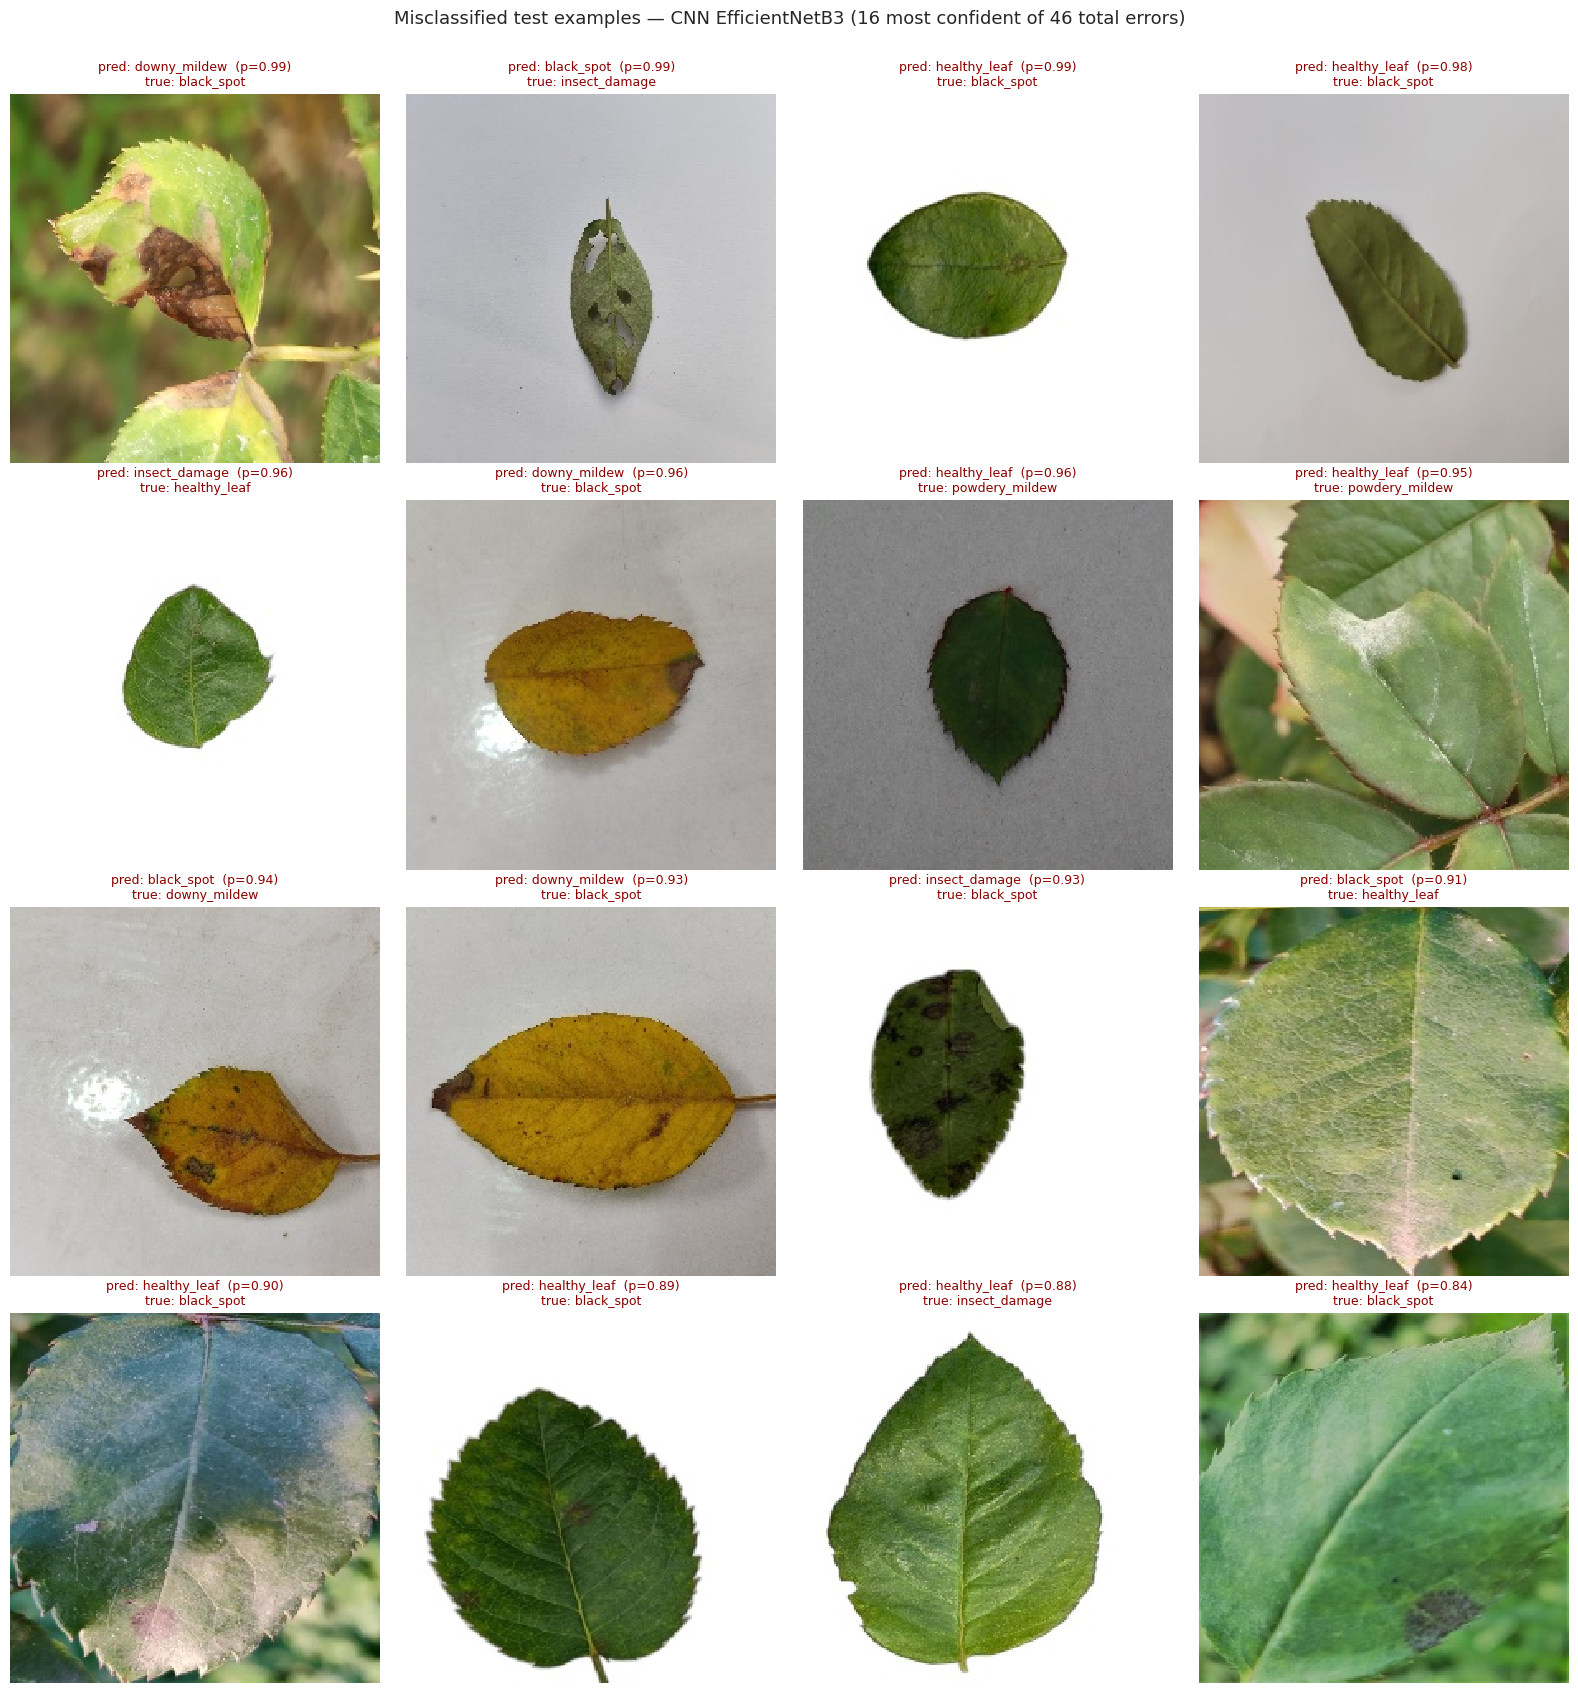


Most common error pairs (true -> predicted):
  black_spot       -> healthy_leaf     : 10
  insect_damage    -> healthy_leaf     : 7
  black_spot       -> downy_mildew     : 5
  black_spot       -> insect_damage    : 5
  healthy_leaf     -> insect_damage    : 5
  insect_damage    -> black_spot       : 4
  downy_mildew     -> black_spot       : 3
  powdery_mildew   -> healthy_leaf     : 3
  healthy_leaf     -> black_spot       : 2
  black_spot       -> powdery_mildew   : 1


In [4]:
# ============================================================
# Visualisation: misclassified test examples
# Reconstructs the deterministic (shuffle=False) test-file order so
# the saved predictions map back to actual image files on Drive.
# No model inference and no local copy are needed here.
# ============================================================
recon_test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
    class_names=CLASS_NAMES,
)
file_paths = np.array(recon_test_ds.file_paths)

# Sanity check: the reconstructed file order must match the saved label order
recon_labels = np.array(
    [CLASS_TO_IDX[Path(p).parent.name] for p in file_paths]
)
assert np.array_equal(recon_labels, y_test_cnn), (
    "Reconstructed file order does not match saved y_test_cnn — "
    "the file->prediction mapping would be wrong."
)
assert len(file_paths) == len(test_preds_cnn), "Length mismatch"
print(f"File order verified against saved predictions "
      f"({len(file_paths):,} test images).")

# ============================================================
# Collect misclassified samples, sorted by confidence (most confident first)
# ============================================================
mis_idx = np.where(test_preds_cnn != y_test_cnn)[0]
mis_conf = test_probs_cnn[mis_idx, test_preds_cnn[mis_idx]]
order = np.argsort(-mis_conf)            # descending confidence
sel = mis_idx[order]

n_total_mis = len(mis_idx)
n_show = min(16, n_total_mis)
print(f"Total misclassified: {n_total_mis} / {len(y_test_cnn)} "
      f"({n_total_mis / len(y_test_cnn) * 100:.2f}%)")
print(f"Showing the {n_show} most confident mistakes.")

# ============================================================
# Grid of misclassified images (4 columns)
# ============================================================
n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for plot_i, idx in enumerate(sel[:n_show]):
    img = Image.open(file_paths[idx]).convert("RGB").resize(IMAGE_SIZE)
    pred = CLASS_NAMES[test_preds_cnn[idx]]
    true = CLASS_NAMES[y_test_cnn[idx]]
    conf = test_probs_cnn[idx, test_preds_cnn[idx]]

    ax = axes[plot_i]
    ax.imshow(img, interpolation="nearest")
    ax.set_title(
        f"pred: {pred}  (p={conf:.2f})\ntrue: {true}",
        fontsize=9, color="darkred",
    )

fig.suptitle(
    f"Misclassified test examples — CNN EfficientNetB3 "
    f"({n_show} most confident of {n_total_mis} total errors)",
    fontsize=13, y=1.005,
)
plt.tight_layout()
plt.show()

# ============================================================
# Which class pairs dominate the errors?
# ============================================================
from collections import Counter
pair_counts = Counter(
    (CLASS_NAMES[y_test_cnn[i]], CLASS_NAMES[test_preds_cnn[i]])
    for i in mis_idx
)
print("\nMost common error pairs (true -> predicted):")
for (true_c, pred_c), cnt in pair_counts.most_common(10):
    print(f"  {true_c:<16} -> {pred_c:<16} : {cnt}")

### Observations

The CNN makes only **46 mistakes on 2,580 test images (1.78% overall
error)**. Two structural patterns stand out — neither is random.

**1. `black_spot` is the dominant source of error.** It is the true
class in 21 of the 46 misses (~46%), which is consistent with its
being the lowest-recall class (0.95). The most confident mistakes in
the grid are `true: black_spot -> pred: healthy_leaf` images where the
visible leaf area shows little or no lesion. This suggests the misses
are driven by early-stage or off-frame lesions rather than by a
failure to recognise the black-spot texture itself.

**2. The dominant error direction is "disease -> healthy".** Three of
the top error pairs point a diseased or damaged leaf at `healthy_leaf`:
`black_spot -> healthy_leaf` (10), `insect_damage -> healthy_leaf` (7)
and `powdery_mildew -> healthy_leaf` (3) — together 20 of 46 errors
(43%). These are **false negatives**: for a system whose end goal is a
treatment recommendation, missing a disease is the more consequential
error type (a missed disease means no fungicide is applied). This is
flagged here as an input for the fungicide-recommendation logic that
combines notebook 07 (diagnosis) with notebook 08 (weather context).

**3. `rose_mosaic` and `rose_rust` never appear among the errors.**
This confirms the perfect (1.00) recall reported for both classes. The
residual confusion is concentrated entirely among the visually similar
"subtle-lesion" classes — black_spot, healthy_leaf, insect_damage and
downy_mildew — where chlorosis, small holes and early lesions overlap.

**Interpretation, not a proven defect.** Some of these borderline
images may be ambiguous or near the labelling boundary in the test
split itself (e.g. a leaf with one tiny hole labelled `insect_damage`
but visually near-healthy). The grid is a diagnostic of the remaining
error budget, not evidence of a systematic model fault — the error
rate is low and the misses are concentrated where the EDA predicted
the classes would overlap.

## Conclusions

Notebook 07 closes the image-classification arc of the project. A
single EfficientNetB3 with transfer learning, trained in two staged
phases (frozen-base head training, then a conservative top-20-layer
fine-tune), reached **0.9822 test accuracy / 0.9853 macro F1** on the
same held-out 2,580-image split used by every prior notebook.

### The Five-Model Ladder

| Model | Test acc | Macro F1 | Regime |
|---|---|---|---|
| Logistic Regression (NB 05) | 0.556 | 0.47 | linear |
| Linear SVM (NB 05) | 0.511 | 0.44 | linear |
| NN + SGD + momentum (NB 06) | 0.6845 | 0.6118 | non-linear FC |
| NN + Adam (NB 06) | 0.7186 | 0.6737 | non-linear FC |
| **CNN EfficientNetB3 (NB 07)** | **0.9822** | **0.9853** | **spatial CNN** |

Three regimes are visible: linear (~0.53 mean acc), non-linear
fully-connected (~0.70 mean acc), and the spatial CNN (0.98). The two
steps up the ladder are **+16.8 pp** (linear -> FC) and **+28.1 pp**
(FC -> CNN). The CNN beats the best prior model (NN + Adam) by
**+26.36 pp accuracy** and **+0.3116 macro F1**.

### Where the Jump Came From

The gain over the fully-connected networks is attributable to the
**representation**, not to raw parameter count or depth. Notebooks 05
and 06 flattened images to 32x32 grayscale (1,024 features), which
discarded spatial structure and colour. The CNN operates on 224x224
RGB and learns translation-equivariant local features via parameter
sharing. The two ceilings flagged in notebook 06 were both lifted:

- **`rose_mosaic` F1**: `0.13` (NN+SGD) -> `0.39` (NN+Adam) -> `1.00`
  (CNN) — the largest single per-class improvement in the project.
  The EDA-predicted `rose_mosaic <-> powdery_mildew` confusion, which
  was a property of the grayscale input, disappears once colour and
  resolution are restored.
- **`black_spot` recall**: `0.65` (NN+Adam) -> `0.95` (CNN) — the
  local spot markers become recoverable at 224x224.

This confirms the notebook's stated hypothesis: the improvement is
driven by **spatial structure + colour + higher resolution**, exactly
the information the flattened representation threw away.

### Residual Error (1.78%)

The 46 remaining misses concentrate on `black_spot` (~46% of errors)
and lean toward a **"disease -> healthy" false-negative direction**
(43% of errors). `rose_mosaic` and `rose_rust` are error-free
(recall 1.00). This residual is consistent with the EDA's prediction
of overlap among the subtle-lesion classes and is flagged as an input
for the treatment-recommendation logic — false negatives are the more
costly error type for a system that decides whether to apply fungicide.

### Saved Artifacts (in `MODELS_DIR` on Drive)

- `07_cnn_efficientnetb3_final.keras` — final fine-tuned model.
- `07_test_predictions.npz` — test predictions, probabilities, labels.
- `07_cnn_efficientnetb3_history.json` — combined Stage 1 + Stage 2
  training history.

### Hand-Off to Notebooks 08 and 09

- **Notebook 08 (weather risk)** is independent of the image model. It
  uses the Krasnovo weather data and the four EDA-selected features
  (temperature, humidity, precipitation, wind) to predict disease risk
  from weather conditions.
- **Notebook 09 (MLflow)** loads all saved models — LR/SVM (NB 05),
  the two NN variants (NB 06) and this CNN — to reproduce the
  five-model comparison ladder as the project's final benchmark.
- **Project deliverable**: the fungicide-recommendation logic combines
  this CNN's image diagnosis with notebook 08's weather context.